In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# en este codigo se toma los difrentes archivos csv que estan en la carpeta datos en drive que contienen informacion de los freatimetros por año y se genera un solo archivo
# Lista de años
anios = range(2010, 2023)

# Lista para almacenar los DataFrames
dfs = []

# Ruta base del archivo CSV
ruta_base = '/content/drive/MyDrive/Datos Tesis/NF_{}.csv'

# Iterar sobre los años
for anio in anios:
    # Leer el archivo CSV correspondiente al año
    df = pd.read_csv(ruta_base.format(anio), sep=';', decimal=',')
    # Realizar el reemplazo de valores si es necesario
    if 'estado' in df.columns:
        df = df.replace(['roto', 'cerrado', 'tapado', 'con barro', 'regado', 'barro'], np.nan)
    # Agregar el DataFrame a la lista
    dfs.append(df)

# Concatenar todos los DataFrames en uno solo
df_completo = pd.concat(dfs, ignore_index=True)

# Filtrar el DataFrame completo usando isin()
parametros = [54390, 61390, 61403, 61383, 61267, 61250, 61107, 60947, 60933, 60610, 60460, 60455, 60451, 60170, 60075, 62053 ,60955,
60771,60440,60300,60160,60080,60040,60095,61271]
df_filtrado = df_completo[df_completo['Freatimetro'].isin(parametros)]

# Imprimir el DataFrame filtrado
print(pd.DataFrame(df_filtrado))


     Freatimetro   Enero Febrero   Marzo   Abril    Mayo   Junio   Julio  \
1          60040    1.73    1.64    1.45    1.57    1.22    1.82    1.89   
2          60075    1.97     2.0    1.43    1.45    1.72    2.21    2.23   
3          60080     1.1    1.27     NaN     NaN     NaN     NaN     NaN   
5          60160    1.59     1.7     NaN    2.32    1.68     2.3    2.86   
6          60170    2.85    2.38    1.32     2.2    2.27    2.25    2.46   
..           ...     ...     ...     ...     ...     ...     ...     ...   
744        61250    3,05    2,98    3,02    3,06     3,3    3,28    3,52   
745        61383    2,35    2,52    2,54    2,57    2,56    2,42    2,58   
746        61267    3,15    3,35     3,4    3,44    4,35     4,6    4,86   
747        61390  tapado  tapado  tapado  tapado  tapado  tapado  tapado   
748        61403  tapado  tapado  tapado  tapado  tapado  tapado  tapado   

     Agosto Septiembre Octubre Noviembre Diciembre Enero   
1       1.9        1.6    1

se imputan los valores nulos de los freatimetros

In [ ]:

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

import numpy as np
import pandas as pd
from tabulate import tabulate
# Ruta al archivo Excel y nombre de la pestaña
archivo_excel = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotas.xlsx'
np.set_printoptions(threshold=np.inf)

nombre_pestaña = 'archivo'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
data = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)
#todo a float
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Asegurarnos de que la columna 'cota' también esté en float
cota_column = data.columns[1]
data[cota_column] = pd.to_numeric(data[cota_column], errors='coerce')

cota_column = data.columns[1]  # Identificar la columna 'cota' como la 2da columna

# Restar el valor de la columna 'cota' a cada celda en su fila
for index, row in data.iterrows():
    cota_value = row[cota_column]
    data.iloc[index, 2:] = cota_value - data.iloc[index, 2:]




data = data.drop(columns=['cota'])

column_names = data.columns.tolist()
data.set_index('Freatimetro', inplace=True)
matriz_transpuesta = np.transpose(data)

df = matriz_transpuesta.apply(pd.to_numeric, errors='coerce')

imputer = IterativeImputer()

# Aplicar el imputador a los datos con valores faltantes
df_imputed = imputer.fit_transform(df)
nombres_filas = data.index
nombres_columnas = data.columns

DF = pd.DataFrame(df_imputed, index=nombres_columnas, columns=nombres_filas)
# Usar tabulate para visualizar la tabla
styled_df = DF.style.format(na_rep='Nulo', precision=2)
styled_df
DF.reset_index(inplace=True)
DF.to_excel('/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx')
#ruta_excel = 'DF.xlsx'
#DF.to_excel(ruta_excel, index=False)
#from google.colab import files
#files.download('DF.xlsx')


In [ ]:
print(DF.columns)

Index([60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947,
       60955, 61250, 61271, 61383, 62053],
      dtype='int64', name='Freatimetro')


# Nueva sección

In [ ]:
import pandas as pd
alturaRioRoca= pd.read_csv('/content/drive/MyDrive/Datos Tesis/NivelenRoca2010-23.csv',sep=';',decimal=',')

# Convierte la columna 'Fecha' al formato datetime

alturaRioRoca['Fecha'] = pd.to_datetime(alturaRioRoca['Fecha'], format="%d/%m/%Y %H:%M")
# Rellena los valores NaN con el valor más repetido en cada columna
alturaRioRoca = alturaRioRoca.fillna(alturaRioRoca.mode().iloc[0])

# Crea un DataFrame
df = pd.DataFrame(alturaRioRoca)

# Extrae el año de la fecha
alturaRioRoca['año'] = alturaRioRoca['Fecha'].dt.year

# Calcula el promedio mensual de la altura del río por año
promedios = alturaRioRoca.groupby(['año', alturaRioRoca['Fecha'].dt.month])['Cota'].mean()

# Resetea el índice
promediosAlturaRoca_df = promedios.reset_index()
# Renombra las columnas
promediosAlturaRoca_df.columns = ['año', 'mes', 'promedio']
promediosAlturaRoca_df['fecha'] = pd.to_datetime(promediosAlturaRoca_df['año'].astype(str) + '-' + promediosAlturaRoca_df['mes'].astype(str), format='%Y-%m')
# Eliminar las columnas 'año' y 'mes' si ya no las necesitas


promediosAlturaRoca_df = promediosAlturaRoca_df.set_index('fecha')

# Imprime el contenido del DataFrame (para visualización en consola)
print(f"Contenido de la hoja 'promediosAlturaRoca_df':")
print(promediosAlturaRoca_df)

# Guarda el DataFrame en un archivo Excel
ruta_excel = 'alturaRioRoca.xlsx'
promediosAlturaRoca_df.to_excel(ruta_excel, index=False)
promediosAlturaRoca_df.reset_index(inplace=True)
# Descarga el archivo Excel desde Google Colab
#from google.colab import files
#files.download(ruta_excel)

Contenido de la hoja 'promediosAlturaRoca_df':
             año  mes    promedio
fecha                            
2010-01-01  2010    1  236.547742
2010-02-01  2010    2  236.556429
2010-03-01  2010    3  236.584839
2010-04-01  2010    4  236.864667
2010-05-01  2010    5  236.280645
...          ...  ...         ...
2023-08-01  2023    8  237.838065
2023-09-01  2023    9  237.681000
2023-10-01  2023   10  237.171935
2023-11-01  2023   11  237.076667
2023-12-01  2023   12  236.856452

[168 rows x 3 columns]


In [ ]:
import pandas as pd
ruta_nivel_rio = '/content/drive/MyDrive/Datos Tesis/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
DF = pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_2010_2023 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)

In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
DF = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)
# Asegúrate de que la columna de fecha sea del tipo datetime
DF['fecha'] = pd.to_datetime(DF['Date'])
nivelRioNegro_mensual_2010_2023['fecha'] = pd.to_datetime(nivelRioNegro_mensual_2010_2023['Date'])

# Filtrar datos para el DataFrame DF
filtro_DF = (DF['fecha'].dt.year >= 2010) & (DF['fecha'].dt.year <= 2023) & (DF['fecha'].dt.month.isin([5, 6, 7, 8]))
datos_filtrados_DF = DF[filtro_DF]

# Filtrar datos para el DataFrame promediosAlturaRoca_dfnivelRioNegro_mensual_2010_2023
filtro_promedios = (nivelRioNegro_mensual_2010_2023['fecha'].dt.year >= 2010) & (nivelRioNegro_mensual_2010_2023['fecha'].dt.year <= 2023) & (nivelRioNegro_mensual_2010_2023['fecha'].dt.month.isin([5, 6, 7, 8]))
datos_filtrados_promedios = nivelRioNegro_mensual_2010_2023[filtro_promedios]

# Mostrar los datos filtrados
print(datos_filtrados_DF)
print(datos_filtrados_promedios)


     Unnamed: 0       Date       62053       60040       60075       60160  \
4             4 2010-05-01  190.485000  191.942000  192.265000  194.090000   
5             5 2010-06-01  190.145000  191.342000  191.775000  193.470000   
6             6 2010-07-01  189.945000  191.272000  191.755000  192.910000   
7             7 2010-08-01  190.485000  191.262000  191.935000  192.670000   
16           16 2011-05-01  190.305000  191.752000  192.305000  193.450000   
17           17 2011-06-01  190.005000  191.562000  192.165000  193.410000   
18           18 2011-07-01  190.025000  191.752000  192.060830  193.490000   
19           19 2011-08-01  190.065000  191.702000  192.265000  193.010000   
28           28 2012-05-01  190.195000  190.592000  191.365000  193.000000   
29           29 2012-06-01  190.565000  191.232000  192.145000  194.210000   
30           30 2012-07-01  190.565000  191.232000  192.145000  194.210000   
31           31 2012-08-01  190.675000  191.513600  192.190033  

In [ ]:
datos_unidos = pd.merge(datos_filtrados_DF, datos_filtrados_promedios, on="fecha", how="inner")
print(datos_unidos)

    Unnamed: 0      index       62053       60040       60075       60160  \
0            4 2010-05-01  190.485000  191.942000  192.265000  194.090000   
1            5 2010-06-01  190.145000  191.342000  191.775000  193.470000   
2            6 2010-07-01  189.945000  191.272000  191.755000  192.910000   
3            7 2010-08-01  190.485000  191.262000  191.935000  192.670000   
4           16 2011-05-01  190.305000  191.752000  192.305000  193.450000   
5           17 2011-06-01  190.005000  191.562000  192.165000  193.410000   
6           18 2011-07-01  190.025000  191.752000  192.060830  193.490000   
7           19 2011-08-01  190.065000  191.702000  192.265000  193.010000   
8           28 2012-05-01  190.195000  190.592000  191.365000  193.000000   
9           29 2012-06-01  190.565000  191.232000  192.145000  194.210000   
10          30 2012-07-01  190.565000  191.232000  192.145000  194.210000   
11          31 2012-08-01  190.675000  191.513600  192.190033  193.785248   

In [ ]:
df_nivelrio_freatimetros_sinRiego = datos_unidos.rename(columns={'promedio': 'nivelRio'})


In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [62053, 60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383]
#'In  Dew','Hi Speed'

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    df_nivelrio_freatimetros_sinRiego,
    id_vars=['fecha','nivelRio' ],  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['fecha','nivel_freatico'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['fecha'].dtype)
print(long_data['fecha'].head())
long_data = long_data[
    (long_data['fecha'].dt.month.isin([5, 6, 7, 8])) &
    (long_data['fecha'].dt.year.between(2010, 2022))
]

ruta_guardado = "/content/drive/My Drive/Datos Tesis/df_merged_freatimetros_nivelRioNegro_long_caso1.xlsx"

# Guardar el DataFrame como un archivo Excel
long_data.to_excel(ruta_guardado, index=False)

print(f"✅ Archivo guardado correctamente en: {ruta_guardado}")
# Revisar el resultado de la transformación
print(long_data)

datetime64[ns]
0     2010-05-01
52    2010-05-01
104   2010-05-01
156   2010-05-01
208   2010-05-01
Name: fecha, dtype: datetime64[ns]
✅ Archivo guardado correctamente en: /content/drive/My Drive/Datos Tesis/df_merged_freatimetros_nivelRioNegro_long_caso1.xlsx
         fecha    nivelRio freátimetro_id  nivel_freatico
0   2010-05-01  236.280645          62053      190.485000
52  2010-05-01  236.280645          60040      191.942000
104 2010-05-01  236.280645          60075      192.265000
156 2010-05-01  236.280645          60160      194.090000
208 2010-05-01  236.280645          60300      195.082000
..         ...         ...            ...             ...
519 2022-08-01  235.845806          60933      199.736164
623 2022-08-01  235.845806          60955      201.137000
675 2022-08-01  235.845806          61250      201.463000
727 2022-08-01  235.845806          61271      202.497000
779 2022-08-01  235.845806          61383      203.845000

[780 rows x 4 columns]


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# Seleccionar las características (X) y el objetivo (y)
features = ['nivelRio','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.8788 - mae: 0.7621 - val_loss: 0.6966 - val_mae: 0.6246
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6350 - mae: 0.5917 - val_loss: 0.5602 - val_mae: 0.4144
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5683 - mae: 0.4592 - val_loss: 0.4907 - val_mae: 0.4171
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5132 - mae: 0.4318 - val_loss: 0.4772 - val_mae: 0.3988
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4937 - mae: 0.4368 - val_loss: 0.4756 - val_mae: 0.4389
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3975 - mae: 0.3933 - val_loss: 0.4534 - val_mae: 0.4225
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4809 - mae: 0.4329 - val_loss: 0.4376 - val_mae: 0.4179
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3716 - mae: 0.3609 - val_loss: 0.4340 - val_mae: 0.4225
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4489 - mae: 0.427

In [ ]:
y_pred_desescalado = scaler_y.inverse_transform(y_pred_scaled)
y_test_desescalado = scaler_y.inverse_transform(y_test)

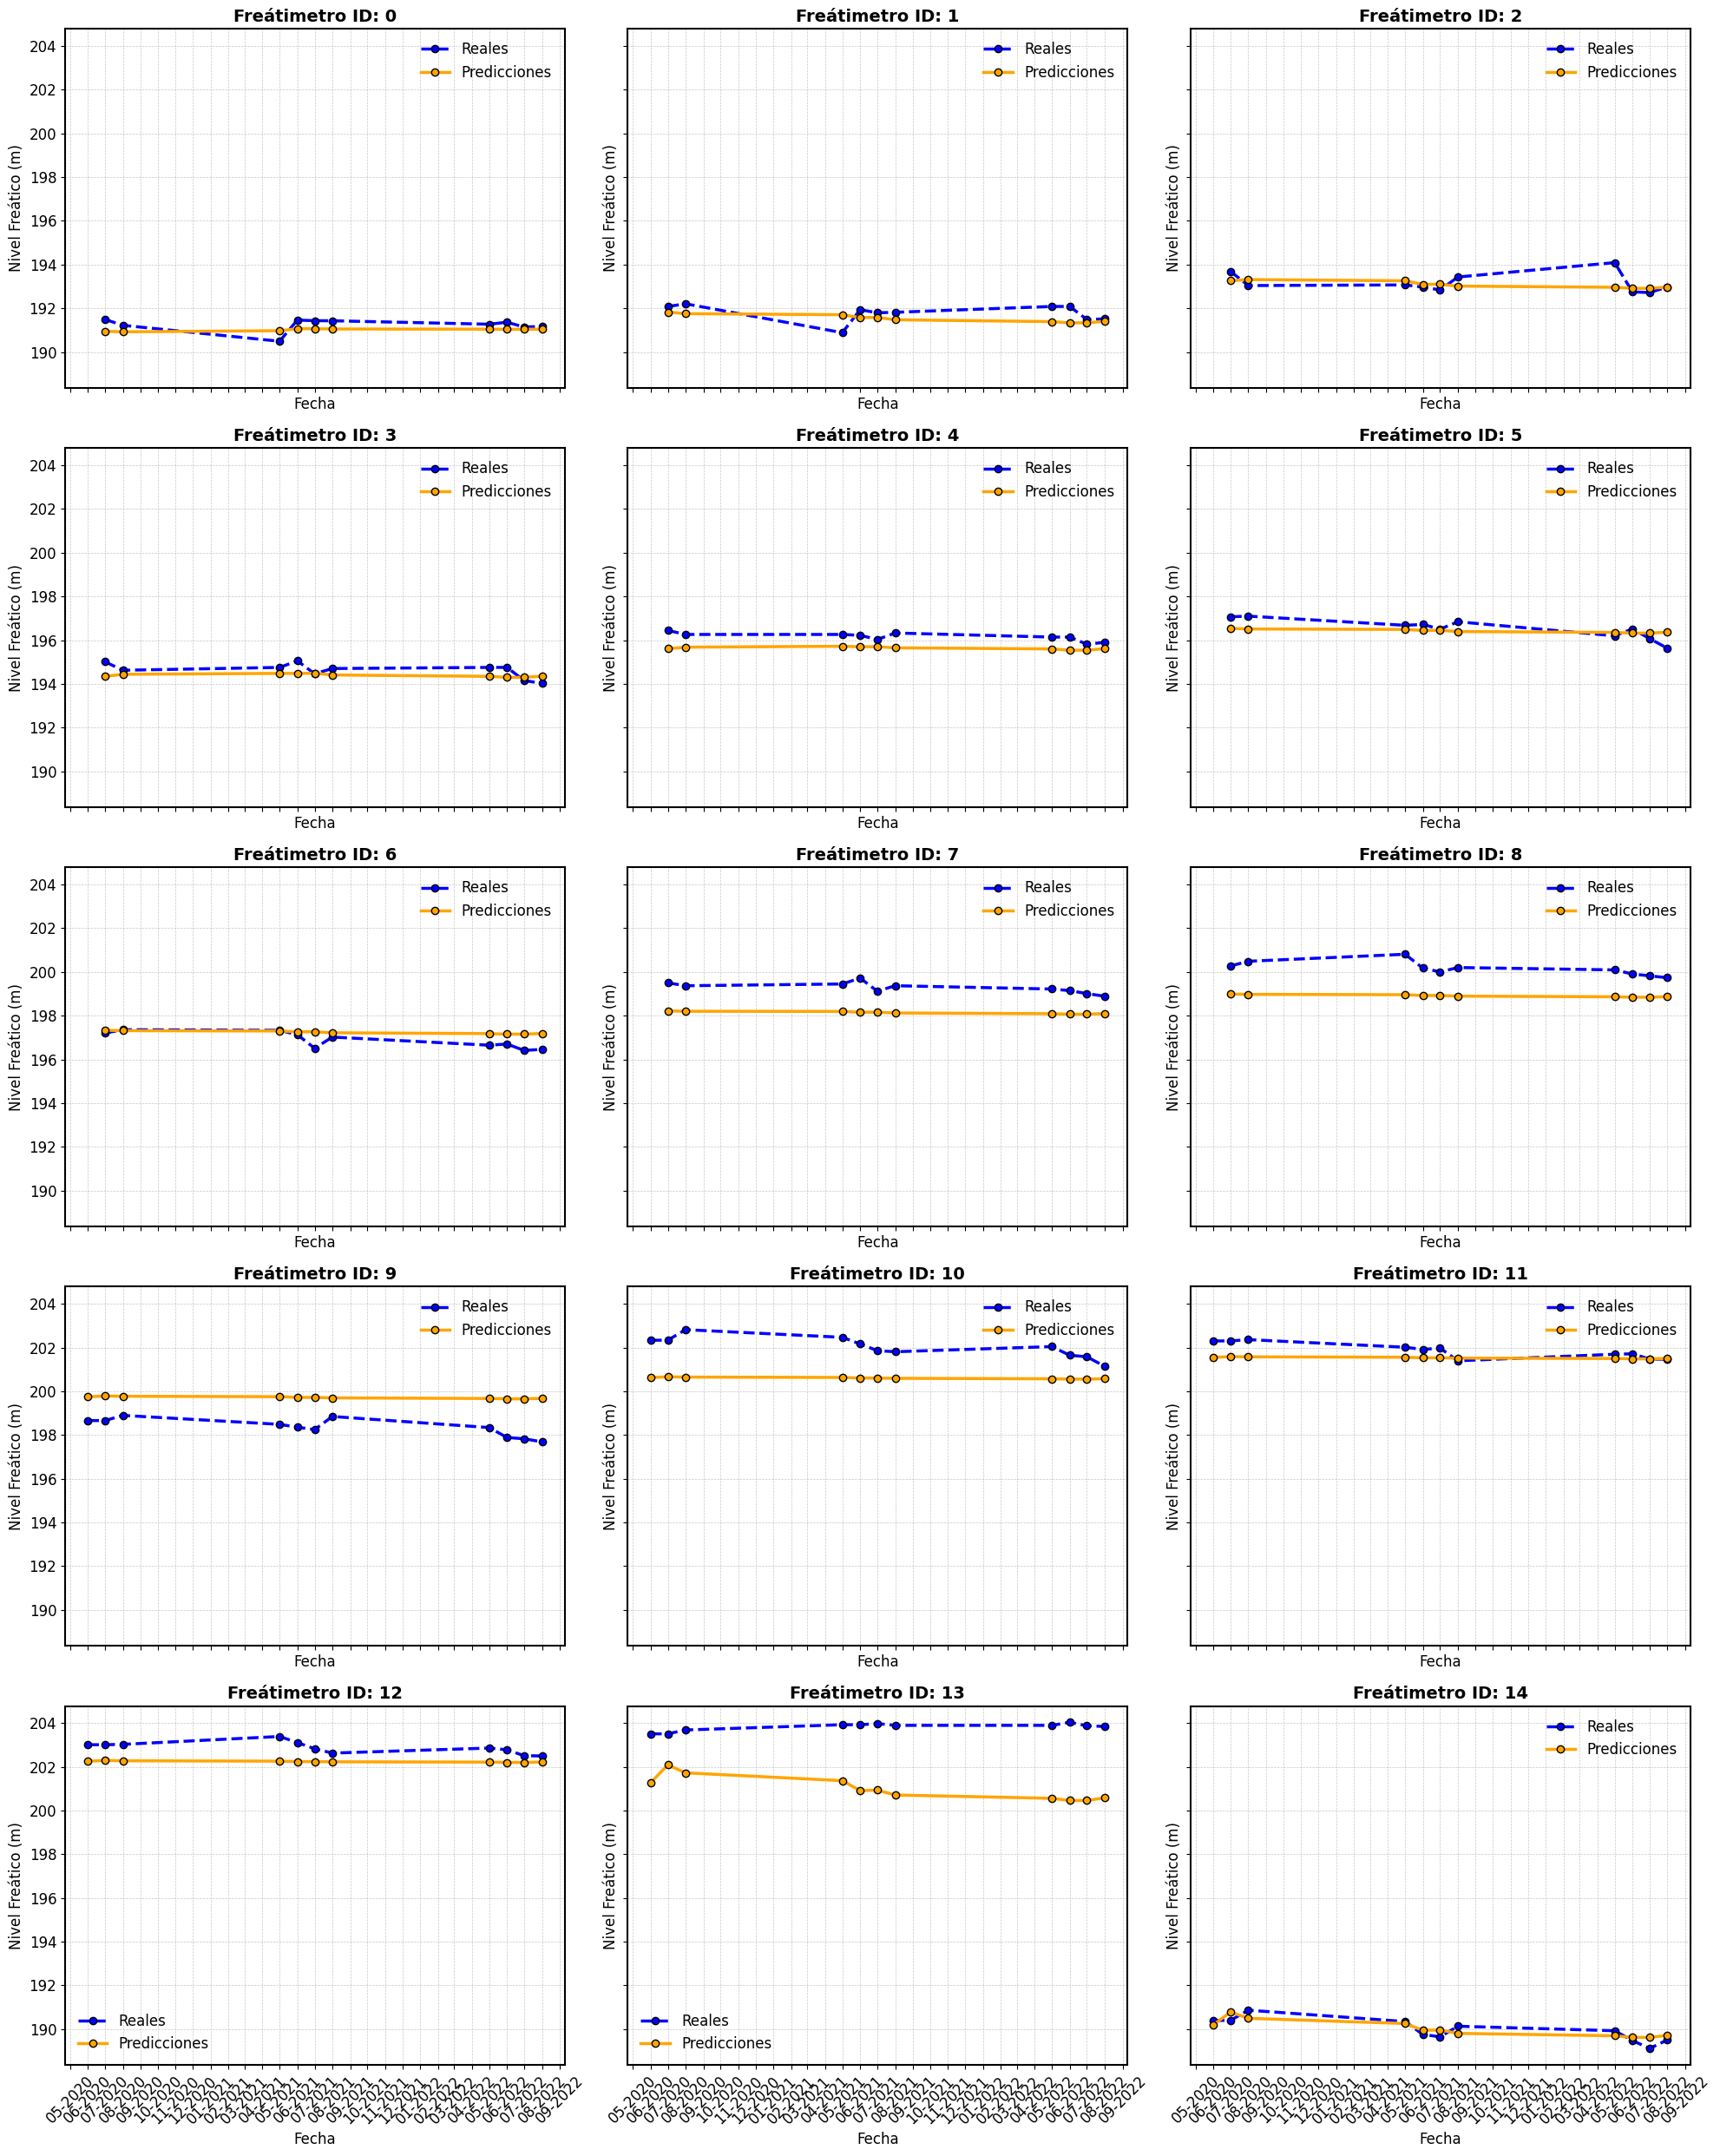

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Ajustes globales de estilo
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['font.size'] = 12

# Obtener los identificadores únicos de los freátimetros del conjunto de prueba
unique_freatimetros = np.unique(X_test[:, 0, -1])  # Asegúrate de que esta es la columna con los IDs de los freátimetros

# Definir el número de filas y columnas para el mosaico
num_freatimetros = len(unique_freatimetros)
rows = int(np.ceil(num_freatimetros / 3))  # Ajustar para que sean 3 columnas
cols = 3

# Crear los subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), sharex=True, sharey=True)

# Aplanar los ejes para iterar fácilmente (en caso de que rows=1, axes quizás no sea una lista)
if rows * cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Iterar sobre los freátimetros y graficar cada uno en un subplot
for idx, id_freatimetro in enumerate(unique_freatimetros):
    # Filtrar datos del conjunto de prueba para este freátimetro
    mask = (X_test[:, 0, -1] == id_freatimetro)  # Verificar la columna de freátimetro_id
    y_test_filtrado = y_test_desescalado[mask]
    y_pred_filtrado = y_pred_desescalado[mask]
    fechas_test = long_data['fecha'][-len(y_test_desescalado):][mask]  # Filtrar fechas para este freátimetro

    ax = axes[idx]

    # Graficar valores reales
    ax.plot(fechas_test, y_test_filtrado,
            label="Reales",
            marker='o', markersize=6, markeredgecolor='black', markeredgewidth=1,
            linestyle='--', linewidth=2.5, color='blue')

    # Graficar predicciones
    ax.plot(fechas_test, y_pred_filtrado,
            label="Predicciones",
            marker='o', markersize=6, markeredgecolor='black', markeredgewidth=1,
            linewidth=2.5, color='orange')

    ax.set_title(f"Freátimetro ID: {int(id_freatimetro)}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Fecha", fontsize=12)
    ax.set_ylabel("Nivel Freático (m)", fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Mostrar etiquetas mensuales
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Cuadrícula sutil
    ax.legend(frameon=False)

# Ajustar diseño para evitar superposiciones
plt.tight_layout()

# Eliminar subplots vacíos si el número de freátimetros no llena la cuadrícula
for ax in axes[num_freatimetros:]:
    fig.delaxes(ax)

plt.show()


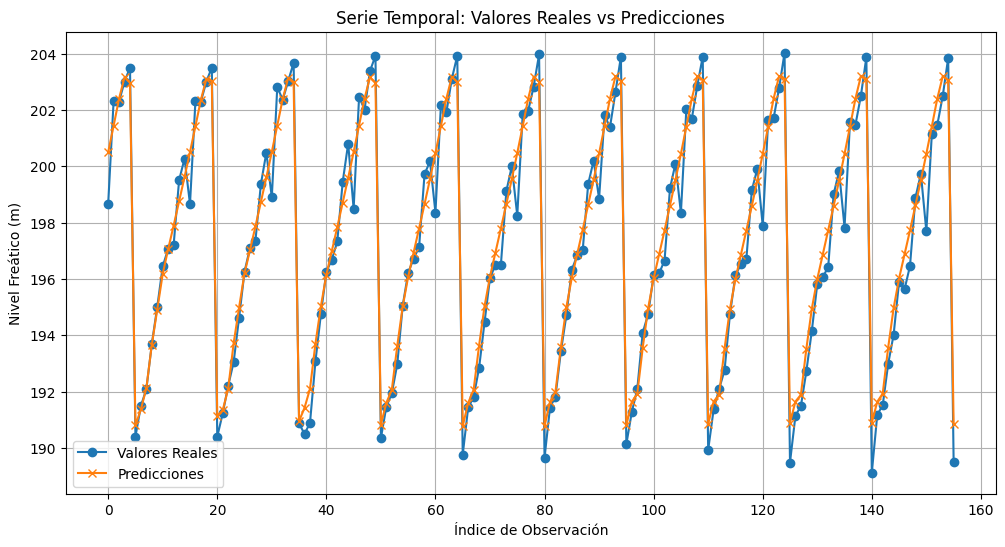

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Datos simulados basados en el modelo previamente entrenado (sustituir con tus datos reales)
y_test_real = y_test_descaled.flatten()  # Valores reales del conjunto de prueba
y_pred_model = y_pred.flatten()  # Predicciones del modelo



# 4. Serie temporal (Valores reales vs Predicciones)
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='Valores Reales', marker='o')
plt.plot(y_pred_model, label='Predicciones', marker='x')
plt.title('Serie Temporal: Valores Reales vs Predicciones')
plt.xlabel('Índice de Observación')
plt.ylabel('Nivel Freático (m)')
plt.legend()
plt.grid(True)
plt.show()

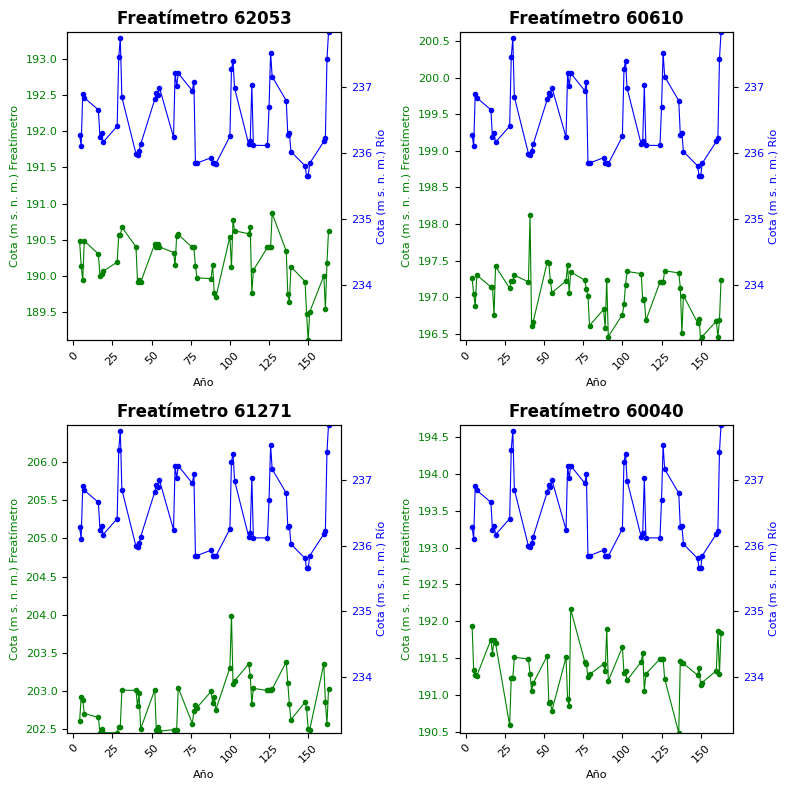

In [ ]:
import matplotlib.pyplot as plt

# Lista de freatímetros
freatimetros = [62053,60610,61271,60040]

# Número de filas y columnas para los subplots
n_rows = 2
n_cols = 2

# Crear la figura y los ejes con subplots
fig, axs = plt.subplots(n_rows, n_cols, figsize=(8, 8))  # A4 (11.7 x 16.5 pulgadas)



# Iterar sobre cada freatímetro y generar gráficos individuales en cada subplot
for i, freatimetro in enumerate(freatimetros):
    # Definir fila y columna del subplot actual
    row = i // n_cols
    col = i % n_cols

    # Obtener el subplot actual
    ax1 = axs[row, col]

    # Freatímetro actual
    freatimetro_data = datos_filtrados_DF[freatimetro]

    # Dibujar la gráfica del freatímetro con líneas más finas y puntos más pequeños
    ax1.plot(freatimetro_data, marker='o', markersize=3, linestyle='-', linewidth=0.8, color='green', label=f'Freatímetro {freatimetro}')
    ax1.set_xlabel('Año', fontsize=8)
    ax1.set_ylabel('Cota (m s. n. m.) Freatímetro', color='green', fontsize=8)
    ax1.tick_params(axis='y', labelcolor='green', labelsize=8)

    # Dibujar el gráfico lineal para el promedio del río
    ax2 = ax1.twinx()
    ax2.plot(datos_filtrados_promedios['promedio'], marker='o', markersize=3, linestyle='-', linewidth=0.8, color='blue', label='Promedio de Altura río')
    ax2.set_ylabel('Cota (m s. n. m.) Río', color='blue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=8)

    # Ajustar los límites del eje y
    buffer = 2.5  # Espacio entre los gráficos
    ax1.set_ylim([freatimetro_data.min(), freatimetro_data.max() + buffer])
    ax2.set_ylim([datos_filtrados_promedios['promedio'].min() - buffer, datos_filtrados_promedios['promedio'].max()])

    # Ajustar el tamaño y la rotación de las etiquetas del eje x
    ax1.tick_params(axis='x', labelsize=8, rotation=45)  # Tamaño y rotación del texto en el eje x

    # Añadir título a cada subplot
    ax1.set_title(f'Freatímetro {freatimetro}', fontsize=12, fontweight='bold')


# Ajustar el diseño de la figura
fig.tight_layout()

# Mostrar el gráfico
plt.show()


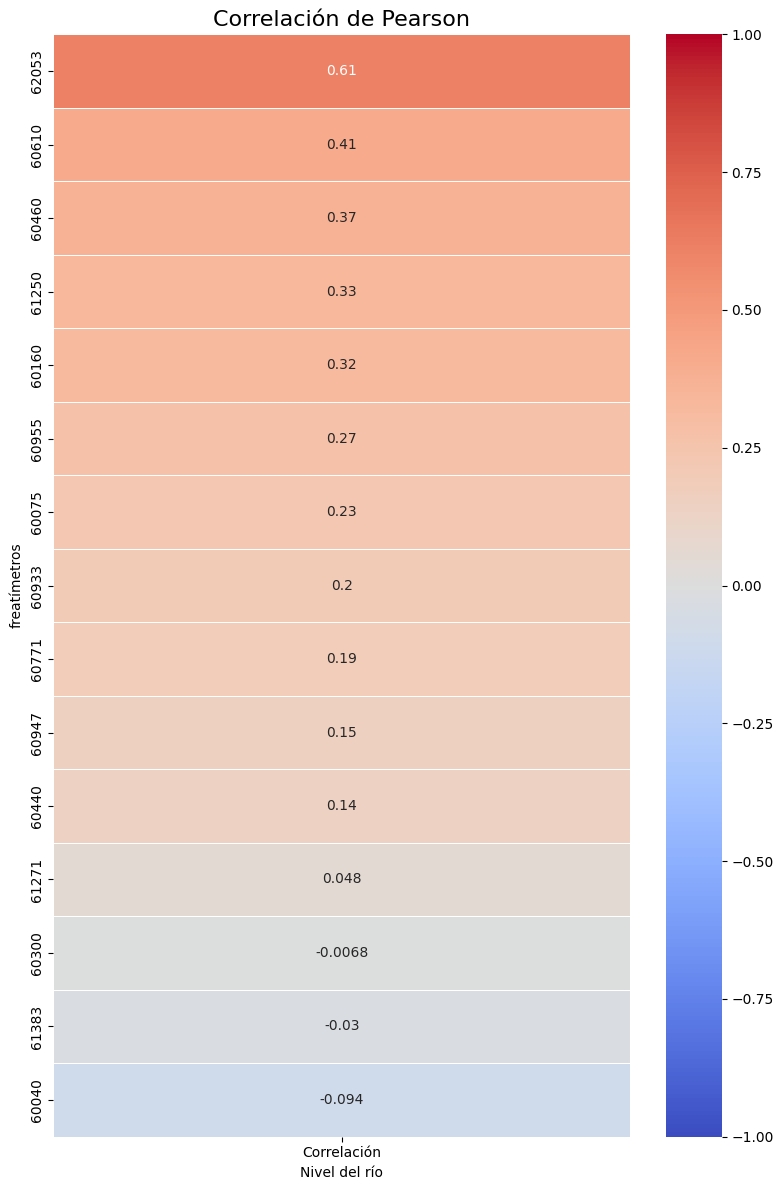

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Pearson
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = datos_filtrados_promedios['promedio']

# Calcular la correlación de Pearson entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación de Pearson
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': datos_filtrados_DF[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Asegurarse de eliminar filas con NaNs

    # Calcular la correlación de Pearson
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = pearsonr(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Pearson', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()


#correlacion

# Clima 2010 - 2019

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/Datos Tesis/clima2010-2019.xlsx'
df = pd.read_excel(file_path)


In [ ]:

print(df.columns)


Index(['Date', 'Time', 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.',
       'Wind Speed', 'Wind Dir', 'Wind Run', 'Hi Speed', 'Hi Dir',
       'Wind Chill', 'Heat Index', 'THW Index', 'THSW Index', 'Bar  ', 'Rain',
       'Rain Rate', 'Solar Rad.', 'Solar Energy', 'Hi Solar Rad. ',
       'Heat D-D ', 'Cool D-D ', 'In Temp', 'In  Hum', 'In  Dew', 'In  Heat',
       'In  ET ', 'Wind Samp', 'Wind Tx ', 'ISS Recept', 'Arc. Int.'],
      dtype='object')


In [ ]:
# Lista de columnas que no deseas convertir a float
non_float_columns = [
   'Wind Dir', 'Hi Dir','Wind Tx'
]

# Convertir todas las columnas a float excepto las que están en non_float_columns
for col in df.columns:
    if col not in non_float_columns:
        # Intentar convertir a float, manejar errores si ocurren
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Mostrar el tipo de datos después de la conversión
print(df.dtypes)


Time               object
Temp Out          float64
Hi Temp           float64
Low Temp          float64
Out Hum           float64
Dew Pt.           float64
Wind Speed        float64
Wind Dir           object
Wind Run          float64
Hi Speed          float64
Hi Dir             object
Wind Chill         object
Heat Index         object
THW Index          object
THSW Index         object
Bar               float64
Rain              float64
Rain Rate         float64
Solar Rad.         object
Solar Energy      float64
Hi Solar Rad.     float64
Heat D-D          float64
Cool D-D          float64
In Temp           float64
In  Hum           float64
In  Dew           float64
In  Heat          float64
In  ET            float64
Wind Samp           int64
Wind Tx             int64
ISS Recept        float64
Arc. Int.           int64
dtype: object


# correlacion variables climaticas y freatimetro

In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/Datos Tesis/promedio_mensual_clima.xlsx'
nombre_pestaña = 'hoja 1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClima = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)


datosClima['Date'] = pd.to_datetime(datosClima['Date'])

# Filtrar datos en el periodo 2010-2019 y los meses sin riego para comparar con los datos obtenidos del clima
filtro_datosClima =(datosClima['Date'].dt.month.isin([5, 6, 7, 8]))
datosClima = datosClima[filtro_datosClima]

filtro_F20102029 = (datos_filtrados_DF['fecha'].dt.year >= 2010) & (datos_filtrados_DF['fecha'].dt.year <= 2019)
datos_filtrados_DF = datos_filtrados_DF[filtro_F20102029]

filtro_R20102019 = (datos_filtrados_promedios['fecha'].dt.year >= 2010) & (datos_filtrados_promedios['fecha'].dt.year <= 2019)
datos_filtrados_promedios = datos_filtrados_promedios[filtro_R20102019]
print(datos_filtrados_DF)

print(datos_filtrados_promedios)

Freatimetro      index       60040       60075       60160       60300  \
4           2010-05-01  191.942000  192.265000  194.090000  195.082000   
5           2010-06-01  191.342000  191.775000  193.470000  194.742000   
6           2010-07-01  191.272000  191.755000  192.910000  194.602000   
7           2010-08-01  191.262000  191.935000  192.670000  194.722000   
16          2011-05-01  191.752000  192.305000  193.450000  194.832000   
17          2011-06-01  191.562000  192.165000  193.410000  194.762000   
18          2011-07-01  191.752000  192.060830  193.490000  194.732000   
19          2011-08-01  191.702000  192.265000  193.010000  194.712000   
28          2012-05-01  190.592000  191.365000  193.000000  195.402000   
29          2012-06-01  191.232000  192.145000  194.210000  194.262000   
30          2012-07-01  191.232000  192.145000  194.210000  194.262000   
31          2012-08-01  191.513600  192.190033  193.785248  195.080300   
40          2013-05-01  191.491114  19

In [ ]:
import pandas as pd


datosClima = datosClima.rename(columns={'Date': 'fecha'})
# Asegurar que las columnas 'fecha' de todos los DataFrames estén en formato datetime
datosClima['fecha'] = pd.to_datetime(datosClima['fecha'])


datos_filtrados_DF['fecha'] = pd.to_datetime(datos_filtrados_DF['fecha'])
datos_filtrados_promedios['fecha'] = pd.to_datetime(datos_filtrados_promedios['fecha'])

# Crear columnas de 'año-mes' para los DataFrames
datosClima['año_mes'] = datosClima['fecha'].dt.to_period('M')
datos_filtrados_DF['año_mes'] = datos_filtrados_DF['fecha'].dt.to_period('M')
datos_filtrados_promedios['año_mes'] = datos_filtrados_promedios['fecha'].dt.to_period('M')

# Unir datosClima y datos_filtrados_DF usando 'año_mes' como clave
df_merged = pd.merge(datosClima, datos_filtrados_DF, on='año_mes', how='inner')

# Luego, unir con datos_filtrados_promedios también usando 'año_mes' como clave
df_merged_final = pd.merge(df_merged, datos_filtrados_promedios, on='año_mes', how='inner')

# Renombrar la columna 'promedio' a 'nivelRio'
df_merged_final = df_merged_final.rename(columns={'promedio': 'nivelRio'})
# Reordenar las columnas para que 'nivelRio' esté en la primera posición
cols = ['nivelRio'] + [col for col in df_merged_final.columns if col != 'nivelRio']
df_merged_final = df_merged_final[cols]

df_merged_final = df_merged_final.drop(columns=['index'])
df_merged_final = df_merged_final.drop(columns=['año_mes'])
#df_merged_final = df_merged_final.drop(columns=['fecha'])
df_merged_final = df_merged_final.drop(columns=['fecha_x'])
df_merged_final = df_merged_final.drop(columns=['fecha_y'])
df_merged_final = df_merged_final.drop(columns=['año'])
df_merged_final = df_merged_final.drop(columns=['mes'])
df_merged_final.to_excel('/content/drive/MyDrive/Datos Tesis/datasetRedN.xlsx')
# Mostrar las primeras filas para verificar la unión
print(df_merged_final.head)


<bound method NDFrame.head of       nivelRio   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0   236.280645   9.539662   9.693193   9.386293  67.054411  2.765756   
1   236.108333  10.752168  10.895353  10.604766  61.888144  2.692144   
2   236.900000   7.850754   8.013958   7.687480  54.157895 -1.758544   
3   236.842903  10.647384  10.819282  10.475255  49.611574 -0.631875   
4   236.659032  11.305578  11.462679  11.148790  59.670251  2.665233   
5   236.243333   9.106815   9.267617   8.946894  60.744553  1.012401   
6   236.299355   9.537388   9.708244   9.365233  60.163530  1.164942   
7   236.167097  10.489158  10.647469  10.333669  53.428763  0.329928   
8   236.410968  11.652666  11.807303  11.496819  57.379928  2.404010   
9   237.458000  10.832894  10.985000  10.679907  57.257176  1.850926   
10  237.750000   9.942585  10.107616   9.779413  51.793683 -0.826299   
11  236.853548  11.904775  12.054495  11.758855  56.871620  2.470938   
12  235.991613  11.328898  11.4911

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]  # Asegúrate de que esta lista contenga todos los freatímetros que desees incluir.
# Agrega aquí otras variables de interés si lo deseas
variables_interes = ['nivelRio',       'Temp Out',        'Hi Temp',       'Low Temp',
              'Out Hum',        'Dew Pt.',     'Wind Speed',       'Wind Run',
             'Hi Speed',          'Bar  ',           'Rain',      'Rain Rate',
         'Solar Energy', 'Hi Solar Rad.',      'Heat D-D ',      'Cool D-D ',
              'In Temp',        'In  Hum',        'In  Dew',       'In  Heat',
              'In  ET',      'Wind Samp',       'Wind Tx ',     'ISS Recept',]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

# Calcular la matriz de correlación solo para las columnas de interés
aux = df_merged_final[columnas_interes].corr(method='pearson')

# Crear el mapa de calor
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(aux, vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Coeficiente de correlación de Pearson periodo sin riego', fontdict={'fontsize': 11}, pad=14)

# Mostrar el gráfico
plt.show()


NameError: name 'df_merged_final' is not defined

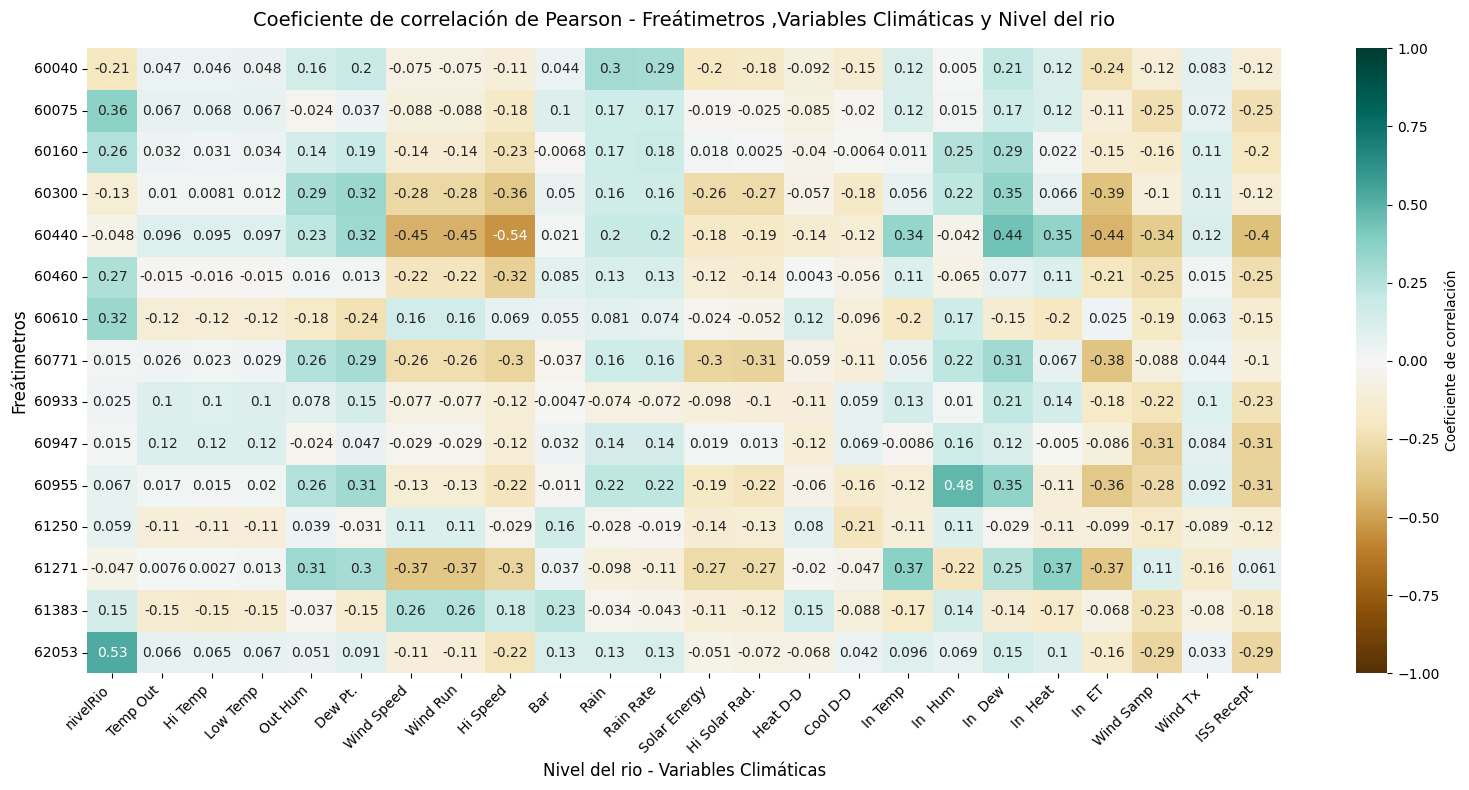

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Crear el mapa de calor
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    aux.loc[freatimetros_labels, climaticas_labels],  # Filtrar filas y columnas específicas
    vmin=-1, vmax=1, annot=True, cmap='BrBG', cbar_kws={'label': 'Coeficiente de correlación'}
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Pearson - Freátimetros ,Variables Climáticas y Nivel del rio', fontdict={'fontsize': 14}, pad=16)
heatmap.set_xlabel('Nivel del rio - Variables Climáticas', fontsize=12)
heatmap.set_ylabel('Freátimetros', fontsize=12)

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


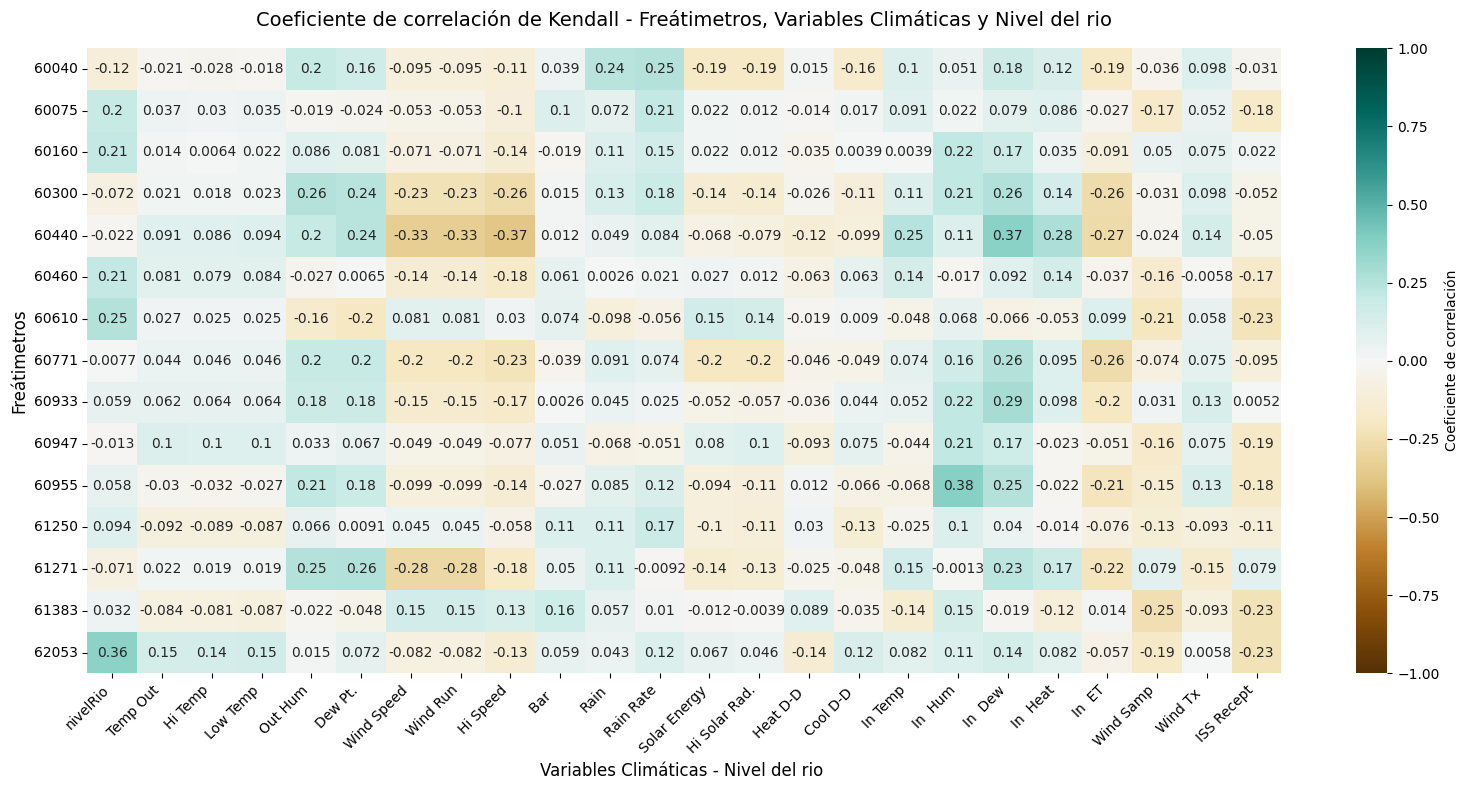

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Calcular la correlación de Kendall solo para los freatímetros y las variables climáticas
aux_s = df_merged_final.corr(method='kendall').loc[freatimetros_labels, climaticas_labels]

# Crear el mapa de calor
plt.figure(figsize=(16, 8))  # Ajusta el tamaño de la figura según las variables
heatmap = sns.heatmap(
    aux_s,  # Usar la correlación de Kendall filtrada
    vmin=-1, vmax=1, annot=True, cmap='BrBG', cbar_kws={'label': 'Coeficiente de correlación'}
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall - Freátimetros, Variables Climáticas y Nivel del rio', fontdict={'fontsize': 14}, pad=16)
heatmap.set_xlabel('Variables Climáticas - Nivel del rio ', fontsize=12)
heatmap.set_ylabel('Freátimetros', fontsize=12)

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


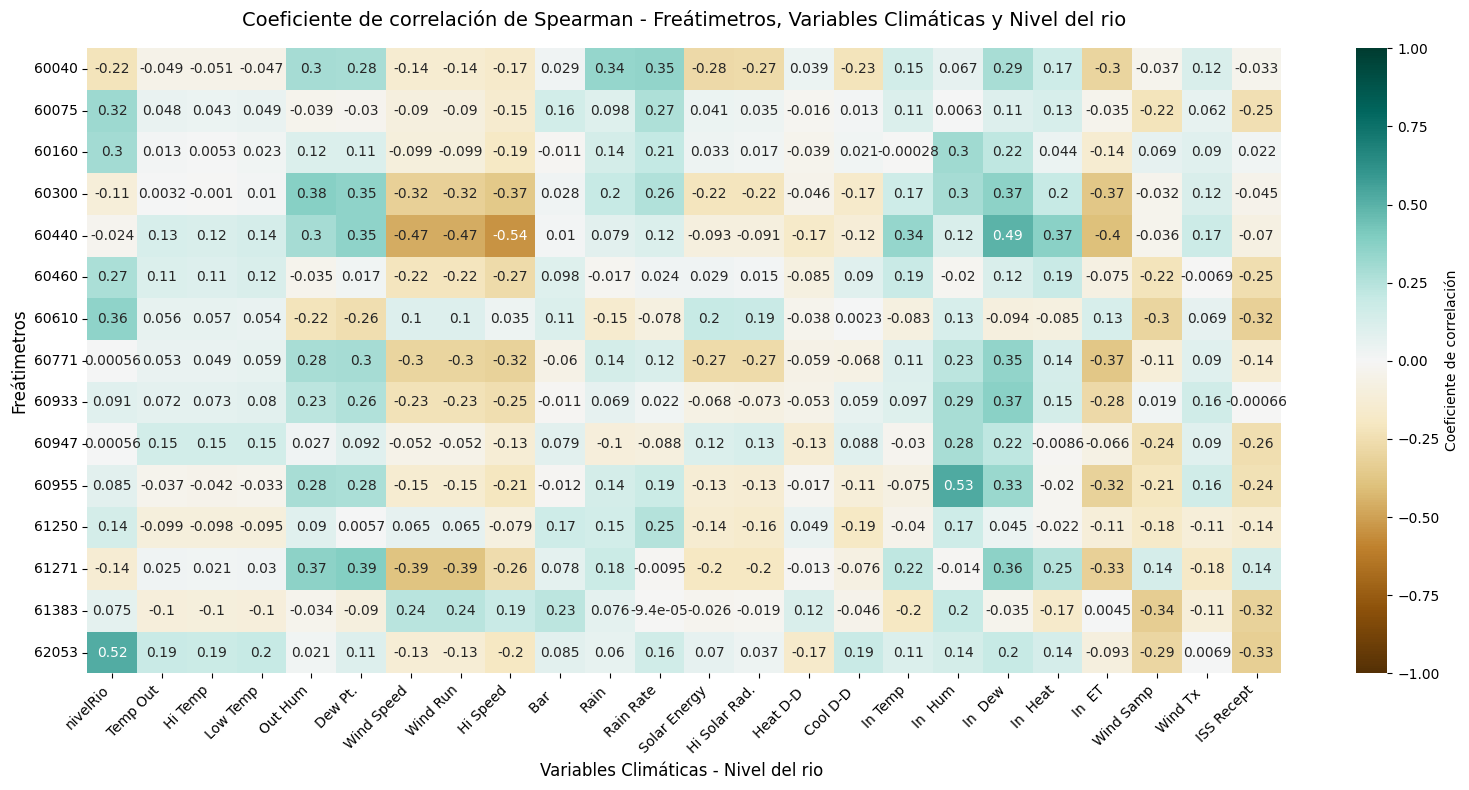

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Calcular la correlación de Kendall solo para los freatímetros y las variables climáticas
aux_s = df_merged_final.corr(method='spearman').loc[freatimetros_labels, climaticas_labels]

# Crear el mapa de calor
plt.figure(figsize=(16, 8))  # Ajusta el tamaño de la figura según las variables
heatmap = sns.heatmap(
    aux_s,  # Usar la correlación de Kendall filtrada
    vmin=-1, vmax=1, annot=True, cmap='BrBG', cbar_kws={'label': 'Coeficiente de correlación'}
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Spearman - Freátimetros, Variables Climáticas y Nivel del rio', fontdict={'fontsize': 14}, pad=16)
heatmap.set_xlabel('Variables Climáticas - Nivel del rio ', fontsize=12)
heatmap.set_ylabel('Freátimetros', fontsize=12)

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

# Red Neuronal

<ipython-input-3-65454ab00bd7>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 36218.5664 - mae: 190.3114 - val_loss: 36093.6992 - val_mae: 189.9833
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - loss: 36157.7109 - mae: 190.1514 - val_loss: 36036.1641 - val_mae: 189.8318
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 36095.0391 - mae: 189.9865 - val_loss: 35979.0117 - val_mae: 189.6812
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 36031.9570 - mae: 189.8204 - val_loss: 35917.8828 - val_mae: 189.5199
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 35967.6758 - mae: 189.6510 - val_loss: 35856.1641 - val_mae: 189.3570
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 35903.1289 - mae: 189.4807 - val_loss: 35793.4023 - val_mae: 189.1912
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 35837.3516 - mae: 189.3069 - val_loss: 35727.8945 - val_mae: 189.0180
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 35770.6250 - mae: 189.1305 - val_loss: 356

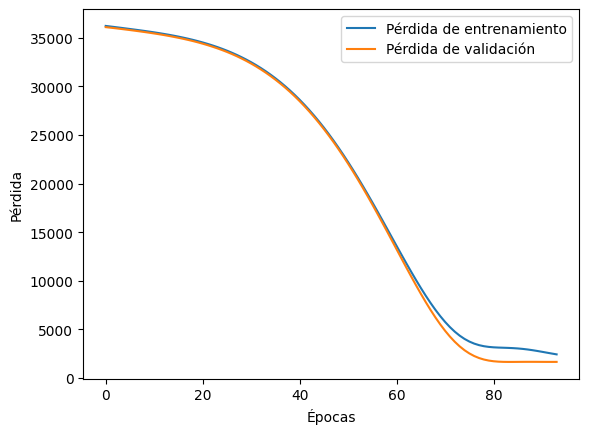

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Cargar el archivo (asegúrate de haberlo subido a Colab)
file_path = '/content/drive/MyDrive/Datos Tesis/datasetRedN.xlsx'
data = pd.read_excel(file_path)

# Seleccionar las variables relevantes
features = ['nivelRio','Temp Out', 'Out Hum','Dew Pt.', 'Wind Speed', 'Wind Run',
             'Hi Speed','Rain','Rain Rate',
              'In Temp', 'In  Hum','In  Dew', 'In  Heat',
              'In  ET','Wind Samp','ISS Recept']
target = 62053  # Cambia esto si tu columna objetivo tiene otro nombre

X = data[features]
y = data[target]

# Manejar valores faltantes (llenar con la media o eliminar filas, según corresponda)
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Construir el modelo de red neuronal
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Salida con una sola neurona (regresión)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo con Early Stopping
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluar el modelo en los datos de prueba
loss, mae = model.evaluate(X_test_scaled, y_test)
print(f"Mean Absolute Error en el conjunto de prueba: {mae}")

# Graficar la evolución del entrenamiento
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()


In [ ]:


import pandas as pd
# Cargar el dataset desde Google Drive
file_path = '/content/drive/MyDrive/Datos Tesis/datasetRedN.xlsx'
dataset = pd.read_excel(file_path)



In [ ]:
# Imprimir nombres de columnas
print("Columnas originales:", dataset.columns.tolist())

# Limpiar nombres de columnas (remover espacios extra)
dataset.columns = dataset.columns.str.strip()
print("Columnas después de limpiar:", dataset.columns.tolist())


Columnas originales: ['Unnamed: 0', 'nivelRio', 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Wind Run', 'Hi Speed', 'Bar  ', 'Rain', 'Rain Rate', 'Solar Energy', 'Hi Solar Rad.', 'Heat D-D ', 'Cool D-D ', 'In Temp', 'In  Hum', 'In  Dew', 'In  Heat', 'In  ET', 'Wind Samp', 'Wind Tx ', 'ISS Recept', 'Arc. Int.', 60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053, 'fecha']
Columnas después de limpiar: ['Unnamed: 0', 'nivelRio', 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Wind Run', 'Hi Speed', 'Bar', 'Rain', 'Rain Rate', 'Solar Energy', 'Hi Solar Rad.', 'Heat D-D', 'Cool D-D', 'In Temp', 'In  Hum', 'In  Dew', 'In  Heat', 'In  ET', 'Wind Samp', 'Wind Tx', 'ISS Recept', 'Arc. Int.', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'fecha']


In [ ]:
dataset.rename(columns={'nivelRio': 'nivelRio'.strip()}, inplace=True)




In [ ]:
print(dataset['nivelRio'].head())


0    236.280645
1    236.108333
2    236.900000
3    236.842903
4    236.659032
Name: nivelRio, dtype: float64


In [ ]:
if 'nivelRio' in dataset.columns:
    print("La columna 'nivelRio' está presente y limpia.")
else:
    print("La columna 'nivelRio' no está presente después de limpiar.")


La columna 'nivelRio' está presente y limpia.


<ipython-input-26-64186a1bd6d6>:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_data.fillna(long_data.mean(), inplace=True)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 38914.5117 - mae: 197.2261 - val_loss: 38397.1172 - val_mae: 195.9067
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 38378.4570 - mae: 195.8596 - val_loss: 37514.8047 - val_mae: 193.6348
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37233.4414 - mae: 192.9082 - val_loss: 35586.8477 - val_mae: 188.5641
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 35040.8320 - mae: 187.0982 - val_loss: 31595.7871 - val_mae: 177.5589
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30128.0684 - mae: 173.2845 - val_loss: 24289.5723 - val_mae: 155.1781
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21770.0840 - mae: 146.3542 - val_loss: 13588.6846 - val_mae: 113.7712
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10732.7998 - mae: 98.1688 - val_loss: 4109.7437 - val_mae: 50.9804
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3592.5679 - mae: 48.3832 - val_loss: 241

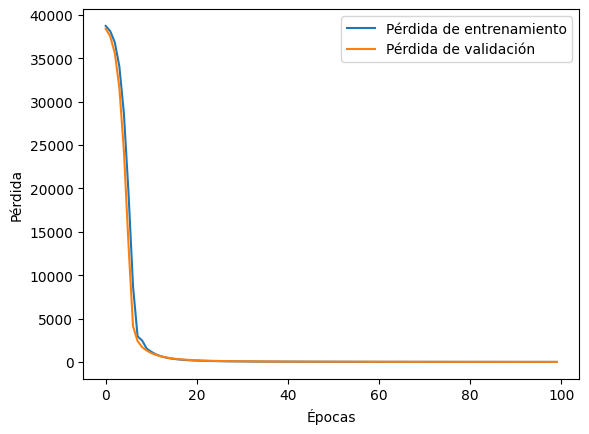

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt



# Identificar las columnas de los freátimetros (asumimos que son columnas numéricas)
freátimetro_columns = freátimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

long_data = dataset.melt(
    id_vars=['fecha', 'nivelRio','Out Hum', 'Dew Pt.', 'Wind Speed', 'Wind Run', 'Rain', 'In Temp'],  # Columnas que no deben pivotar
    value_vars=freátimetro_columns,  # Columnas que sí deben pivotar
    var_name='freátimetro_id',       # Nuevo nombre para identificador de columna
    value_name='nivel_freatico'      # Nuevo nombre para los valores pivotados
)

# Verificar y manejar valores faltantes
long_data.fillna(long_data.mean(), inplace=True)

# Convertir `freátimetro_id` a valores categóricos (si no lo está ya)
long_data['freátimetro_id'] = long_data['freátimetro_id'].astype('category').cat.codes

# Variables de entrada y salida
features = ['nivelRio', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Wind Run', 'Rain', 'In Temp']
categorical_feature = 'freátimetro_id'
target = 'nivel_freatico'

X_numeric = long_data[features]
X_categorical = long_data[categorical_feature]
y = long_data[target]

# Dividir en conjuntos de entrenamiento y prueba
X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_numeric, X_categorical, y, test_size=0.2, random_state=42
)

# Escalar las variables numéricas
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# Construcción del modelo
# Entrada numérica
num_input = Input(shape=(X_num_train_scaled.shape[1],), name="numerical_input")

# Entrada categórica
cat_input = Input(shape=(1,), name="categorical_input")
embedding = Embedding(input_dim=len(X_categorical.unique()), output_dim=4)(cat_input)
embedding_flat = Flatten()(embedding)

# Combinar ambas entradas
concat = Concatenate()([num_input, embedding_flat])

# Capas densas
x = Dense(128, activation='relu')(concat)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='linear', name="output")(x)

# Crear modelo
model = Model(inputs=[num_input, cat_input], outputs=output)

# Compilar modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenamiento del modelo
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    [X_num_train_scaled, X_cat_train], y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

# Evaluar el modelo
loss, mae = model.evaluate([X_num_test_scaled, X_cat_test], y_test)
print(f"Mean Absolute Error en el conjunto de prueba: {mae}")

# Graficar la evolución del entrenamiento
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()


In [ ]:
# Verificar qué columnas fueron detectadas como freátimetros
print("Columnas detectadas como freátimetros:", freátimetro_columns)


Columnas detectadas como freátimetros: []


In [ ]:
predicciones = model.predict([X_num_test_scaled, X_cat_test])

# Mostrar las primeras 10 predicciones junto con los valores reales
for i in range(10):
    print(f"Predicción: {predicciones[i][0]:.2f}, Valor Real: {y_test.iloc[i]:.2f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicción: 189.25, Valor Real: 194.05
Predicción: 202.87, Valor Real: 201.95
Predicción: 183.96, Valor Real: 190.00
Predicción: 192.13, Valor Real: 191.94
Predicción: 195.08, Valor Real: 196.16
Predicción: 194.42, Valor Real: 199.37
Predicción: 192.92, Valor Real: 191.23
Predicción: 201.30, Valor Real: 201.89
Predicción: 193.35, Valor Real: 191.35
Predicción: 198.49, Valor Real: 199.99


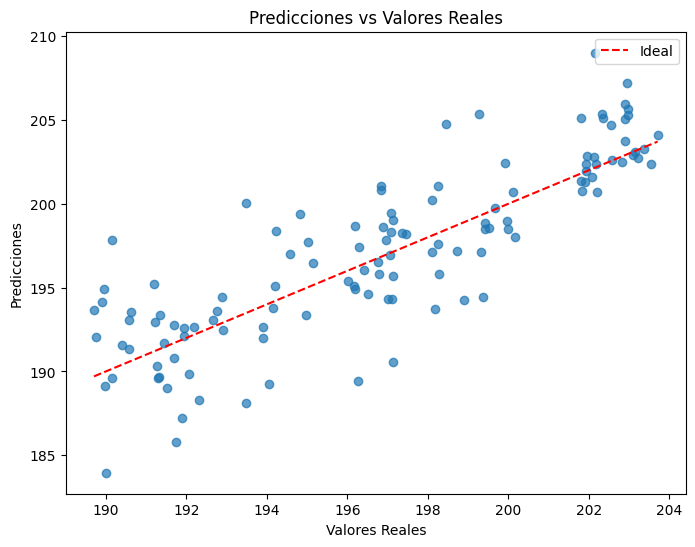

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicciones, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predicciones)
print(f"R²: {r2:.2f}")


R²: 0.58


In [ ]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
print(f"RMSE: {rmse:.2f}")


RMSE: 2.81


In [ ]:
# Definir las columnas de freátimetros y variables ambientales clave
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]
variables_ambientales = ['nivelRio',       'Temp Out',        'Hi Temp',       'Low Temp',
              'Out Hum',        'Dew Pt.',     'Wind Speed',       'Wind Run',
             'Hi Speed',          'Bar  ',           'Rain',      'Rain Rate',
         'Solar Energy', 'Hi Solar Rad.',      'Heat D-D ',      'Cool D-D ',
              'In Temp',        'In  Hum',        'In  Dew',       'In  Heat',
              'In  ET',      'Wind Samp',       'Wind Tx ',     'ISS Recept']

# Extraer correlaciones entre freátimetros y las variables ambientales clave
correlation_with_freatimetros = correlation_matrix.loc[freatimetros, variables_ambientales]
print(correlation_with_freatimetros)


       nivelRio  Temp Out   Hi Temp  Low Temp   Out Hum   Dew Pt.  Wind Speed  \
60040 -0.210745  0.046808  0.045780  0.048345  0.155261  0.195198   -0.075253   
60075  0.363201  0.067450  0.067748  0.067340 -0.023909  0.036767   -0.088269   
60160  0.260386  0.032448  0.030995  0.033574  0.135871  0.187830   -0.137837   
60300 -0.128415  0.010173  0.008116  0.012473  0.294209  0.324932   -0.282027   
60440 -0.047730  0.096227  0.095101  0.097172  0.225901  0.315596   -0.449908   
60460  0.269151 -0.015491 -0.015648 -0.015219  0.016086  0.012782   -0.218306   
60610  0.323835 -0.119938 -0.118000 -0.121894 -0.178893 -0.239705    0.155109   
60771  0.014803  0.025873  0.022872  0.029100  0.261388  0.292489   -0.255251   
60933  0.024749  0.101580  0.100055  0.103178  0.078162  0.146545   -0.077116   
60947  0.014842  0.115257  0.115201  0.115103 -0.023679  0.047161   -0.028723   
60955  0.066785  0.017375  0.014618  0.020014  0.262232  0.308912   -0.130089   
61250  0.059365 -0.112972 -0

In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    dataset,
    id_vars=['fecha', 'nivelRio', 'Temp Out', 'Rain', 'Out Hum'],  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['fecha', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['fecha'].dtype)
print(long_data['fecha'].head())
long_data = long_data[
    (long_data['fecha'].dt.month.isin([5, 6, 7, 8])) &
    (long_data['fecha'].dt.year.between(2010, 2019))
]

# Revisar el resultado de la transformación
print(long_data)


datetime64[ns]
0     2010-05-01
40    2010-05-01
80    2010-05-01
120   2010-05-01
160   2010-05-01
Name: fecha, dtype: datetime64[ns]
         fecha    nivelRio   Temp Out      Rain    Out Hum freátimetro_id  \
0   2010-05-01  236.280645   9.539662  0.939028  67.054411          60040   
40  2010-05-01  236.280645   9.539662  0.939028  67.054411          60075   
80  2010-05-01  236.280645   9.539662  0.939028  67.054411          60160   
120 2010-05-01  236.280645   9.539662  0.939028  67.054411          60300   
160 2010-05-01  236.280645   9.539662  0.939028  67.054411          60440   
..         ...         ...        ...       ...        ...            ...   
439 2019-08-01  236.119355  10.167212  0.001339  66.467758          60955   
479 2019-08-01  236.119355  10.167212  0.001339  66.467758          61250   
519 2019-08-01  236.119355  10.167212  0.001339  66.467758          61271   
559 2019-08-01  236.119355  10.167212  0.001339  66.467758          61383   
599 2019-08-01  23

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Convertir 'freátimetro_id' a una representación categórica
label_encoder = LabelEncoder()
long_data['freátimetro_id'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# Seleccionar las características (X) y el objetivo (y)
features = ['nivelRio', 'Temp Out', 'Rain', 'Out Hum', 'freátimetro_id']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id'

# Combinar las columnas escaladas con 'freátimetro_id' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales:")
print("Primeras predicciones vs valores reales:")
for pred, real in zip(y_pred[:5], y_test_descaled[:5]):
    print(f"Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")



Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.9139 - mae: 0.7919 - val_loss: 0.8941 - val_mae: 0.7639
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8837 - mae: 0.7430 - val_loss: 0.8210 - val_mae: 0.7174
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7050 - mae: 0.6291 - val_loss: 0.7452 - val_mae: 0.6544
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6348 - mae: 0.5820 - val_loss: 0.6724 - val_mae: 0.5952
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5704 - mae: 0.5092 - val_loss: 0.6256 - val_mae: 0.5489
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5248 - mae: 0.4634 - val_loss: 0.5931 - val_mae: 0.5275
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5163 - mae: 0.4465 - val_loss: 0.5763 - val_mae: 0.5026
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5183 - mae: 0.4395 - val_loss: 0.5683 - val_mae: 0.4968
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4960 - mae: 0.4328 - v

In [ ]:
# Desescalar las predicciones y los valores reales si aún no lo has hecho
y_pred_desescalado = scaler_y.inverse_transform(y_pred_scaled)
y_test_desescalado = scaler_y.inverse_transform(y_test)


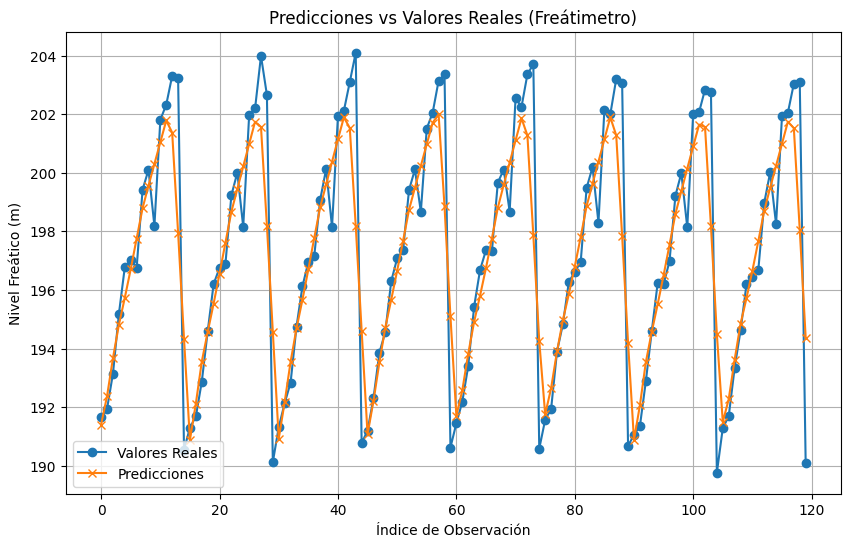

In [ ]:
import matplotlib.pyplot as plt

# Graficar las predicciones vs los valores reales
plt.figure(figsize=(10, 6))
plt.plot(y_test_desescalado, label="Valores Reales", marker='o')
plt.plot(y_pred_desescalado, label="Predicciones", marker='x')
plt.title("Predicciones vs Valores Reales (Freátimetro)")
plt.xlabel("Índice de Observación")
plt.ylabel("Nivel Freático (m)")
plt.legend()
plt.grid(True)
plt.show()


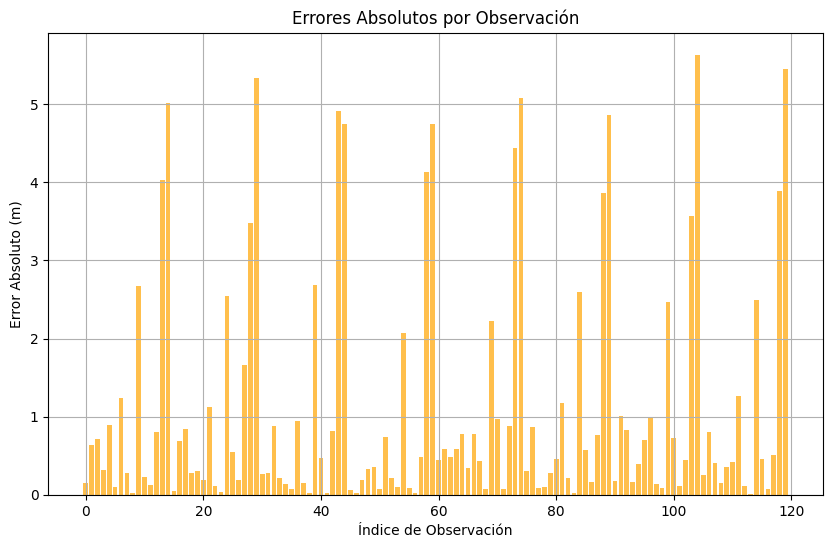

In [ ]:
# Calcular errores absolutos
errores_absolutos = abs(y_test_desescalado - y_pred_desescalado)

# Graficar errores absolutos
plt.figure(figsize=(10, 6))
plt.bar(range(len(errores_absolutos)), errores_absolutos.flatten(), color='orange', alpha=0.7)
plt.title("Errores Absolutos por Observación")
plt.xlabel("Índice de Observación")
plt.ylabel("Error Absoluto (m)")
plt.grid(True)
plt.show()


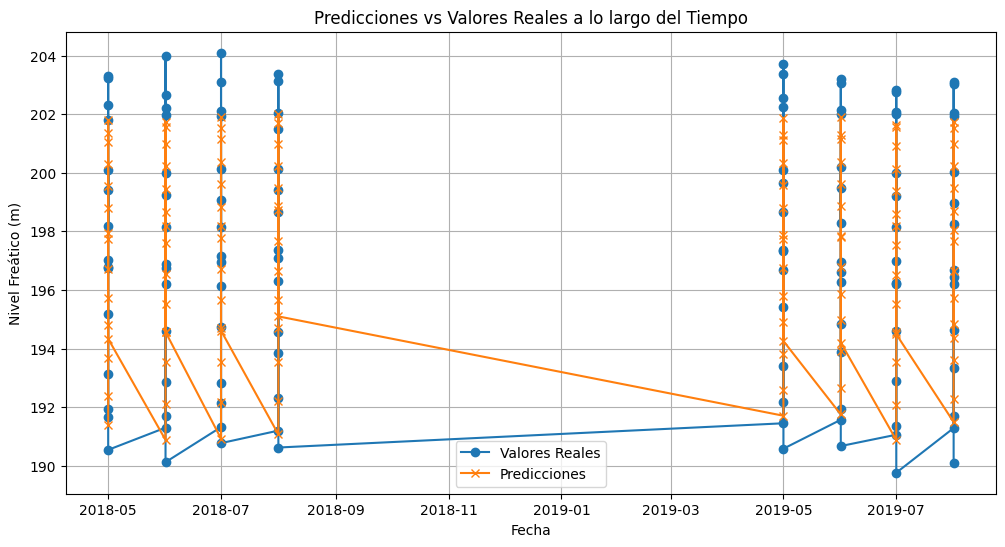

In [ ]:
# Extraer las fechas correspondientes al conjunto de prueba
fechas_test = long_data['fecha'][-len(y_test_desescalado):]

# Graficar valores reales y predicciones con fechas
plt.figure(figsize=(12, 6))
plt.plot(fechas_test, y_test_desescalado, label="Valores Reales", marker='o')
plt.plot(fechas_test, y_pred_desescalado, label="Predicciones", marker='x')
plt.title("Predicciones vs Valores Reales a lo largo del Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Nivel Freático (m)")
plt.legend()
plt.grid(True)
plt.show()


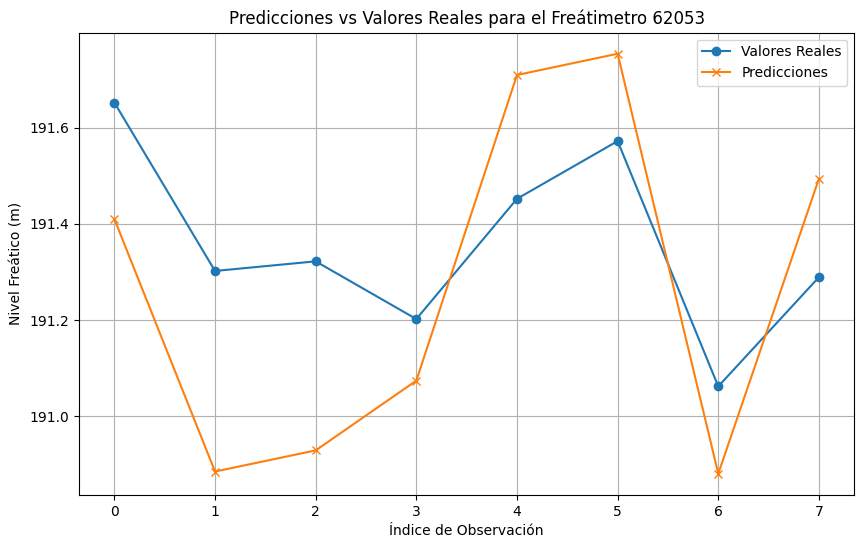

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar un freátimetro específico (por ejemplo, 62053)
id_freatimetro = label_encoder.transform([60040])[0]  # Codificar el identificador

# Filtrar datos del conjunto de prueba para este freátimetro
mask = (X_test[:, 0, -1] == id_freatimetro)  # Verificar la columna de freátimetro_id
y_test_filtrado = y_test_desescalado[mask]
y_pred_filtrado = y_pred_desescalado[mask]

# Crear índices consecutivos para el gráfico
indices = np.arange(len(y_test_filtrado))

# Graficar valores reales y predicciones
plt.figure(figsize=(10, 6))
plt.plot(indices, y_test_filtrado, label="Valores Reales", marker='o')
plt.plot(indices, y_pred_filtrado, label="Predicciones", marker='x')
plt.title(f"Predicciones vs Valores Reales para el Freátimetro {62053}")
plt.xlabel("Índice de Observación")
plt.ylabel("Nivel Freático (m)")
plt.legend()
plt.grid(True)
plt.show()


32   2018-05-01
33   2018-06-01
34   2018-07-01
35   2018-08-01
36   2019-05-01
37   2019-06-01
38   2019-07-01
39   2019-08-01
Name: fecha, dtype: datetime64[ns]


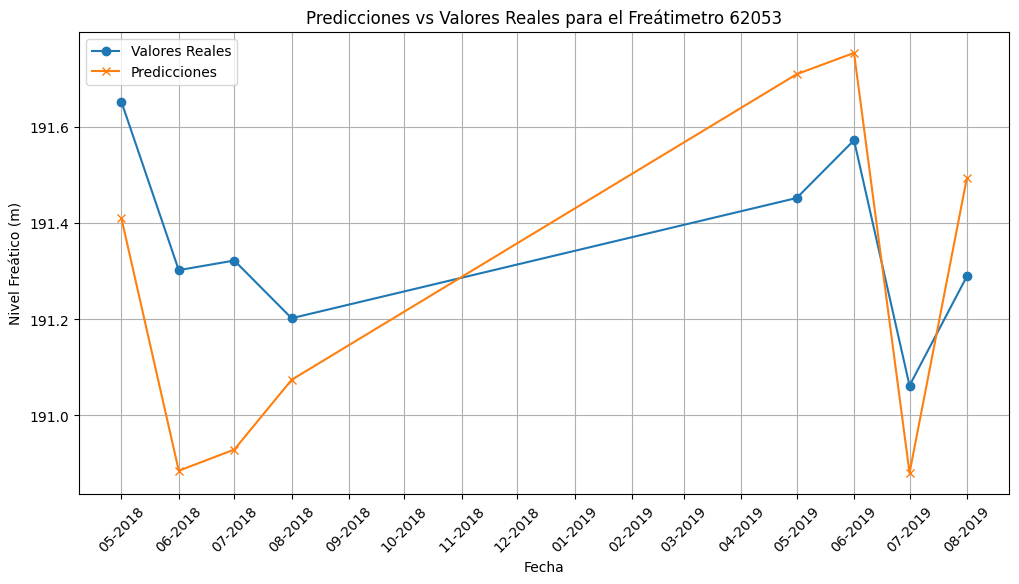

In [ ]:
import matplotlib.dates as mdates
# Seleccionar un freátimetro específico (por ejemplo, 62053)
id_freatimetro = label_encoder.transform([60040])[0]  # Codificar el identificador

# Filtrar datos del conjunto de prueba para este freátimetro
mask = (X_test[:, 0, -1] == id_freatimetro)  # Verificar la columna de freátimetro_id
y_test_filtrado = y_test_desescalado[mask]
y_pred_filtrado = y_pred_desescalado[mask]

  # Asegúrate de que coincidan con los meses y años correctos

# Filtrar las fechas correspondientes al conjunto de prueba
fechas_test = long_data['fecha'][-len(y_test_desescalado):][mask]
print(fechas_test)
# Graficar valores reales y predicciones con fechas en el eje X
plt.figure(figsize=(12, 6))
plt.plot(fechas_test, y_test_filtrado, label="Valores Reales", marker='o')
plt.plot(fechas_test, y_pred_filtrado, label="Predicciones", marker='x')
plt.title(f"Predicciones vs Valores Reales para el Freátimetro {62053}")
plt.xlabel("Fecha")
plt.ylabel("Nivel Freático (m)")
# Formatear las etiquetas del eje X como "mes/año"
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Mostrar etiquetas mensuales

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


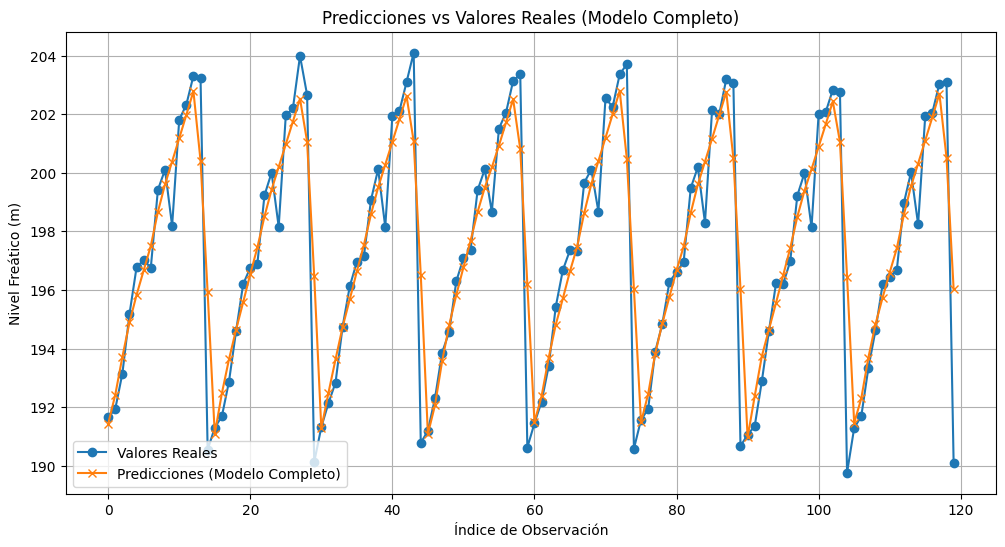

In [ ]:
# Código para el gráfico
plt.figure(figsize=(12, 6))
plt.plot(y_test_descaled, label="Valores Reales", marker='o')
plt.plot(y_pred, label="Predicciones (Modelo Completo)", marker='x')
plt.title("Predicciones vs Valores Reales (Modelo Completo)")
plt.xlabel("Índice de Observación")
plt.ylabel("Nivel Freático (m)")
plt.legend()
plt.grid(True)
plt.show()


# limpiar datos clima


In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd

file_path = '/content/drive/MyDrive/Datos Tesis/datosClima/regina2009_2019.xlsx'
nombre_pestaña = 'regina'
data = pd.read_excel(file_path, sheet_name=nombre_pestaña)




In [ ]:
print(data.head(10))

       Date    Time Temp Out Hi Temp Low Temp Out Hum Dew Pt.  Wind Speed  \
0  05/07/09  4:20 p     19.5    19.6     19.3      31     1.9        17.7   
1  05/07/09  4:30 p     19.4    19.5     19.4      30     1.4        20.9   
2  05/07/09  4:40 p     19.4    19.4     19.4      30     1.4        20.9   
3  05/07/09  4:50 p     19.2    19.4     19.0      31     1.6        17.7   
4  05/07/09  5:00 p     19.1    19.1     19.0      31     1.5        16.1   
5  05/07/09  5:10 p     18.9    19.2     18.7      31     1.4        11.3   
6  05/07/09  5:20 p     18.4    18.7     18.2      31     1.0        14.5   
7  05/07/09  5:30 p     18.2    18.2     18.2      30     0.3        14.5   
8  05/07/09  5:40 p     18.1    18.2     17.8      31     0.6        14.5   
9  05/07/09  5:50 p     17.8    17.8     17.7      29    -0.5        17.7   

  Wind Dir  Wind Run  ...  Cool D-D In Temp In Hum In Dew In Heat   ET  \
0      WNW      2.95  ...     0.008    14.7     51    4.7    13.7  0.0   
1   

In [ ]:
# Importar librerías necesarias
import pandas as pd


# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)  # Asegurar formato correcto

# Definir el rango de fechas esperado
fecha_inicio = pd.to_datetime("2010-01-28")
fecha_fin = pd.to_datetime("2019-09-17")

# Crear un rango de fechas completo
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Comparar con las fechas existentes en el DataFrame
fechas_presentes = set(df['Date'].dropna().unique())  # Fechas reales en el dataset
fechas_faltantes = sorted(set(rango_fechas) - fechas_presentes)  # Fechas ausentes

# Mostrar resultados
print(f"Total de días en el período: {len(rango_fechas)}")
print(f"Total de días faltantes: {len(fechas_faltantes)}")

# Mostrar las fechas faltantes
if fechas_faltantes:
    print("\nDías faltantes en la serie temporal:")
    for fecha in fechas_faltantes:
        print(fecha.strftime("%Y-%m-%d"))
else:
    print("No faltan días en el conjunto de datos.")

# Guardar las fechas faltantes en un archivo CSV para análisis posterior
df_faltantes = pd.DataFrame(fechas_faltantes, columns=['Fechas Faltantes'])

print(df_faltantes)

<ipython-input-5-00192db5ab50>:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)  # Asegurar formato correcto


Total de días en el período: 3520
Total de días faltantes: 129

Días faltantes en la serie temporal:
2010-02-16
2010-02-17
2010-02-18
2010-02-19
2010-02-20
2010-02-21
2010-02-22
2010-02-23
2010-02-24
2010-02-25
2010-02-26
2010-02-27
2010-02-28
2012-02-10
2012-02-11
2012-08-15
2014-04-05
2014-04-06
2014-04-07
2014-04-08
2014-08-24
2015-11-06
2015-11-07
2015-11-08
2015-11-09
2015-11-10
2015-11-11
2015-11-12
2015-11-13
2015-11-14
2015-11-15
2015-11-16
2015-11-17
2015-11-18
2015-11-19
2015-11-20
2015-11-21
2015-11-22
2015-11-23
2015-11-24
2015-11-25
2015-11-26
2015-11-27
2015-11-28
2015-11-29
2015-11-30
2017-08-11
2017-08-12
2017-08-13
2017-08-14
2017-08-15
2017-08-16
2017-08-17
2017-08-18
2017-08-19
2017-08-20
2017-08-21
2017-08-22
2017-08-23
2017-08-24
2017-08-25
2017-08-26
2017-08-27
2017-08-28
2017-08-29
2017-08-30
2017-08-31
2017-09-01
2017-09-02
2017-09-03
2017-09-04
2017-09-05
2017-09-06
2017-09-07
2017-09-08
2017-09-09
2017-09-10
2017-09-11
2017-09-12
2017-09-13
2017-09-14
2017-09-

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np

df=data

# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)  # Asegurar formato correcto

# Definir el rango de fechas esperado
fecha_inicio = pd.to_datetime("2010-01-28")
fecha_fin = pd.to_datetime("2019-09-17")
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')  # Crear todas las fechas del período

# Crear un DataFrame con el rango de fechas completo
df_completo = pd.DataFrame({'Date': rango_fechas})

# Combinar el DataFrame original con el DataFrame de fechas completas
df_merged = pd.merge(df_completo, df, on="Date", how="left")  # Unir, manteniendo todas las fechas

# Rellenar las nuevas filas con NaN en las columnas numéricas
df_merged = df_merged.sort_values("Date").reset_index(drop=True)

# Verificar cuántos valores faltantes hay ahora en el conjunto de datos
missing_values = df_merged.isnull().sum()
print("\nValores nulos por columna después de agregar las fechas faltantes:")
print(missing_values)



<ipython-input-16-233d0624c6bc>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)  # Asegurar formato correcto



Valores nulos por columna después de agregar las fechas faltantes:
Date                0
Time              129
Temp Out          129
Hi Temp           129
Low Temp          129
Out Hum           129
Dew Pt.           129
Wind Speed        129
Wind Dir          129
Wind Run          129
Hi Speed          129
Hi Dir            129
Wind Chill        129
Heat Index        129
THW Index         129
THSW Index        129
Bar               129
Rain              129
Rain Rate         129
Solar Rad.        129
Solar Energy      129
Hi Solar Rad.     129
Heat D-D          129
Cool D-D          129
In Temp           129
In  Hum           129
In  Dew           129
In  Heat          129
In  ET            129
Wind Samp         129
Wind Tx           129
ISS Recept        129
Arc. Int.         129
dtype: int64


In [ ]:
# Lista de columnas que no deseas convertir a float
dataaux=data
non_float_columns = [
   'Wind Dir', 'Hi Dir','Wind Tx','Date','Time'
]

# Convertir todas las columnas a float excepto las que están en non_float_columns
for col in dataaux.columns:
    if col not in non_float_columns:
        # Intentar convertir a float, manejar errores si ocurren
        dataaux[col] = pd.to_numeric(dataaux[col], errors='coerce')

# Mostrar el tipo de datos después de la conversión
print(dataaux.dtypes)

Date              object
Time              object
Temp Out         float64
Hi Temp          float64
Low Temp         float64
Out Hum          float64
Dew Pt.          float64
Wind Speed       float64
Wind Dir          object
Wind Run         float64
Hi Speed         float64
Hi Dir            object
Wind Chill       float64
Heat Index       float64
THW Index        float64
THSW Index       float64
Bar              float64
Rain             float64
Rain Rate        float64
Solar Rad.       float64
Solar Energy     float64
Hi Solar Rad.    float64
Heat D-D         float64
Cool D-D         float64
In Temp          float64
In Hum           float64
In Dew           float64
In Heat          float64
ET               float64
Wind Samp          int64
Wind Tx            int64
ISS Recept       float64
Arc. Int.          int64
dtype: object


In [ ]:
columns_to_remove = ['Wind Dir', 'Hi Dir', 'Wind Tx','Time','THSW Index']

# Eliminar las columnas especificadas
dataaux = dataaux.drop(columns=columns_to_remove, errors='ignore')

In [ ]:
print(dataaux.head())

       Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  \
0  05/07/09      19.5     19.6      19.3     31.0      1.9        17.7   
1  05/07/09      19.4     19.5      19.4     30.0      1.4        20.9   
2  05/07/09      19.4     19.4      19.4     30.0      1.4        20.9   
3  05/07/09      19.2     19.4      19.0     31.0      1.6        17.7   
4  05/07/09      19.1     19.1      19.0     31.0      1.5        16.1   

   Wind Run  Hi Speed  Wind Chill  ...  Heat D-D  Cool D-D  In Temp  In Hum  \
0      2.95      32.2        18.1  ...       0.0     0.008     14.7    51.0   
1      3.49      40.2        17.4  ...       0.0     0.008     14.8    50.0   
2      3.49      32.2        17.4  ...       0.0     0.008     14.9    50.0   
3      2.95      40.2        17.7  ...       0.0     0.006     15.0    49.0   
4      2.68      32.2        17.9  ...       0.0     0.005     15.0    49.0   

   In Dew  In Heat   ET  Wind Samp  ISS Recept  Arc. Int.  
0     4.7     13.7  

In [ ]:
import numpy as np
# Simula que `data` es el DataFrame principal
dfs = {'regina': dataaux}

# Función para analizar valores nulos
def analyze_and_filter(df, sheet_name):
    print(f"\nProcesando la hoja: {sheet_name}")

    # Reemplazar el símbolo `---` por NaN
    df.replace('---', np.nan, inplace=True)

    # Identificar columnas con valores nulos
    null_counts = df.isnull().sum()
    null_columns = null_counts[null_counts > 0]
    if not null_columns.empty:
        print("Valores nulos por columna:")
        print(null_columns)
    else:
        print("No se encontraron valores nulos en esta hoja.")

# Llamar a la función para cada hoja
for sheet_name, df in dfs.items():
    analyze_and_filter(df, sheet_name)




Procesando la hoja: regina
Valores nulos por columna:
Temp Out         7746
Hi Temp          7740
Low Temp         7754
Out Hum          7506
Dew Pt.          7764
Wind Chill       7744
Heat Index       7768
THW Index        7768
Bar                 1
Solar Rad.       7502
Solar Energy     7502
Hi Solar Rad.    7502
Heat D-D         7467
Cool D-D         7467
In Temp             2
In Hum              1
In Dew              2
In Heat             2
dtype: int64


In [ ]:
date_to_check = "03/04/10"

data_for_date =df[(df['Date'] == date_to_check)]


print(data_for_date.head(50))

           Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  \
32590  03/04/10      11.9     12.0      11.8     48.0      1.3         0.0   
32591  03/04/10      12.2     12.4      11.8     41.0     -0.7         0.0   
32592  03/04/10      12.1     12.4      11.9     43.0     -0.1         0.0   
32593  03/04/10      12.0     12.1      11.9     41.0     -0.9         0.0   
32594  03/04/10      12.1     12.2      12.0     42.0     -0.4         0.0   
32595  03/04/10      12.2     12.2      12.1     42.0     -0.4         0.0   
32596  03/04/10      12.0     12.1      11.8     42.0     -0.5         0.0   
32597  03/04/10      11.7     11.8      11.6     44.0     -0.1         0.0   
32598  03/04/10      11.6     11.6      11.6     44.0     -0.2         0.0   
32599  03/04/10      11.6     11.8      11.6     44.0     -0.2         1.6   
32600  03/04/10      11.9     12.0      11.8     48.0      1.3         4.8   
32601  03/04/10      12.0     12.0      11.9     50.0      1.9  

In [ ]:
df = dfs['regina']
# Crear una copia del DataFrame solo con columnas numéricas (KNNImputer solo funciona con números)
numeric_cols = df.select_dtypes(include=['number']).columns
df_numeric = df[numeric_cols]
print(df_numeric.head())

   Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  Wind Run  \
0      19.5     19.6      19.3     31.0      1.9        17.7      2.95   
1      19.4     19.5      19.4     30.0      1.4        20.9      3.49   
2      19.4     19.4      19.4     30.0      1.4        20.9      3.49   
3      19.2     19.4      19.0     31.0      1.6        17.7      2.95   
4      19.1     19.1      19.0     31.0      1.5        16.1      2.68   

   Hi Speed  Wind Chill  Heat Index  ...  Heat D-D  Cool D-D  In Temp  In Hum  \
0      32.2        18.1        17.6  ...       0.0     0.008     14.7    51.0   
1      40.2        17.4        17.4  ...       0.0     0.008     14.8    50.0   
2      32.2        17.4        17.4  ...       0.0     0.008     14.9    50.0   
3      40.2        17.7        17.2  ...       0.0     0.006     15.0    49.0   
4      32.2        17.9        17.1  ...       0.0     0.005     15.0    49.0   

   In Dew  In Heat   ET  Wind Samp  ISS Recept  Arc. Int.  
0     4.

In [ ]:
from sklearn.impute import KNNImputer
import pandas as pd

df = dfs['regina']

# Seleccionar solo las primeras 100,000 filas
df_subset = df.iloc[:100000].copy()

# Seleccionar solo las columnas numéricas
numeric_cols = df_subset.select_dtypes(include=['number']).columns
df_numeric = df_subset[numeric_cols]

# Crear el imputador KNN con n_neighbors=1
imputer = KNNImputer(n_neighbors=1)

# Rellenar los valores nulos solo en este subconjunto
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=numeric_cols)

# Reemplazar las columnas originales con las imputadas en el subconjunto
df_subset[numeric_cols] = df_numeric_imputed

# Mostrar el resultado en las primeras 50 filas
print("Valores nulos rellenados en las primeras 100,000 filas:")
print(df_subset.head(50))


Valores nulos rellenados en las primeras 100,000 filas:
        Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  \
0   05/07/09      19.5     19.6      19.3     31.0      1.9        17.7   
1   05/07/09      19.4     19.5      19.4     30.0      1.4        20.9   
2   05/07/09      19.4     19.4      19.4     30.0      1.4        20.9   
3   05/07/09      19.2     19.4      19.0     31.0      1.6        17.7   
4   05/07/09      19.1     19.1      19.0     31.0      1.5        16.1   
5   05/07/09      18.9     19.2      18.7     31.0      1.4        11.3   
6   05/07/09      18.4     18.7      18.2     31.0      1.0        14.5   
7   05/07/09      18.2     18.2      18.2     30.0      0.3        14.5   
8   05/07/09      18.1     18.2      17.8     31.0      0.6        14.5   
9   05/07/09      17.8     17.8      17.7     29.0     -0.5        17.7   
10  05/07/09      17.6     17.8      17.5     28.0     -1.1        17.7   
11  05/07/09      17.4     17.5      17.4   

In [ ]:
# Importar las bibliotecas necesarias

from sklearn.impute import KNNImputer

df = dfs['regina']
# Crear una copia del DataFrame solo con columnas numéricas (KNNImputer solo funciona con números)
numeric_cols = df.select_dtypes(include=['number']).columns
df_numeric = df[numeric_cols]

# Crear el imputador KNN (puedes ajustar `n_neighbors` según lo necesites)
imputer = KNNImputer(n_neighbors=1)

# Rellenar los valores nulos
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=numeric_cols)

# Reemplazar las columnas originales con las imputadas
df[numeric_cols] = df_numeric_imputed

# Mostrar el resultado
print("Valores nulos rellenados:")
print(df.head(50))


Valores nulos rellenados:
        Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  \
0   05/07/09      19.5     19.6      19.3     31.0      1.9        17.7   
1   05/07/09      19.4     19.5      19.4     30.0      1.4        20.9   
2   05/07/09      19.4     19.4      19.4     30.0      1.4        20.9   
3   05/07/09      19.2     19.4      19.0     31.0      1.6        17.7   
4   05/07/09      19.1     19.1      19.0     31.0      1.5        16.1   
5   05/07/09      18.9     19.2      18.7     31.0      1.4        11.3   
6   05/07/09      18.4     18.7      18.2     31.0      1.0        14.5   
7   05/07/09      18.2     18.2      18.2     30.0      0.3        14.5   
8   05/07/09      18.1     18.2      17.8     31.0      0.6        14.5   
9   05/07/09      17.8     17.8      17.7     29.0     -0.5        17.7   
10  05/07/09      17.6     17.8      17.5     28.0     -1.1        17.7   
11  05/07/09      17.4     17.5      17.4     26.0     -2.3        20.9   

In [ ]:
date_to_check = "20/04/10"

data_for_date =df[(df['Date'] == date_to_check)]


print(data_for_date.head(50))

           Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  \
35038  20/04/10      15.8     15.8      15.7     46.0      4.2         0.0   
35039  20/04/10      15.7     15.8      15.7     47.0      4.4         1.6   
35040  20/04/10      15.8     15.8      15.8     46.0      4.2         4.8   
35041  20/04/10      15.8     15.8      15.7     46.0      4.2         4.8   
35042  20/04/10      15.6     15.7      15.5     47.0      4.3         3.2   
35043  20/04/10      15.3     15.5      15.3     48.0      4.4         4.8   
35044  20/04/10      15.1     15.3      14.9     49.0      4.5         3.2   
35045  20/04/10      14.8     14.9      14.7     50.0      4.4         3.2   
35046  20/04/10      14.6     14.7      14.4     51.0      4.5         0.0   
35047  20/04/10      14.2     14.4      14.1     52.0      4.4         0.0   
35048  20/04/10      13.8     14.1      13.7     54.0      4.7         0.0   
35049  20/04/10      13.4     13.6      13.1     55.0      4.5  

In [ ]:
df.to_excel('/content/drive/MyDrive/Datos Tesis/datosClima/clima20102019Imputado.xlsx')

In [ ]:
file_path = '/content/drive/MyDrive/Datos Tesis/datosClima/clima20102019Imputado.xlsx'
nombre_pestaña = 'Sheet1'
df = pd.read_excel(file_path, sheet_name=nombre_pestaña)

KeyboardInterrupt: 

In [ ]:
print(df.head())

        Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  Wind Speed  \
0 2009-07-05      19.5     19.6      19.3     31.0      1.9        17.7   
1 2009-07-05      19.4     19.5      19.4     30.0      1.4        20.9   
2 2009-07-05      19.4     19.4      19.4     30.0      1.4        20.9   
3 2009-07-05      19.2     19.4      19.0     31.0      1.6        17.7   
4 2009-07-05      19.1     19.1      19.0     31.0      1.5        16.1   

   Wind Run  Hi Speed  Wind Chill  ...  Heat D-D  Cool D-D  In Temp  In Hum  \
0      2.95      32.2        18.1  ...       0.0     0.008     14.7    51.0   
1      3.49      40.2        17.4  ...       0.0     0.008     14.8    50.0   
2      3.49      32.2        17.4  ...       0.0     0.008     14.9    50.0   
3      2.95      40.2        17.7  ...       0.0     0.006     15.0    49.0   
4      2.68      32.2        17.9  ...       0.0     0.005     15.0    49.0   

   In Dew  In Heat   ET  Wind Samp  ISS Recept  Arc. Int.  
0     4.7     

In [ ]:
import pandas as pd


# ✅ **Calcular el promedio por día para todas las variables numéricas**
df_daily_avg = df.groupby('Date').mean().reset_index()  # Restablecer el índice para que 'Date' sea una columna normal

# ✅ **Asegurar que 'Date' esté en el formato correcto**
df_daily_avg['Date'] = pd.to_datetime(df_daily_avg['Date']).dt.date  # Convertir a formato de fecha sin hora

# ✅ **Mostrar las primeras filas**
print(df_daily_avg.head())




         Date   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0  2009-07-05  12.691304  12.882609  12.500000  38.956522 -1.521739   
1  2009-07-06  11.517361  11.707639  11.315278  64.451389  4.486111   
2  2009-07-07   6.769444   6.890278   6.661806  61.715278 -0.438889   
3  2009-07-08   2.854861   3.031250   2.677083  60.243056 -4.985417   
4  2009-07-09   9.146528   9.324306   8.966667  49.847222 -1.356250   

   Wind Speed  Wind Run   Hi Speed  Wind Chill  ...  Heat D-D  Cool D-D  \
0    7.239130  1.207391  15.628261   12.165217  ...  0.040043  0.000870   
1    5.127083  0.855833  11.564583   11.218750  ...  0.047965  0.000604   
2    5.352083  0.892222  13.220833    6.022222  ...  0.080333  0.000000   
3    4.990972  0.832778   9.858333    2.093056  ...  0.107500  0.000000   
4    8.147222  1.358194  17.368750    8.370139  ...  0.063806  0.000000   

     In Temp     In Hum    In Dew    In Heat        ET   Wind Samp  \
0  12.804348  49.565217  2.504348  11.823913  0.0178

In [ ]:
print(df_avg.head)


<bound method NDFrame.head of                  Date   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
Date                                                                          
2009-07-05 2009-07-05  12.691304  12.882609  12.500000  38.956522 -1.521739   
2009-07-06 2009-07-06  11.517361  11.707639  11.315278  64.451389  4.486111   
2009-07-07 2009-07-07   6.769444   6.890278   6.661806  61.715278 -0.438889   
2009-07-08 2009-07-08   2.854861   3.031250   2.677083  60.243056 -4.985417   
2009-07-09 2009-07-09   9.146528   9.324306   8.966667  49.847222 -1.356250   
...               ...        ...        ...        ...        ...       ...   
2019-09-13 2019-09-13  13.749306  13.890278  13.613889  61.138889  5.462500   
2019-09-14 2019-09-14  12.445139  12.608333  12.295139  63.833333  4.702778   
2019-09-15 2019-09-15  11.409028  11.613194  11.220833  46.159722 -1.462500   
2019-09-16 2019-09-16  11.327778  11.485417  11.174306  46.166667 -0.925000   
2019-09-17 2019-09-17 

In [ ]:
import pandas as pd


df_avg = df_daily_avg


if isinstance(df_avg.index, pd.DatetimeIndex):  # Si 'Date' es el índice
    df_avg.reset_index(inplace=True)  # Lo convierte en una columna

df_avg['Date'] = pd.to_datetime(df_avg['Date'])  # Asegurar formato de fecha

# ✅ **Definir el rango de fechas esperado**
fecha_inicio = df_avg['Date'].min()
fecha_fin = df_avg['Date'].max()
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')  # Genera todas las fechas esperadas

# ✅ **Crear un DataFrame con todas las fechas esperadas**
df_completo = pd.DataFrame({'Date': rango_fechas})

# ✅ **Fusionar con el dataset original para agregar los días faltantes con valores nulos**
df_merged = df_completo.merge(df_avg, on='Date', how='left')

# ✅ **Guardar el nuevo dataset con las fechas completas en Google Drive**
ruta_guardado_completo = "/content/drive/My Drive/datos_completos_con_nulos.csv"
df_merged.to_csv(ruta_guardado_completo, index=False)

# ✅ **Mostrar los primeros resultados**
print(f"✅ Se agregaron {len(rango_fechas) - len(df_avg)} días faltantes con valores nulos.")
print(df_merged.head)


✅ Se agregaron 159 días faltantes con valores nulos.


,Date,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Run,Hi Speed,Wind Chill,...,Heat D-D,Cool D-D,In Temp,In Hum,In Dew,In Heat,ET,Wind Samp,ISS Recept,Arc. Int.
0,2009-07-05,12.691304,12.882609,12.500000,38.956522,-1.521739,7.239130,1.207391,15.628261,12.165217,...,0.040043,0.000870,12.804348,49.565217,2.504348,11.823913,0.017826,213.739130,93.752174,10.0
1,2009-07-06,11.517361,11.707639,11.315278,64.451389,4.486111,5.127083,0.855833,11.564583,11.218750,...,0.047965,0.000604,11.893056,58.881944,4.056250,11.264583,0.014167,212.951389,93.399306,10.0
2,2009-07-07,6.769444,6.890278,6.661806,61.715278,-0.438889,5.352083,0.892222,13.220833,6.022222,...,0.080333,0.000000,9.597222,59.055556,1.917361,9.088194,0.009792,212.631944,93.259722,10.0
3,2009-07-08,2.854861,3.031250,2.677083,60.243056,-4.985417,4.990972,0.832778,9.858333,2.093056,...,0.107500,0.000000,6.207639,54.750000,-2.286806,5.658333,0.014167,223.451389,97.918750,10.0
4,2009-07-09,9.146528,9.324306,8.966667,49.847222,-1.356250,8.147222,1.358194,17.368750,8.370139,...,0.063806,0.000000,8.992361,52.472222,-0.250000,8.265972,0.020625,221.125000,96.920833,10.0


In [ ]:
print(df_merged.head)

<bound method NDFrame.head of            Date   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0    2009-07-05  12.691304  12.882609  12.500000  38.956522 -1.521739   
1    2009-07-06  11.517361  11.707639  11.315278  64.451389  4.486111   
2    2009-07-07   6.769444   6.890278   6.661806  61.715278 -0.438889   
3    2009-07-08   2.854861   3.031250   2.677083  60.243056 -4.985417   
4    2009-07-09   9.146528   9.324306   8.966667  49.847222 -1.356250   
...         ...        ...        ...        ...        ...       ...   
3722 2019-09-13  13.749306  13.890278  13.613889  61.138889  5.462500   
3723 2019-09-14  12.445139  12.608333  12.295139  63.833333  4.702778   
3724 2019-09-15  11.409028  11.613194  11.220833  46.159722 -1.462500   
3725 2019-09-16  11.327778  11.485417  11.174306  46.166667 -0.925000   
3726 2019-09-17  11.679592  11.902041  11.471429  42.530612 -0.793878   

      Wind Speed  Wind Run   Hi Speed  Wind Chill  ...  Heat D-D  Cool D-D  \
0       7.23913

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# ✅ **Cargar el dataset**
df = df_merged.copy()

# ✅ **Seleccionar solo las columnas numéricas para la imputación**
numeric_cols = df.select_dtypes(include=['number']).columns  # Solo columnas numéricas

# ✅ **Crear una copia del DataFrame con las columnas numéricas**
df_numeric = df[numeric_cols]

# ✅ **Inicializar el imputador KNN con k=1**
imputer = KNNImputer(n_neighbors=1)

# ✅ **Aplicar la imputación a los datos numéricos**
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=numeric_cols)

# ✅ **Reemplazar las columnas originales con las imputadas**
df[numeric_cols] = df_numeric_imputed

# ✅ **Guardar el dataset imputado en Google Drive**

df.to_csv('/content/drive/My Drive/Datos Tesis/datos_diasfaltantes_imputados.csv', index=False)

# ✅ **Mostrar las primeras filas del dataset imputado**
print("✅ Imputación completada. Primeras filas del dataset:")
print(df.head())


✅ Imputación completada. Primeras filas del dataset:
        Date   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0 2009-07-05  12.691304  12.882609  12.500000  38.956522 -1.521739   
1 2009-07-06  11.517361  11.707639  11.315278  64.451389  4.486111   
2 2009-07-07   6.769444   6.890278   6.661806  61.715278 -0.438889   
3 2009-07-08   2.854861   3.031250   2.677083  60.243056 -4.985417   
4 2009-07-09   9.146528   9.324306   8.966667  49.847222 -1.356250   

   Wind Speed  Wind Run   Hi Speed  Wind Chill  ...  Heat D-D  Cool D-D  \
0    7.239130  1.207391  15.628261   12.165217  ...  0.040043  0.000870   
1    5.127083  0.855833  11.564583   11.218750  ...  0.047965  0.000604   
2    5.352083  0.892222  13.220833    6.022222  ...  0.080333  0.000000   
3    4.990972  0.832778   9.858333    2.093056  ...  0.107500  0.000000   
4    8.147222  1.358194  17.368750    8.370139  ...  0.063806  0.000000   

     In Temp     In Hum    In Dew    In Heat        ET   Wind Samp  \
0  12

In [ ]:
import pandas as pd



# ✅ **Convertir la columna 'Date' a formato datetime si aún no lo está**
df['Date'] = pd.to_datetime(df['Date'])

# ✅ **Extraer el Año-Mes y usarlo como índice**
df['Year-Month'] = df['Date'].dt.to_period('M')

# ✅ **Agrupar por Año-Mes y calcular el promedio**
df_monthly_avg = df.groupby('Year-Month').mean()

# ✅ **Convertir el índice a string para evitar problemas de formato**
df_monthly_avg.index = df_monthly_avg.index.astype(str)

# ✅ **Guardar el dataset con los promedios mensuales en Google Drive**
df_monthly_avg.to_csv('/content/drive/My Drive/Datos Tesis/datosClima/datos_promedios_mensuales_clima.csv')

# ✅ **Mostrar las primeras filas del dataset con promedios mensuales**
print("✅ Promedio mensual calculado. Primeras filas del dataset:")
print(df_monthly_avg.head(50))








✅ Promedio mensual calculado. Primeras filas del dataset:
                          Date   Temp Out    Hi Temp   Low Temp    Out Hum  \
Year-Month                                                                   
2009-07    2009-07-18 00:00:00   5.739338   5.898687   5.577572  58.374933   
2009-08    2009-08-16 00:00:00   9.385439   9.538463   9.232056  57.919803   
2009-09    2009-09-15 12:00:00  10.489282  10.659630  10.321597  52.203241   
2009-10    2009-10-16 00:00:00  14.771685  14.950717  14.595408  41.810260   
2009-11    2009-11-15 12:00:00  16.427291  16.589301  16.263044  41.456834   

             Dew Pt.  Wind Speed  Wind Run   Hi Speed  Wind Chill  ...  \
Year-Month                                                         ...   
2009-07    -2.714951    4.835297  0.806976  10.874401    5.105373  ...   
2009-08     0.469915    3.933737  0.657204   9.174418    9.050493  ...   
2009-09    -0.142037    4.350394  0.726252  10.537176   10.226458  ...   
2009-10     0.591174    6

In [ ]:
print(df_monthly_avg.head(50))

                          Date   Temp Out    Hi Temp   Low Temp    Out Hum  \
Year-Month                                                                   
2009-07    2009-07-18 00:00:00   5.739338   5.898687   5.577572  58.374933   
2009-08    2009-08-16 00:00:00   9.385439   9.538463   9.232056  57.919803   
2009-09    2009-09-15 12:00:00  10.489282  10.659630  10.321597  52.203241   
2009-10    2009-10-16 00:00:00  14.771685  14.950717  14.595408  41.810260   
2009-11    2009-11-15 12:00:00  16.427291  16.589301  16.263044  41.456834   
2009-12    2009-12-16 00:00:00  20.134588  20.323022  19.945063  45.891342   
2010-01    2010-01-16 00:00:00  15.519254  15.679427  15.359879  54.647326   
2010-02    2010-02-14 12:00:00  17.161264  17.345704  16.978229  50.445964   
2010-03    2010-03-16 00:00:00  19.292587  19.465814  19.117658  60.934078   
2010-04    2010-04-15 12:00:00  13.971620  14.102917  13.836181  58.846528   
2010-05    2010-05-16 00:00:00   9.195004   9.353562   9.036850 

In [ ]:
# Asegúrate de que la columna de fecha esté en formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# Crear una nueva columna para el mes y año
df['YearMonth'] = df['Date'].dt.to_period('M')

# Calcular el promedio mensual para cada variable numérica
monthly_means = df.groupby('YearMonth').mean(numeric_only=True)

# Restablecer el índice para que sea un DataFrame plano
monthly_means.reset_index(inplace=True)

# Mostrar los promedios mensuales
print("Promedios mensuales calculados:")
print(monthly_means)

# Guardar el resultado en un archivo si lo necesitas
monthly_means.to_excel('promedios_mensuales.xlsx', index=False)


<ipython-input-38-fe532d2b4c4f>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


Promedios mensuales calculados:
    YearMonth   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0     2010-01  15.532369  15.707670  15.357260  51.051134  3.838688   
1     2010-02  13.979232  14.164694  13.796521  54.516615  3.505192   
2     2010-03  16.235210  16.407503  16.060719  55.326409  6.065328   
3     2010-04  12.797064  12.942457  12.648367  58.892768  3.778008   
4     2010-05   9.538023   9.691519   9.384690  67.053704  2.762995   
..        ...        ...        ...        ...        ...       ...   
115   2019-08  10.167212  10.299876  10.034995  66.467758  3.323239   
116   2019-09  12.114784  12.283863  11.948933  61.575221  3.506715   
117   2019-10  11.982407  12.145602  11.816512  63.270062  4.083102   
118   2019-11  12.371682  12.536420  12.207793  64.993056  4.813272   
119   2019-12  13.283333  13.440664  13.127006  63.064815  4.984028   

     Wind Speed  Wind Run   Hi Speed  Wind Chill  ...  Cool D-D     In Temp  \
0      2.445683  0.408693   7.036951

In [ ]:
import pandas as pd
ruta = "/content/drive/My Drive/Datos Tesis/datosClima/datos_promedios_mensuales_clima.csv"

# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClimaCaso1= pd.read_csv(ruta)
ruta_nivel_rio = '/content/drive/MyDrive/Datos Tesis/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
DF = pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_2010_2023 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)


datosClimaCaso1['Date'] = pd.to_datetime(datosClimaCaso1['Year-Month'])

# Filtrar datos en el periodo 2010-2019 y los meses sin riego para comparar con los datos obtenidos del clima
filtro_datosClima =(datosClimaCaso1['Date'].dt.month.isin([5, 6, 7, 8]))
datosClimaCaso1 = datosClimaCaso1[filtro_datosClima]

filtro_F20102029 = (datos_filtrados_DF['index'].dt.year >= 2010) & (datos_filtrados_DF['index'].dt.year <= 2019)
datos_filtrados_DF = datos_filtrados_DF[filtro_F20102029]




In [ ]:
freatimetrosCaso1=datos_filtrados_DF


In [ ]:
import pandas as pd


datosClima = datosClima.rename(columns={'Date': 'fecha'})
# Asegurar que las columnas 'fecha' de todos los DataFrames estén en formato datetime
datosClima['fecha'] = pd.to_datetime(datosClima['fecha'])


datos_filtrados_DF['fecha'] = pd.to_datetime(datos_filtrados_DF['fecha'])
datos_filtrados_promedios['fecha'] = pd.to_datetime(datos_filtrados_promedios['fecha'])

# Crear columnas de 'año-mes' para los DataFrames
datosClima['año_mes'] = datosClima['fecha'].dt.to_period('M')
datos_filtrados_DF['año_mes'] = datos_filtrados_DF['fecha'].dt.to_period('M')
datos_filtrados_promedios['año_mes'] = datos_filtrados_promedios['fecha'].dt.to_period('M')

# Unir datosClima y datos_filtrados_DF usando 'año_mes' como clave
df_merged = pd.merge(datosClima, datos_filtrados_DF, on='año_mes', how='inner')

# Luego, unir con datos_filtrados_promedios también usando 'año_mes' como clave
df_merged_final = pd.merge(df_merged, datos_filtrados_promedios, on='año_mes', how='inner')

# Renombrar la columna 'promedio' a 'nivelRio'
df_merged_final = df_merged_final.rename(columns={'promedio': 'nivelRio'})
# Reordenar las columnas para que 'nivelRio' esté en la primera posición
cols = ['nivelRio'] + [col for col in df_merged_final.columns if col != 'nivelRio']
df_merged_final = df_merged_final[cols]

df_merged_final = df_merged_final.drop(columns=['index'])
df_merged_final = df_merged_final.drop(columns=['año_mes'])
#df_merged_final = df_merged_final.drop(columns=['fecha'])
df_merged_final = df_merged_final.drop(columns=['fecha_x'])
df_merged_final = df_merged_final.drop(columns=['fecha_y'])
df_merged_final = df_merged_final.drop(columns=['año'])
df_merged_final = df_merged_final.drop(columns=['mes'])
#df_merged_final.to_excel('/content/drive/MyDrive/Datos Tesis/datasetRedN.xlsx')
# Mostrar las primeras filas para verificar la unión
print(df_merged_final.head)

NameError: name 'datosClima' is not defined

In [ ]:
print(datosClima.columns)

NameError: name 'datosClima' is not defined

In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/Datos Tesis/datasetRedN.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datasetMerge = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)

In [ ]:

# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]  # Asegúrate de que esta lista contenga todos los freatímetros que desees incluir.
# Agrega aquí otras variables de interés si lo deseas
variables_interes = ['nivelRio', 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.',
       'Wind Speed', 'Wind Run', 'Hi Speed', 'Heat Index',
       'THW Index', 'Bar  ', 'Rain', 'Rain Rate', 'Solar Rad.', 'Solar Energy',
       'Hi Solar Rad. ', 'Heat D-D ', 'Cool D-D ', 'In Temp', 'In  Hum',
       'In  Dew', 'In  Heat', 'In  ET '
       ,]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

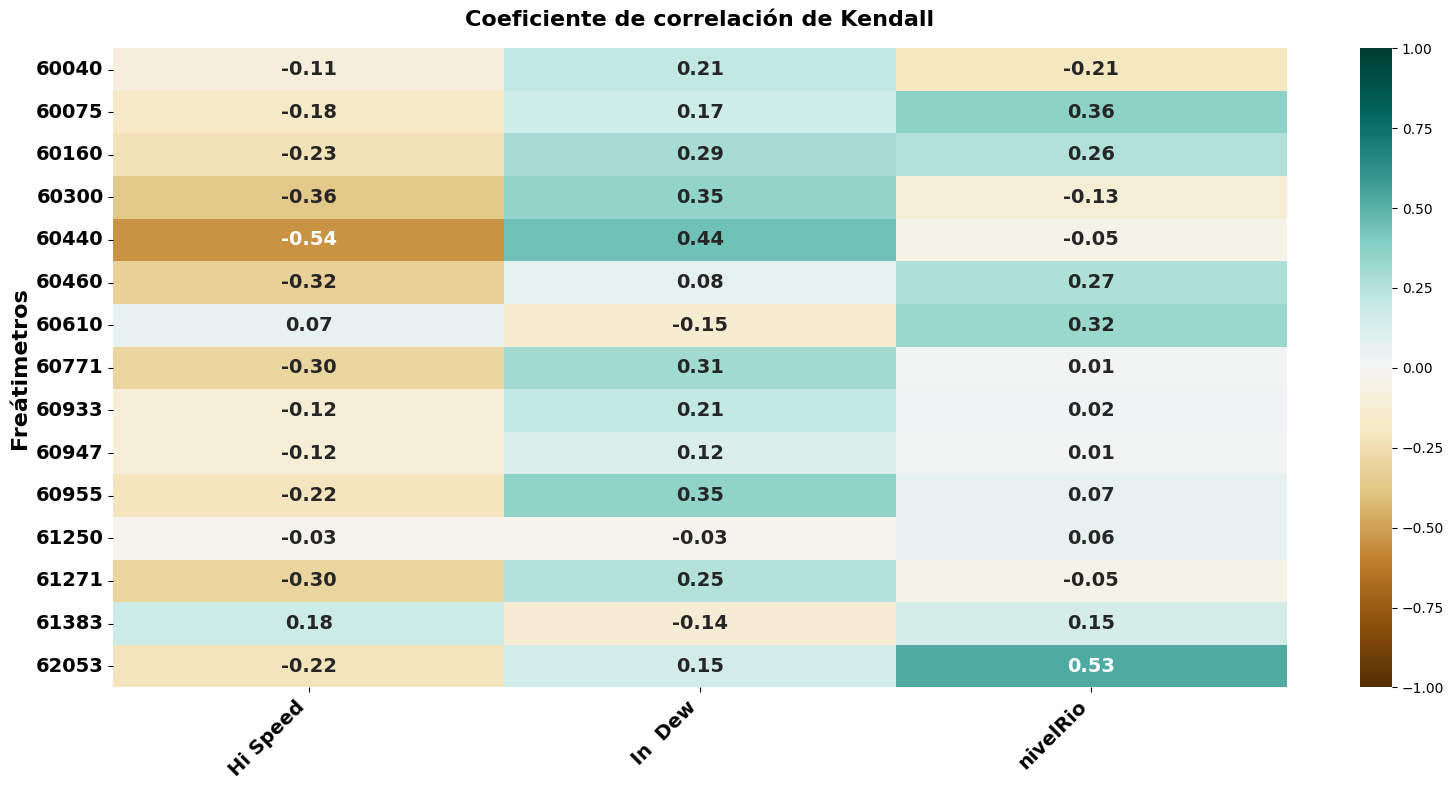

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
aux = datasetMerge[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.20).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 7].index  # Variables que cumplen la condición

# Agregar explícitamente la columna del Nivel del Río si no está incluida
if 'nivelRio' not in variables_to_keep:
    variables_to_keep = variables_to_keep.append(pd.Index(['nivelRio']))

# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


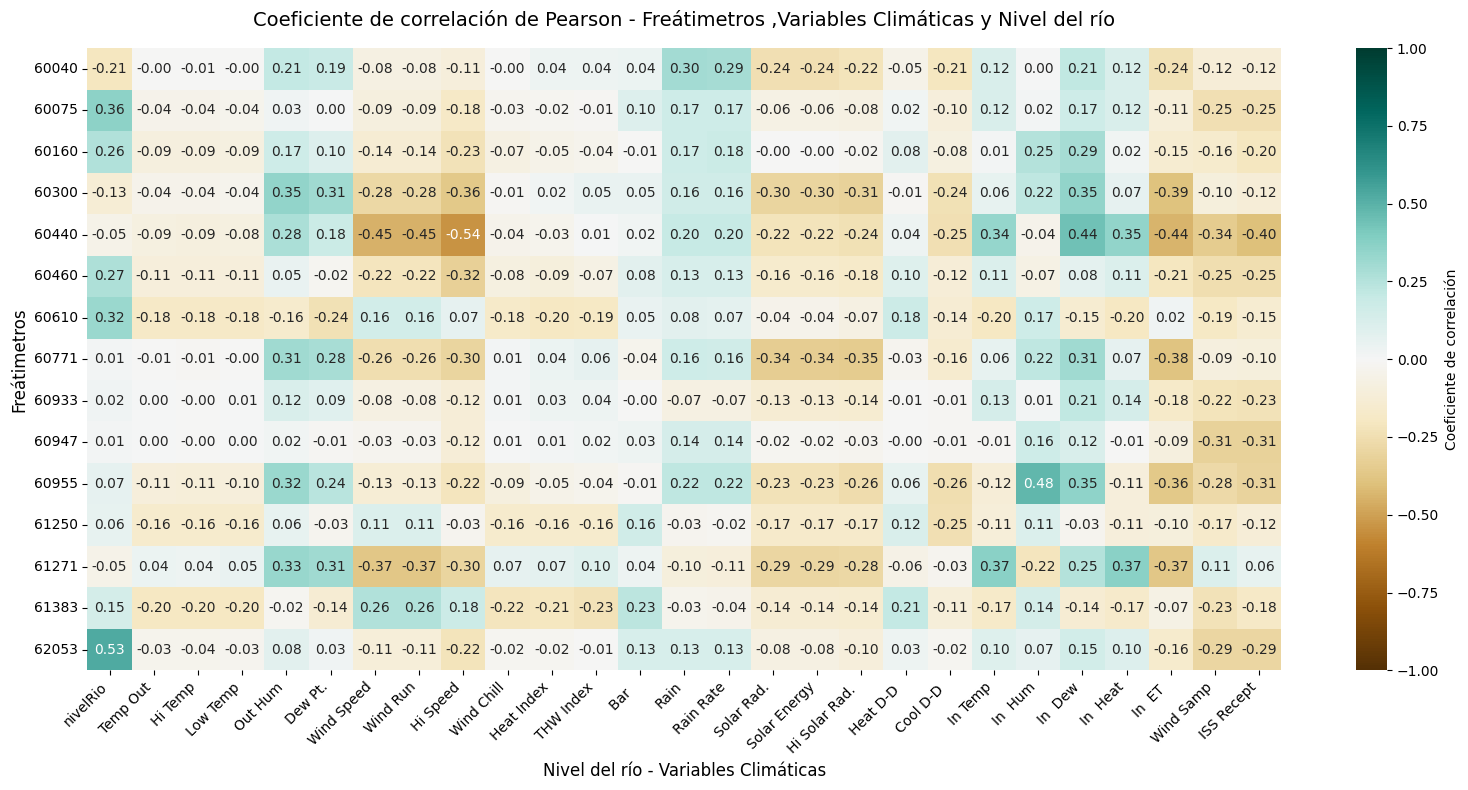

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
aux = datasetMerge[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Crear el mapa de calor
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    aux.loc[freatimetros_labels, climaticas_labels],  # Filtrar filas y columnas específicas
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG', cbar_kws={'label': 'Coeficiente de correlación'}  # fmt=".2f" para dos decimales
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Pearson - Freátimetros ,Variables Climáticas y Nivel del río',
                  fontdict={'fontsize': 14}, pad=16)
heatmap.set_xlabel('Nivel del río - Variables Climáticas', fontsize=12)
heatmap.set_ylabel('Freátimetros', fontsize=12)

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


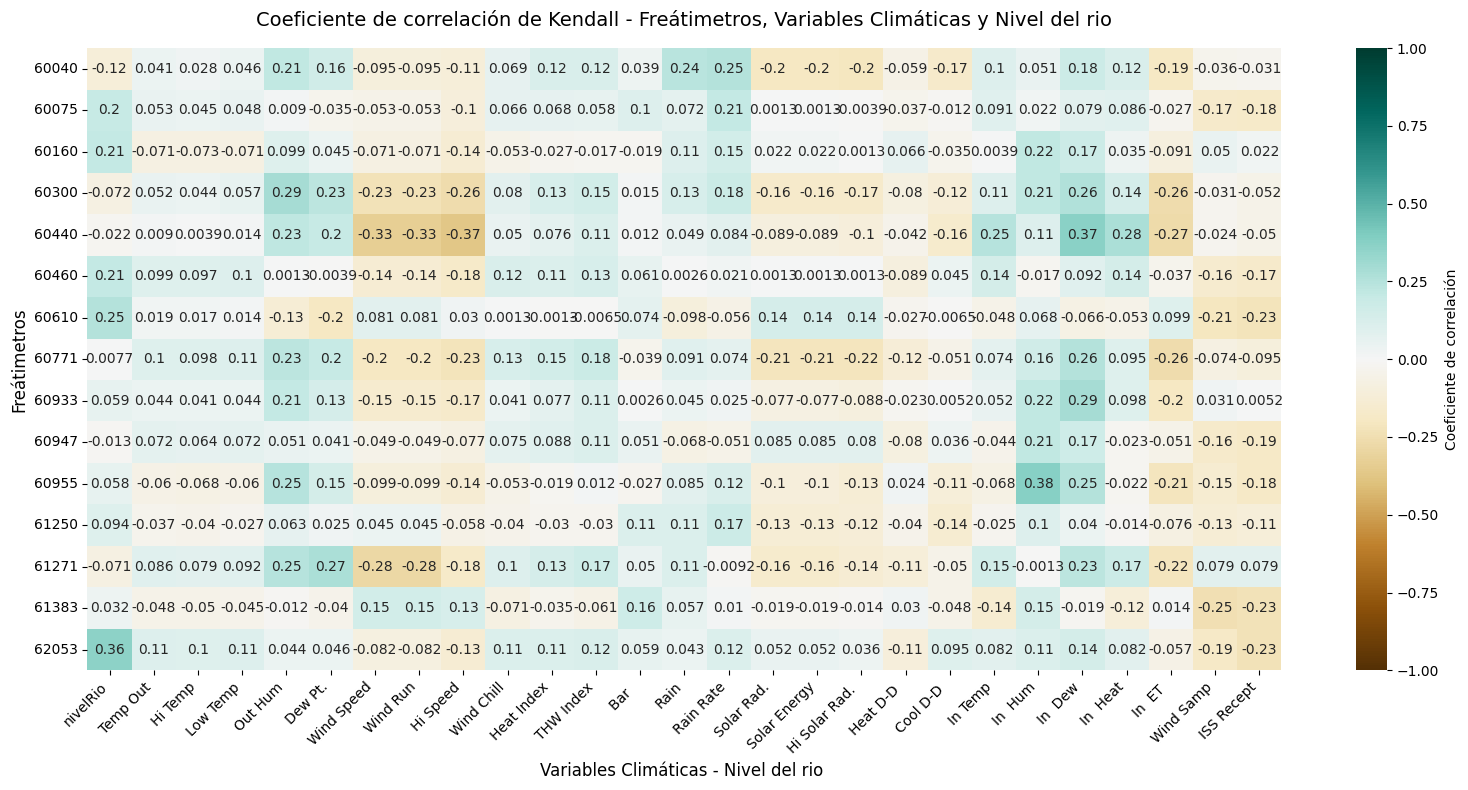

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Calcular la correlación de Kendall solo para los freatímetros y las variables climáticas
aux_s = datasetMerge[columnas_interes].corr(method='kendall').loc[freatimetros_labels, climaticas_labels]

# Crear el mapa de calor
plt.figure(figsize=(16, 8))  # Ajusta el tamaño de la figura según las variables
heatmap = sns.heatmap(
    aux_s,  # Usar la correlación de Kendall filtrada
    vmin=-1, vmax=1, annot=True, cmap='BrBG', cbar_kws={'label': 'Coeficiente de correlación'}
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall - Freátimetros, Variables Climáticas y Nivel del rio', fontdict={'fontsize': 14}, pad=16)
heatmap.set_xlabel('Variables Climáticas - Nivel del rio ', fontsize=12)
heatmap.set_ylabel('Freátimetros', fontsize=12)

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

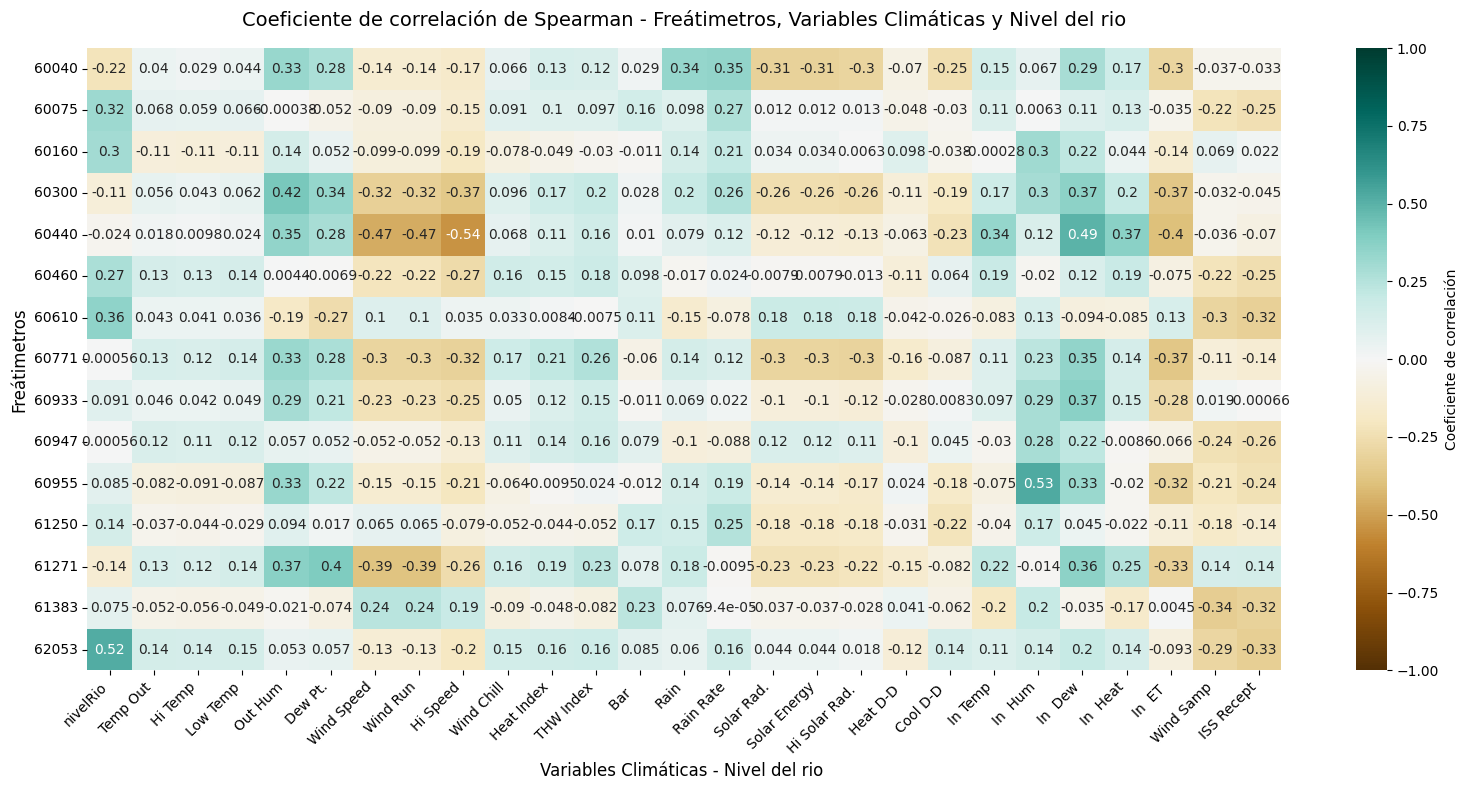

In [ ]:
# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Calcular la correlación de Kendall solo para los freatímetros y las variables climáticas
aux_s = datasetMerge[columnas_interes].corr(method='spearman').loc[freatimetros_labels, climaticas_labels]

# Crear el mapa de calor
plt.figure(figsize=(16, 8))  # Ajusta el tamaño de la figura según las variables
heatmap = sns.heatmap(
    aux_s,  # Usar la correlación de Kendall filtrada
    vmin=-1, vmax=1, annot=True, cmap='BrBG', cbar_kws={'label': 'Coeficiente de correlación'}
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Spearman - Freátimetros, Variables Climáticas y Nivel del rio', fontdict={'fontsize': 14}, pad=16)
heatmap.set_xlabel('Variables Climáticas - Nivel del rio ', fontsize=12)
heatmap.set_ylabel('Freátimetros', fontsize=12)

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/Datos Tesis/datasetRedN.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datasetMerge = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)

In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]
#'In  Dew','Hi Speed'

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    datasetMerge,
    id_vars=['fecha','Hi Speed','Out Hum','In  Dew','nivelRio'],  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['fecha', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['fecha'].dtype)
print(long_data['fecha'].head())
long_data = long_data[
    (long_data['fecha'].dt.month.isin([5, 6, 7, 8])) &
    (long_data['fecha'].dt.year.between(2010, 2019))
]

# Revisar el resultado de la transformación
print(long_data.head())

datetime64[ns]
0     2010-05-01
40    2010-05-01
80    2010-05-01
120   2010-05-01
160   2010-05-01
Name: fecha, dtype: datetime64[ns]
         fecha  Hi Speed    Out Hum   In  Dew    nivelRio freátimetro_id  \
0   2010-05-01  6.933356  67.053704  3.940903  236.280645          60040   
40  2010-05-01  6.933356  67.053704  3.940903  236.280645          60075   
80  2010-05-01  6.933356  67.053704  3.940903  236.280645          60160   
120 2010-05-01  6.933356  67.053704  3.940903  236.280645          60300   
160 2010-05-01  6.933356  67.053704  3.940903  236.280645          60440   

     nivel_freatico  
0           191.942  
40          192.265  
80          194.090  
120         195.082  
160         196.570  


In [ ]:
import pandas as pd
ruta ='/content/drive/MyDrive/Datos Tesis/df_merged_freatimetros_nivelRioNegro_long_caso1.xlsx'#este arechivo esta en formato long listo para entrenar una red neuronal
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
long_data = pd.read_excel(ruta, sheet_name=nombre_pestaña)

In [ ]:
df_merged_freatimetros_nivelRioNegro_long=long_data[['fecha','freátimetro_id','nivelRio', 'nivel_freatico']]
print(df_merged_freatimetros_nivelRioNegro_long)


         fecha  freátimetro_id    nivelRio  nivel_freatico
0   2010-05-01           62053  236.280645      190.485000
1   2010-05-01           60040  236.280645      191.942000
2   2010-05-01           60075  236.280645      192.265000
3   2010-05-01           60160  236.280645      194.090000
4   2010-05-01           60300  236.280645      195.082000
..         ...             ...         ...             ...
775 2022-08-01           60933  235.845806      199.736164
776 2022-08-01           60955  235.845806      201.137000
777 2022-08-01           61250  235.845806      201.463000
778 2022-08-01           61271  235.845806      202.497000
779 2022-08-01           61383  235.845806      203.845000

[780 rows x 4 columns]


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización caso 1**
# ========================================================================
df = df_merged_freatimetros_nivelRioNegro_long.copy()

unique_ids = np.sort(df['freátimetro_id'].unique())  # Orden natural

# 🔹 **Colocar el 62053 en la primera posición y mantener el orden**
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]

# 🔹 **Crear diccionario de mapeo manual**
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}

# 🔹 **Aplicar codificación manual**
df['freátimetro_id_encoded'] = df['freátimetro_id'].map(id_to_encoded)

print(df['freátimetro_id_encoded'])
# 🔹 **Escalar el nivel del río**
scaler_X = StandardScaler()
df['nivelRio_scaled'] = scaler_X.fit_transform(df[['nivelRio']])

# 🔹 **Escalar el nivel freático**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])



# ========================================================================
# 2️⃣ **Generación de Secuencias (Ventana de 4 Meses)**
# ========================================================================
def create_sequences_per_freatimetro(df, window_size=4):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['nivelRio_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values

        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]

            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# ========================================================================
# 3️⃣ **División en Entrenamiento y Prueba POR FREATÍMETRO**
# ========================================================================
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

# 🔹 **Generar secuencias antes de dividir**
X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=4)

# 🔹 **Dividir por cada freatímetro**
for freatimetro_id in np.unique(freatimetros_seq):
    indices_freatimetro = np.where(freatimetros_seq == freatimetro_id)[0]
    train_size = int(len(indices_freatimetro) * 0.8)

    X_train_list.append(X_seq[indices_freatimetro[:train_size]])
    X_test_list.append(X_seq[indices_freatimetro[train_size:]])
    y_train_list.append(y_seq[indices_freatimetro[:train_size]])
    y_test_list.append(y_seq[indices_freatimetro[train_size:]])
    fechas_train_list.append(fechas_seq[indices_freatimetro[:train_size]])
    fechas_test_list.append(fechas_seq[indices_freatimetro[train_size:]])
    freatimetros_train_list.append(freatimetros_seq[indices_freatimetro[:train_size]])
    freatimetros_test_list.append(freatimetros_seq[indices_freatimetro[train_size:]])

# 🔹 **Concatenar los resultados finales**
X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)

# ========================================================================
# ✅ **Verificación de Datos**
# ========================================================================
print(f"🔹 X_train shape: {X_train.shape}")  # (n_muestras, 4, 2)
print(f"🔹 y_train shape: {y_train.shape}")  # (n_muestras,)
print(f"🔹 Cantidad de freatímetros únicos en test: {len(set(freatimetros_test))}")
print(f"🔹 Freatímetros en test: {set(freatimetros_test)}")
print(f"🔹 Fechas en test (últimas 5 muestras): {fechas_test[-5:]}")





0       0
1       1
2       2
3       3
4       4
       ..
775     9
776    11
777    12
778    13
779    14
Name: freátimetro_id_encoded, Length: 780, dtype: int64
🔹 X_train shape: (570, 4, 2)
🔹 y_train shape: (570,)
🔹 Cantidad de freatímetros únicos en test: 15
🔹 Freatímetros en test: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}
🔹 Fechas en test (últimas 5 muestras): ['2021-08-01T00:00:00.000000000' '2022-05-01T00:00:00.000000000'
 '2022-06-01T00:00:00.000000000' '2022-07-01T00:00:00.000000000'
 '2022-08-01T00:00:00.000000000']


In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(128, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='linear'))

# 🔹 **Compilar el Modelo**
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stop])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.7851 - mae: 0.7081 - val_loss: 0.2769 - val_mae: 0.5192
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.4473 - mae: 0.4981 - val_loss: 0.3413 - val_mae: 0.5632
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2598 - mae: 0.3939 - val_loss: 0.1560 - val_mae: 0.3806
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2037 - mae: 0.3393 - val_loss: 0.0091 - val_mae: 0.0766
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1014 - mae: 0.2448 - val_loss: 0.0564 - val_mae: 0.2232
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0600 - mae: 0.1988 - val_loss: 0.1354 - val_mae: 0.3581
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0594 - mae: 0.1957 - val_loss: 0.1974 - val_mae: 0.4362
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0484 - mae: 0.1741 - val_loss: 0.1979 - val_mae: 0.4371
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - lo

In [ ]:
import pandas as pd

# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
encoded_to_id = {v: k for k, v in id_to_encoded.items()}
freatimetros_test_original=  [encoded_to_id[id_] for id_ in freatimetros_test]

# 🔹 **Crear un DataFrame con los resultados**
df_resultados = pd.DataFrame({
    "Fecha": fechas_test,
    "Freátimetro ID": freatimetros_test_original,
    "Predicción": y_pred.flatten(),
    "Real": y_test_descaled.flatten()
})

# 🔹 **Obtener la última predicción por cada freatímetro**
df_resultados = df_resultados.sort_values(by=["Freátimetro ID", "Fecha"])  # Ordenar correctamente
df_ultimas_predicciones = df_resultados.groupby("Freátimetro ID").last().reset_index()

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
print(df_ultimas_predicciones)

# 🔹 **Opcional: Guardar en Excel para análisis posterior**
df_ultimas_predicciones.to_excel("predicciones_ventana4.xlsx", index=False)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1256 - mae: 0.2510
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step

Loss (MSE): 0.0904, MAE: 0.2023
📌 Última predicción de cada freatímetro:
    Freátimetro ID      Fecha  Predicción        Real
0            60040 2022-08-01  192.820969  191.172000
1            60075 2022-08-01  192.790390  191.515000
2            60160 2022-08-01  193.333099  192.980000
3            60300 2022-08-01  194.237320  194.022000
4            60440 2022-08-01  195.341354  195.900000
5            60460 2022-08-01  196.523300  195.628000
6            60610 2022-08-01  197.695084  196.460000
7            60771 2022-08-01  198.798996  198.890000
8            60933 2022-08-01  199.802994  199.736164
9            60947 2022-08-01  200.694519  197.685000
10           60955 2022-08-01  201.474106  201.137000
11           61250 2022-08-01  202.149734  201.463000
12           61271 2022-08-01  202.732834  202.497000
13           61383 2022-08-01  203.235641  203.845000
14         

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Real", linestyle="-")
plt.plot(y_pred, label="Predicción", linestyle="dashed")
plt.xlabel("Muestras de Prueba")
plt.ylabel("Nivel Freático (msnm)")
plt.title("Comparación entre Predicción y Valores Reales")
plt.legend()
plt.grid()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


ValueError: Found array with dim 3. None expected <= 2.

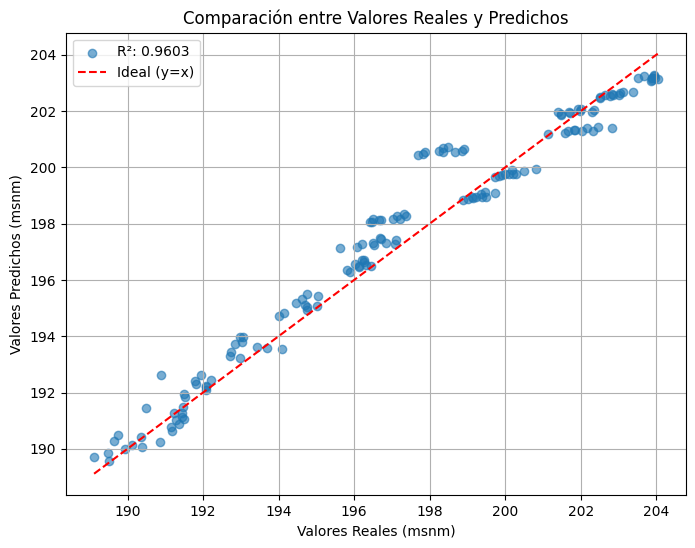

In [ ]:
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test_descaled, y_pred))

print(f"📉 RMSE: {rmse:.4f}")


📉 RMSE: 0.8793


In [ ]:
import numpy as np
import pandas as pd
import joblib
from dateutil.relativedelta import relativedelta

def predecir_nivel_freatico(model, df, freatimetro_id, scaler_X, scaler_y, id_to_encoded):
    """
    Predice el nivel freático para un freatímetro específico basado en los últimos 4 meses del período sin riego.

    Parámetros:
    - model: Modelo LSTM entrenado.
    - df: DataFrame con los datos históricos.
    - freatimetro_id: ID del freatímetro que se desea predecir.
    - scaler_X: Escalador para los datos de entrada.
    - scaler_y: Escalador para los valores de salida (nivel freático).
    - id_to_encoded: Diccionario con el mapeo manual de freatímetros.

    Retorna:
    - Fecha de la predicción y nivel freático estimado (msnm).
    """

    # 🔹 **1. Verificar si el freatímetro está en el mapeo**
    if freatimetro_id not in id_to_encoded:
        print(f"❌ Error: El freatímetro {freatimetro_id} no está en el mapeo de codificación.")
        return None

    # 🔹 **2. Filtrar datos del freatímetro**
    df_freatimetro = df[df["freátimetro_id"] == freatimetro_id].copy()

    # 🔹 **3. Seleccionar solo los meses del período sin riego (mayo-agosto)**
    df_freatimetro["mes"] = df_freatimetro["fecha"].dt.month
    df_freatimetro = df_freatimetro[df_freatimetro["mes"].isin([5, 6, 7, 8])]

    # 🔹 **4. Verificar si hay suficientes datos (4 meses)**
    if len(df_freatimetro) < 4:
        print(f"❌ No hay suficientes datos para el freatímetro {freatimetro_id} (se necesitan al menos 4 meses de datos del período sin riego).")
        return None

    # 🔹 **5. Ordenar por fecha y seleccionar los últimos 4 meses**
    df_freatimetro = df_freatimetro.sort_values("fecha")
    ultimo_periodo = df_freatimetro[["fecha", "nivelRio"]].iloc[-4:].copy()

    # 🔹 **6. Obtener la última fecha y calcular la fecha de predicción**
    ultima_fecha = ultimo_periodo["fecha"].iloc[-1]
    fecha_prediccion = ultima_fecha + relativedelta(years=1, months=-3)  # Predecimos para mayo del año siguiente

    print(f"🔹 Últimos 4 registros seleccionados para el freatímetro {freatimetro_id}:")
    print(ultimo_periodo)

    # 🔹 **7. Escalar el nivel del río**
    nivelRio_scaled = scaler_X.transform(ultimo_periodo[["nivelRio"]])

    # 🔹 **8. Obtener el código del freatímetro**
    freatimetro_encoded = id_to_encoded[freatimetro_id]
    freatimetro_encoded_array = np.full((4, 1), freatimetro_encoded)

    # 🔹 **9. Combinar nivel del río escalado con ID codificado**
    input_data = np.hstack((nivelRio_scaled, freatimetro_encoded_array))

    # 🔹 **10. Redimensionar para el modelo LSTM**
    X_pred = np.array([input_data])  # Forma correcta: (1, 4, 2)

    # 🔹 **11. Realizar la predicción**
    y_pred_scaled = model.predict(X_pred)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)[0][0]

    # 🔹 **12. Mostrar resultado**
    print(f"\n📌 Predicción del Nivel Freático para el Freatímetro {freatimetro_id}")
    print(f"📅 Fecha Predicción: {fecha_prediccion.strftime('%Y-%m')}, Nivel Freático: {y_pred_real:.2f} msnm")

    return fecha_prediccion, y_pred_real

# 🔹 **Crear diccionario de mapeo manual**
unique_ids = np.sort(df["freátimetro_id"].unique())  # Obtener IDs únicos
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]  # Asignar 62053 como 0
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}  # Mapeo manual

# 🔹 **Ejemplo: Predecir el nivel freático del freatímetro 60040 para el período sin riego 2023**
predecir_nivel_freatico(
    model=model,
    df=df_merged_freatimetros_nivelRioNegro_long,
    freatimetro_id=60040,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    id_to_encoded=id_to_encoded  # Pasamos el diccionario de mapeo
)


🔹 Últimos 4 registros seleccionados para el freatímetro 62053:
         fecha    nivelRio
720 2022-05-01  235.807097
735 2022-06-01  235.654000
750 2022-07-01  235.654194
765 2022-08-01  235.845806
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step

📌 Predicción del Nivel Freático para el Freatímetro 62053
📅 Fecha Predicción: 2023-05, Nivel Freático: 190.53 msnm


(Timestamp('2023-05-01 00:00:00'), 190.52704)

In [ ]:
import numpy as np
import pandas as pd
import joblib
from dateutil.relativedelta import relativedelta

def predecir_todos_freatimetros(model, df, scaler_X, scaler_y, id_to_encoded):
    """
    Predice el nivel freático para todos los freatímetros en el conjunto de datos.

    Parámetros:
    - model: Modelo LSTM entrenado.
    - df: DataFrame con los datos históricos.
    - scaler_X: Escalador para los datos de entrada.
    - scaler_y: Escalador para los valores de salida (nivel freático).
    - id_to_encoded: Diccionario con el mapeo manual de freatímetros.

    Retorna:
    - DataFrame con las predicciones de cada freatímetro.
    """

    predicciones = []

    for freatimetro_id in id_to_encoded.keys():
        # 🔹 **1. Filtrar datos del freatímetro**
        df_freatimetro = df[df["freátimetro_id"] == freatimetro_id].copy()
        df_freatimetro["mes"] = df_freatimetro["fecha"].dt.month

        # 🔹 **2. Filtrar solo el período sin riego (mayo-agosto)**
        df_freatimetro = df_freatimetro[df_freatimetro["mes"].isin([5, 6, 7, 8])]

        # 🔹 **3. Verificar si hay suficientes datos (4 meses)**
        if len(df_freatimetro) < 4:
            print(f"❌ No hay suficientes datos para el freatímetro {freatimetro_id} (se necesitan al menos 4 meses).")
            continue

        # 🔹 **4. Seleccionar los últimos 4 meses**
        df_freatimetro = df_freatimetro.sort_values("fecha")
        ultimo_periodo = df_freatimetro[["fecha", "nivelRio"]].iloc[-4:].copy()

        # 🔹 **5. Calcular la fecha de predicción (mayo del año siguiente)**
        ultima_fecha = ultimo_periodo["fecha"].iloc[-1]
        fecha_prediccion = ultima_fecha + relativedelta(years=1, months=-3)

        # 🔹 **6. Escalar el nivel del río**
        nivelRio_scaled = scaler_X.transform(ultimo_periodo[["nivelRio"]])

        # 🔹 **7. Obtener el código del freatímetro**
        freatimetro_encoded = id_to_encoded[freatimetro_id]
        freatimetro_encoded_array = np.full((4, 1), freatimetro_encoded)

        # 🔹 **8. Preparar datos de entrada**
        input_data = np.hstack((nivelRio_scaled, freatimetro_encoded_array))
        X_pred = np.array([input_data])  # Ajustar forma para LSTM

        # 🔹 **9. Realizar la predicción**
        y_pred_scaled = model.predict(X_pred)
        y_pred_real = scaler_y.inverse_transform(y_pred_scaled)[0][0]

        # 🔹 **10. Almacenar resultados**
        predicciones.append({
            "Freatímetro_ID": freatimetro_id,
            "Fecha_Predicción": fecha_prediccion.strftime('%Y-%m'),
            "Nivel_Freático_Predicho (msnm)": round(y_pred_real, 2)
        })

    # 🔹 **11. Convertir resultados en DataFrame ordenado**
    df_predicciones = pd.DataFrame(predicciones).sort_values("Freatímetro_ID").reset_index(drop=True)

    return df_predicciones

# 🔹 **Ejecutar predicción para todos los freatímetros**
df_resultados = predecir_todos_freatimetros(
    model=model,
    df=df_merged_freatimetros_nivelRioNegro_long,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    id_to_encoded=id_to_encoded
)

# 🔹 **Mostrar tabla con resultados**
print("\nTabla de Predicciones:")
print(df_resultados)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Tabla de Predicciones:
    Freatímetro_ID Fecha_Predicción  Nivel_Freático_Predicho (msnm)
0            60040          2023-05                      191.470001
1            60075          2023-05                      192.589996
2            60160          2023-05                      193.839996
3            60300          2023-05                      195.229996
4            60440          2023-05                      196.55000

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Función para realizar predicciones con el modelo entrenado
def realizar_prediccion_simple(nivelRio, frea_id):
    # Crear el arreglo de entrada basado en los valores ingresados
    input_data = np.array([[nivelRio]])

    # Escalar la variable numérica (nivel del río)
    input_data_scaled = scaler_X.transform(input_data)

    # Codificar el ID del freátimetro
    frea_id_encoded = label_encoder.transform([frea_id])  # Convertir el ID a formato codificado
    input_data_combined = np.hstack((input_data_scaled, np.array(frea_id_encoded).reshape(-1, 1)))

    # Redimensionar para que sea compatible con LSTM
    input_data_combined = input_data_combined.reshape((1, 1, input_data_combined.shape[1]))

    # Realizar la predicción
    prediction_scaled = model.predict(input_data_combined)

    # Desescalar el resultado para obtener la predicción en unidades reales
    prediction = scaler_y.inverse_transform(prediction_scaled)
    return prediction[0][0]

# Crear widgets para el formulario
nivelRio_widget = widgets.FloatText(description="Nivel del Río:")
frea_id_widget = widgets.Dropdown(
    options=label_encoder.classes_,  # Mostrar las clases codificadas
    description="Freátimetro:"
)
button = widgets.Button(description="Predecir")

# Función para manejar la interacción
def on_button_click_simple(b):
    nivelRio = nivelRio_widget.value
    frea_id = frea_id_widget.value

    # Realizar la predicción
    resultado = realizar_prediccion_simple(nivelRio, frea_id)
    print(f"Predicción del Nivel Freático: {resultado:.2f} metros")

button.on_click(on_button_click_simple)

# Mostrar el formulario
display(widgets.VBox([
    nivelRio_widget,
    frea_id_widget,
    button
]))


In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Función para realizar predicciones con el modelo entrenado
def realizar_prediccion(hi_speed, out_hum, in_dew, frea_id):
    # Crear el arreglo de entrada basado en los valores ingresados
    input_data = np.array([[hi_speed, out_hum, in_dew]])

    # Escalar las variables numéricas
    input_data_scaled = scaler_X.transform(input_data)

    # Codificar el ID del freátimetro
    frea_id_encoded = label_encoder.transform([frea_id])  # Asegurarse de que el ID esté en el formato codificado
    input_data_combined = np.hstack((input_data_scaled, np.array(frea_id_encoded).reshape(-1, 1)))

    # Redimensionar para que sea compatible con LSTM
    input_data_combined = input_data_combined.reshape((1, 1, input_data_combined.shape[1]))

    # Realizar la predicción
    prediction_scaled = model.predict(input_data_combined)

    # Desescalar el resultado para obtener la predicción en unidades reales
    prediction = scaler_y.inverse_transform(prediction_scaled)
    return prediction[0][0]

# Crear widgets para el formulario
hi_speed_widget = widgets.FloatText(description="Hi Speed:")
out_hum_widget = widgets.FloatText(description="Out Hum:")
in_dew_widget = widgets.FloatText(description="In Dew:")
frea_id_widget = widgets.Dropdown(
    options=label_encoder.classes_,  # Mostrar las clases codificadas
    description="Freátimetro:"
)
button = widgets.Button(description="Predecir")

# Función para manejar la interacción
def on_button_click(b):
    hi_speed = hi_speed_widget.value
    out_hum = out_hum_widget.value
    in_dew = in_dew_widget.value
    frea_id = frea_id_widget.value

    # Realizar la predicción
    resultado = realizar_prediccion(hi_speed, out_hum, in_dew, frea_id)
    print(f"Predicción del Nivel Freático:")
    print(f"IdFreatimetro {frea_id} Prediccion {resultado:.2f} metros")
button.on_click(on_button_click)

# Mostrar el formulario
display(widgets.VBox([
    hi_speed_widget, out_hum_widget, in_dew_widget,
    frea_id_widget, button
]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicción del Nivel Freático:
IdFreatimetro 60040 Prediccion 191.64 metros
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicción del Nivel Freático:
IdFreatimetro 60300 Prediccion 195.22 metros
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicción del Nivel Freático:
IdFreatimetro 60933 Prediccion 199.71 metros


In [ ]:
print(long_data.head())

         fecha  Hi Speed   Wind Samp   In  Dew  ISS Recept  freátimetro_id  \
0   2010-05-01  6.933356  219.804167  3.940903   96.330856               0   
40  2010-05-01  6.933356  219.804167  3.940903   96.330856               1   
80  2010-05-01  6.933356  219.804167  3.940903   96.330856               2   
120 2010-05-01  6.933356  219.804167  3.940903   96.330856               3   
160 2010-05-01  6.933356  219.804167  3.940903   96.330856               4   

     nivel_freatico  
0           191.942  
40          192.265  
80          194.090  
120         195.082  
160         196.570  


In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Función para realizar predicciones con el modelo entrenado
def realizar_prediccion(nivelRio, temp_out, rain, out_hum, in_dew, rain_rate, frea_id):
    # Crear el arreglo de entrada basado en los valores ingresados
    input_data = np.array([[nivelRio, temp_out, rain, out_hum, in_dew, rain_rate]])

    # Escalar las variables numéricas
    input_data_scaled = scaler_X.transform(input_data)

    # Combinar con el ID del freátimetro
    frea_id_encoded = label_encoder.transform([frea_id])  # Asegurarse de que el ID esté en el formato codificado
    input_data_combined = np.hstack((input_data_scaled, np.array(frea_id_encoded).reshape(-1, 1)))

    # Redimensionar para que sea compatible con LSTM
    input_data_combined = input_data_combined.reshape((1, 1, input_data_combined.shape[1]))

    # Realizar la predicción
    prediction_scaled = model.predict(input_data_combined)

    # Desescalar el resultado para obtener la predicción en unidades reales
    prediction = scaler_y.inverse_transform(prediction_scaled)
    return prediction[0][0]

# Crear widgets para el formulario
nivelRio_widget = widgets.FloatText(description="Nivel del Río:")
temp_out_widget = widgets.FloatText(description="Temp. Exterior:")
rain_widget = widgets.FloatText(description="Lluvia:")
out_hum_widget = widgets.FloatText(description="Humedad Ext.:")
in_dew_widget = widgets.FloatText(description="Punto de Rocío:")
rain_rate_widget = widgets.FloatText(description="Tasa de Lluvia:")
frea_id_widget = widgets.Dropdown(
    options=label_encoder.classes_,  # Mostrar las clases codificadas
    description="Freátimetro:"
)
button = widgets.Button(description="Predecir")

# Función para manejar la interacción
def on_button_click(b):
    nivelRio = nivelRio_widget.value
    temp_out = temp_out_widget.value
    rain = rain_widget.value
    out_hum = out_hum_widget.value
    in_dew = in_dew_widget.value
    rain_rate = rain_rate_widget.value
    frea_id = frea_id_widget.value

    # Realizar la predicción
    resultado = realizar_prediccion(nivelRio, temp_out, rain, out_hum, in_dew, rain_rate, frea_id)
    print(f"Predicción del Nivel Freático: {resultado:.2f} metros")

button.on_click(on_button_click)

# Mostrar el formulario
display(widgets.VBox([
    nivelRio_widget, temp_out_widget, rain_widget,
    out_hum_widget, in_dew_widget, rain_rate_widget,
    frea_id_widget, button
]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicción del Nivel Freático: 191.93 metros


In [ ]:
# Desescalar las predicciones y los valores reales si aún no lo has hecho
y_pred_desescalado = scaler_y.inverse_transform(y_pred_scaled)
y_test_desescalado = scaler_y.inverse_transform(y_test)

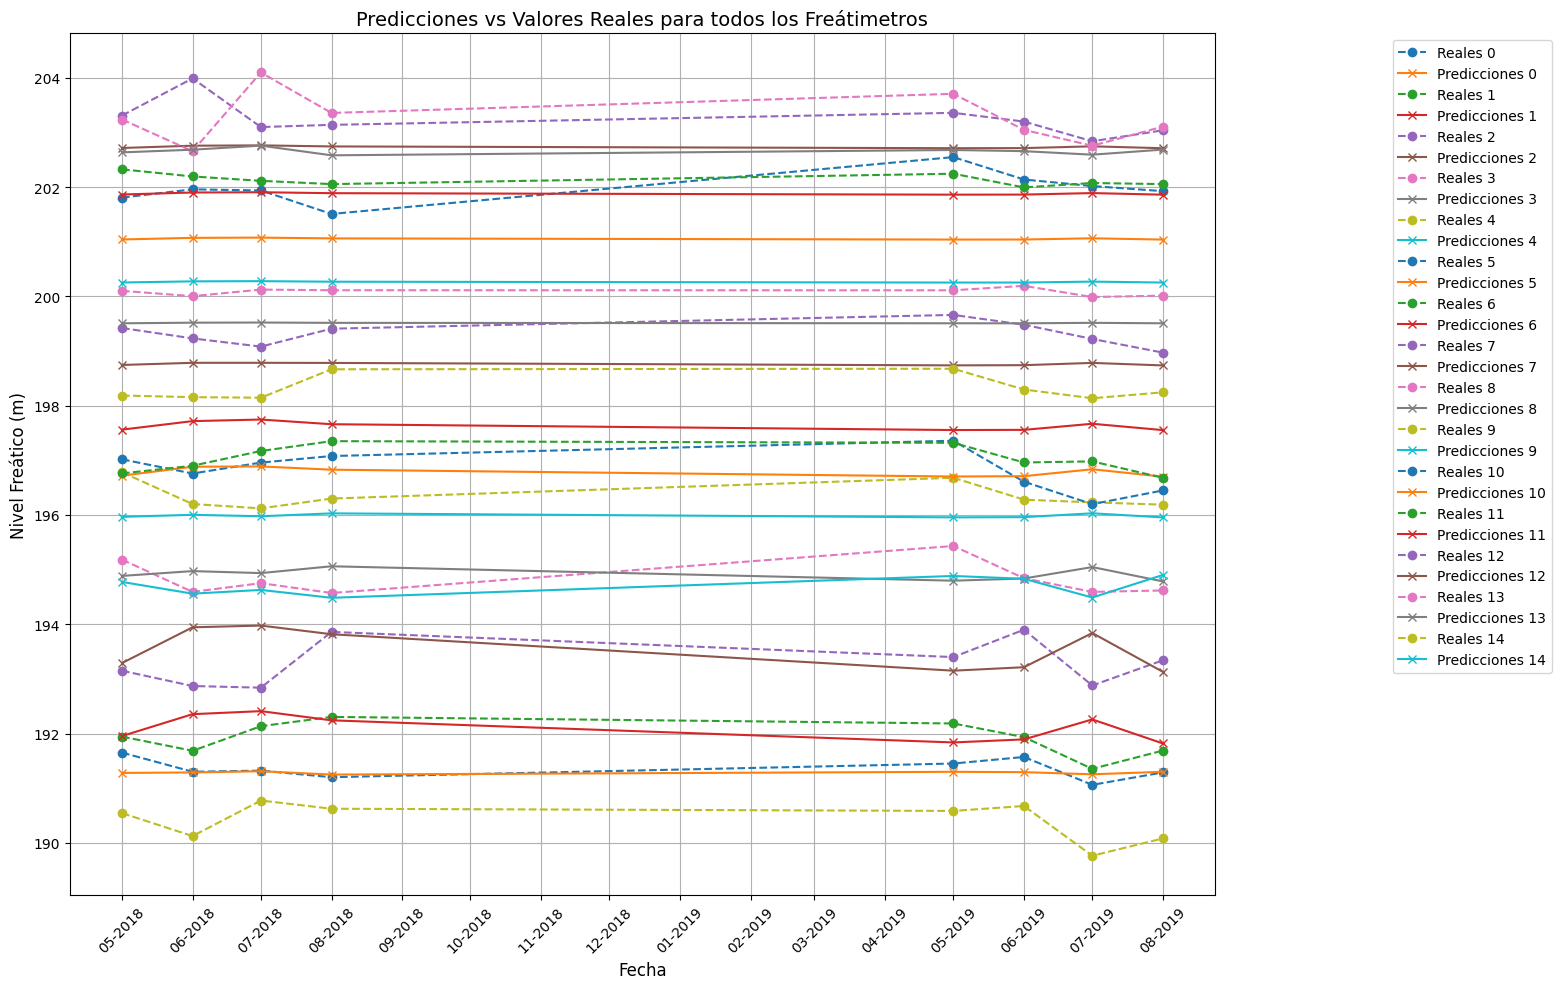

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Obtener los identificadores únicos de los freátimetros del conjunto de prueba
unique_freatimetros = np.unique(X_test[:, 0, -1])  # Asume que la columna freátimetro_id está en la última posición de la dimensión 2

# Crear el gráfico
plt.figure(figsize=(16, 10))

# Iterar sobre cada freátimetro para graficar
for id_freatimetro in unique_freatimetros:
    # Filtrar datos del conjunto de prueba para este freátimetro
    mask = (X_test[:, 0, -1] == id_freatimetro)  # Verificar la columna de freátimetro_id
    y_test_filtrado = y_test_desescalado[mask]
    y_pred_filtrado = y_pred_desescalado[mask]
    fechas_test = long_data['fecha'][-len(y_test_desescalado):][mask]  # Filtrar fechas para este freátimetro

    # Graficar valores reales y predicciones
    plt.plot(fechas_test, y_test_filtrado, label=f"Reales {int(id_freatimetro)}", marker='o', linestyle='--')
    plt.plot(fechas_test, y_pred_filtrado, label=f"Predicciones {int(id_freatimetro)}", marker='x')

# Configurar el gráfico
plt.title("Predicciones vs Valores Reales para todos los Freátimetros", fontsize=14)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Nivel Freático (m)", fontsize=12)

# Formatear las etiquetas del eje X como "mes/año"
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Mostrar etiquetas mensuales

plt.xticks(rotation=45)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))  # Mover la leyenda para que no se superponga
plt.grid(True)
plt.tight_layout()
plt.show()


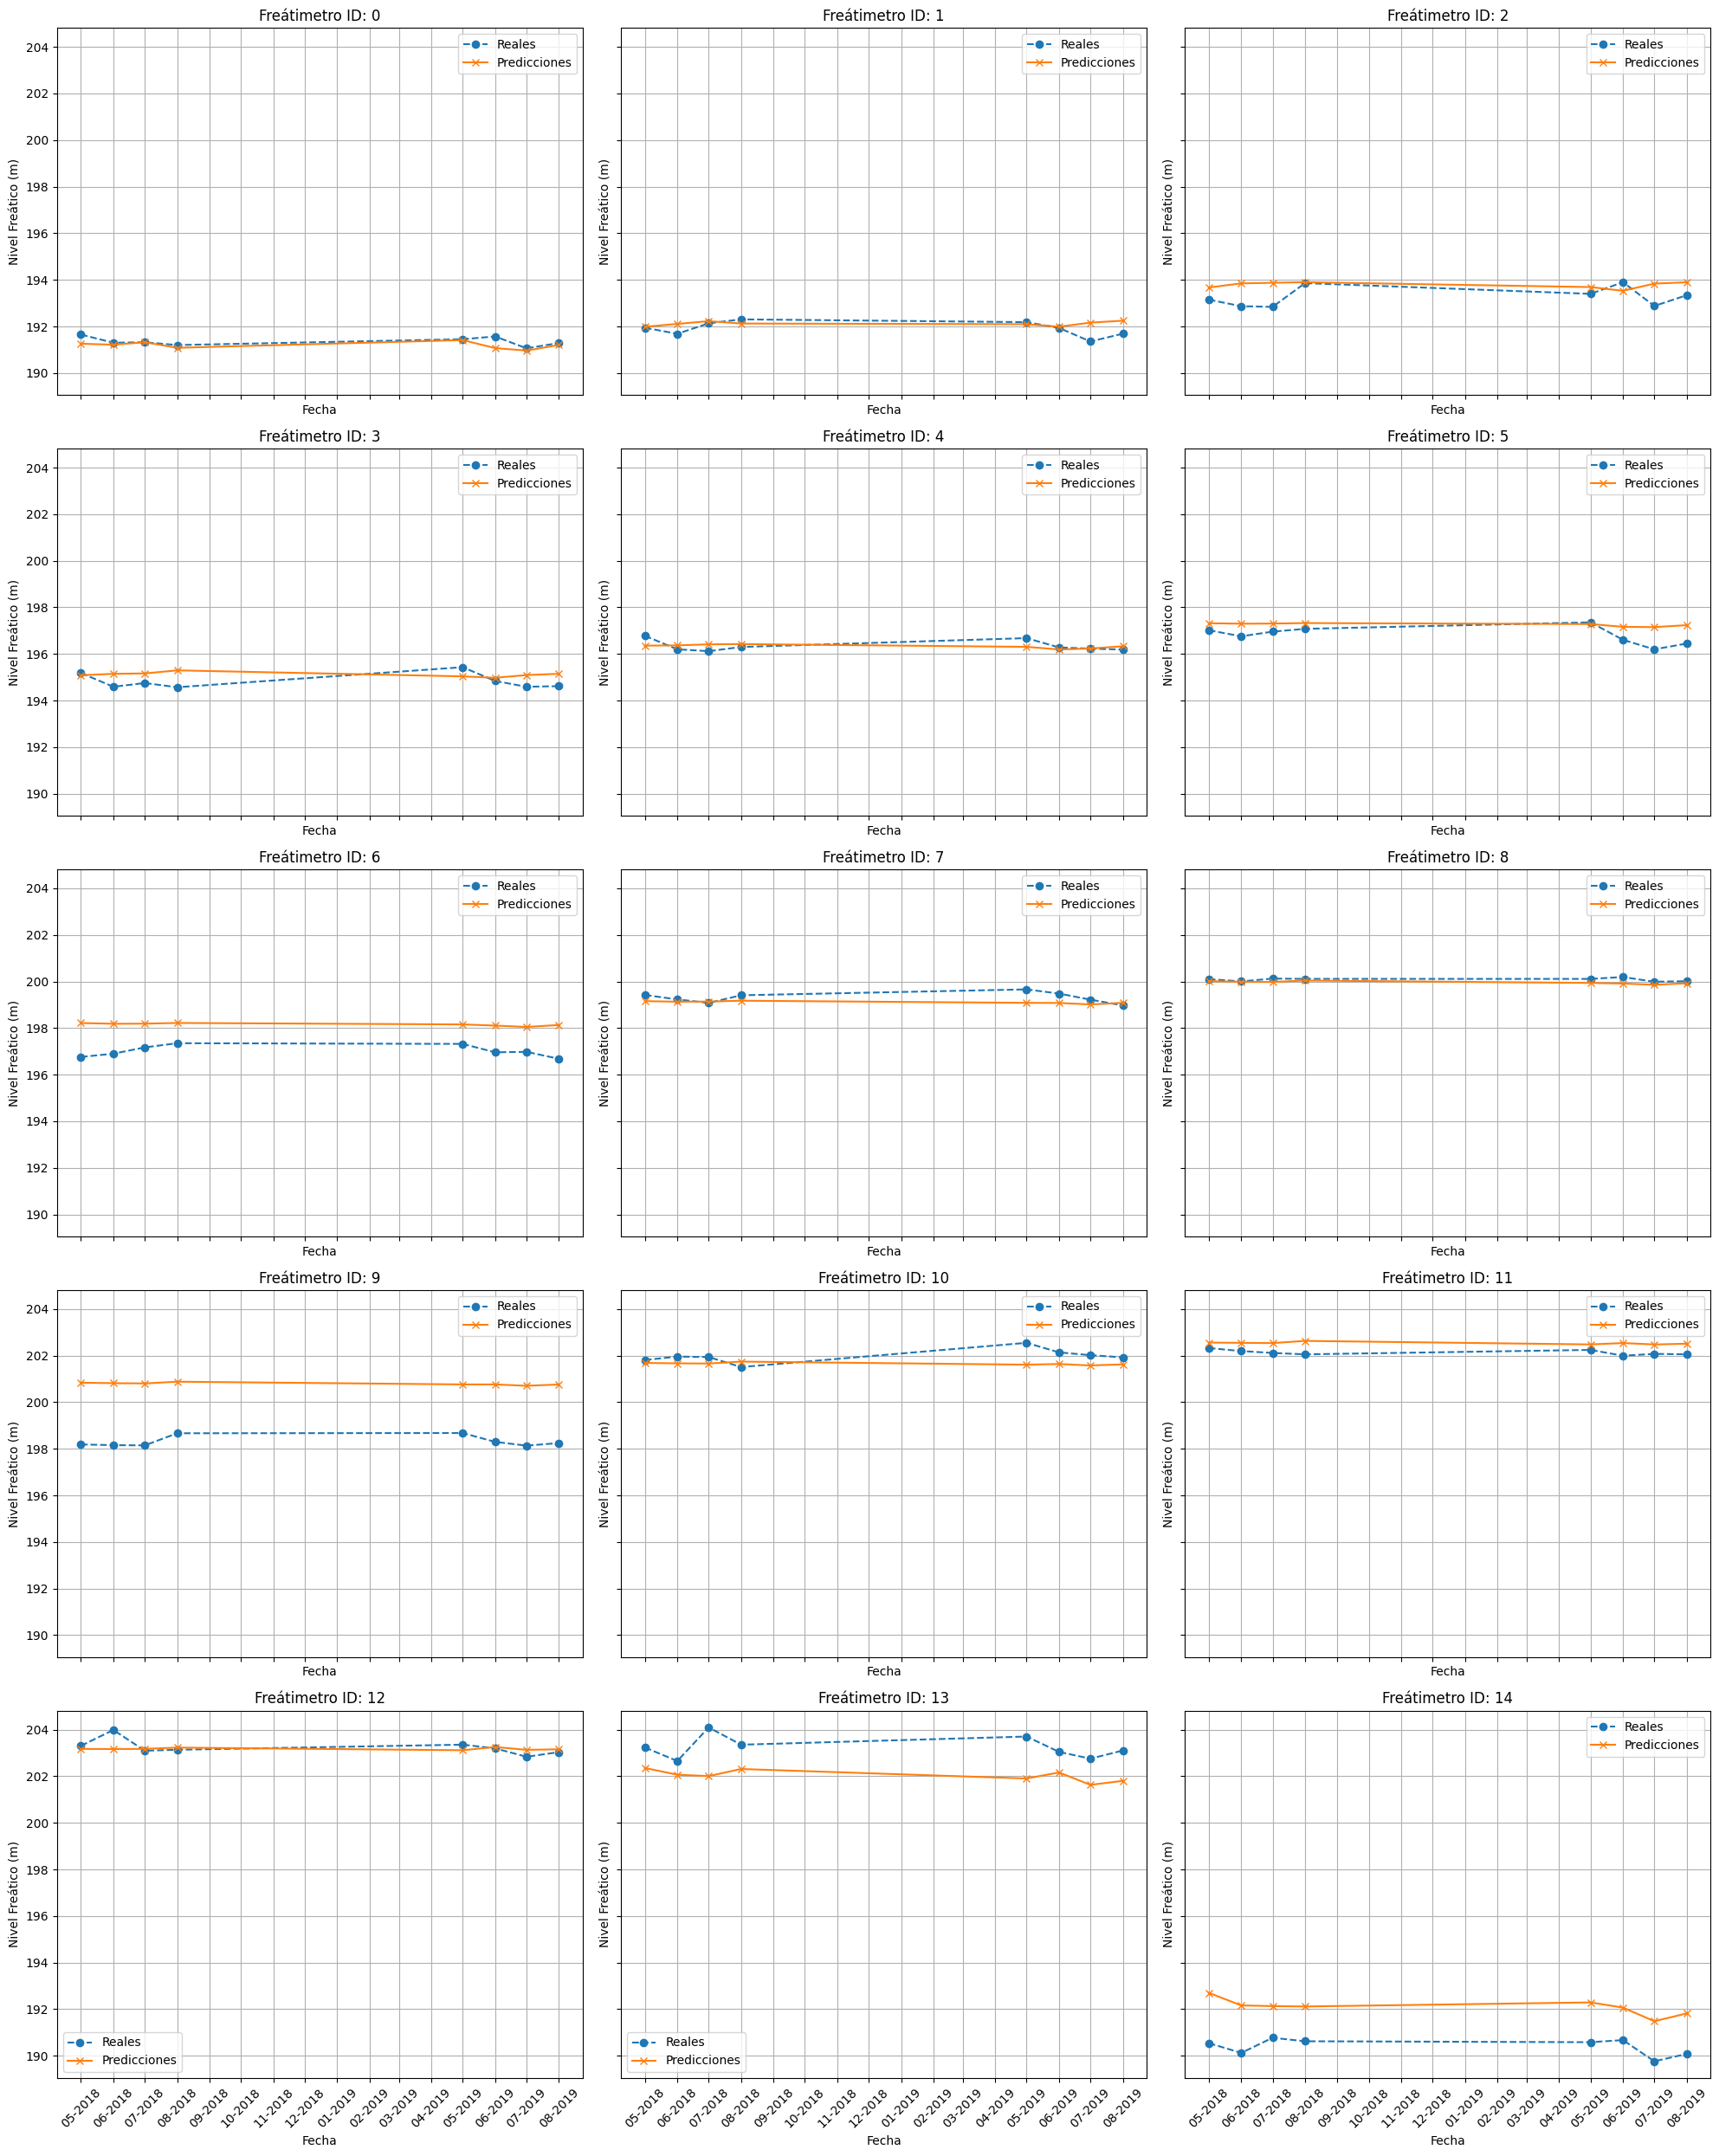

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Obtener los identificadores únicos de los freátimetros del conjunto de prueba
unique_freatimetros = np.unique(X_test[:, 0, -1])  # Asegúrate de que esta es la columna con los IDs de los freátimetros

# Definir el número de filas y columnas para el mosaico
num_freatimetros = len(unique_freatimetros)
rows = int(np.ceil(num_freatimetros / 3))  # Ajustar para que sean 3 columnas
cols = 3

# Crear los subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), sharex=True, sharey=True)

# Aplanar los ejes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre los freátimetros y graficar cada uno en un subplot
for idx, id_freatimetro in enumerate(unique_freatimetros):
    # Filtrar datos del conjunto de prueba para este freátimetro
    mask = (X_test[:, 0, -1] == id_freatimetro)  # Verificar la columna de freátimetro_id
    y_test_filtrado = y_test_desescalado[mask]
    y_pred_filtrado = y_pred_desescalado[mask]
    fechas_test = long_data['fecha'][-len(y_test_desescalado):][mask]  # Filtrar fechas para este freátimetro

    # Graficar en el subplot correspondiente
    ax = axes[idx]
    ax.plot(fechas_test, y_test_filtrado, label="Reales", marker='o', linestyle='--')
    ax.plot(fechas_test, y_pred_filtrado, label="Predicciones", marker='x')
    ax.set_title(f"Freátimetro ID: {int(id_freatimetro)}", fontsize=12)  # Mostrar el ID en el título
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nivel Freático (m)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Mostrar etiquetas mensuales
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.legend()

# Ajustar diseño para evitar superposiciones
plt.tight_layout()

# Eliminar subplots vacíos si el número de freátimetros no llena la cuadrícula
for ax in axes[num_freatimetros:]:
    fig.delaxes(ax)

plt.show()


[[[-1.57806653  0.85504319  1.12761666  0.        ]]

 [[-1.57806653  0.85504319  1.12761666  1.        ]]

 [[-1.57806653  0.85504319  1.12761666  2.        ]]

 [[-1.57806653  0.85504319  1.12761666  3.        ]]

 [[-1.57806653  0.85504319  1.12761666  4.        ]]

 [[-1.57806653  0.85504319  1.12761666  5.        ]]

 [[-1.57806653  0.85504319  1.12761666  6.        ]]

 [[-1.57806653  0.85504319  1.12761666  7.        ]]

 [[-1.57806653  0.85504319  1.12761666  8.        ]]

 [[-1.57806653  0.85504319  1.12761666  9.        ]]

 [[-1.57806653  0.85504319  1.12761666 10.        ]]

 [[-1.57806653  0.85504319  1.12761666 11.        ]]

 [[-1.57806653  0.85504319  1.12761666 12.        ]]

 [[-1.57806653  0.85504319  1.12761666 13.        ]]

 [[-1.57806653  0.85504319  1.12761666 14.        ]]

 [[-1.09622792  0.50918833  0.44845852  0.        ]]

 [[-1.09622792  0.50918833  0.44845852  1.        ]]

 [[-1.09622792  0.50918833  0.44845852  2.        ]]

 [[-1.09622792  0.50918833  

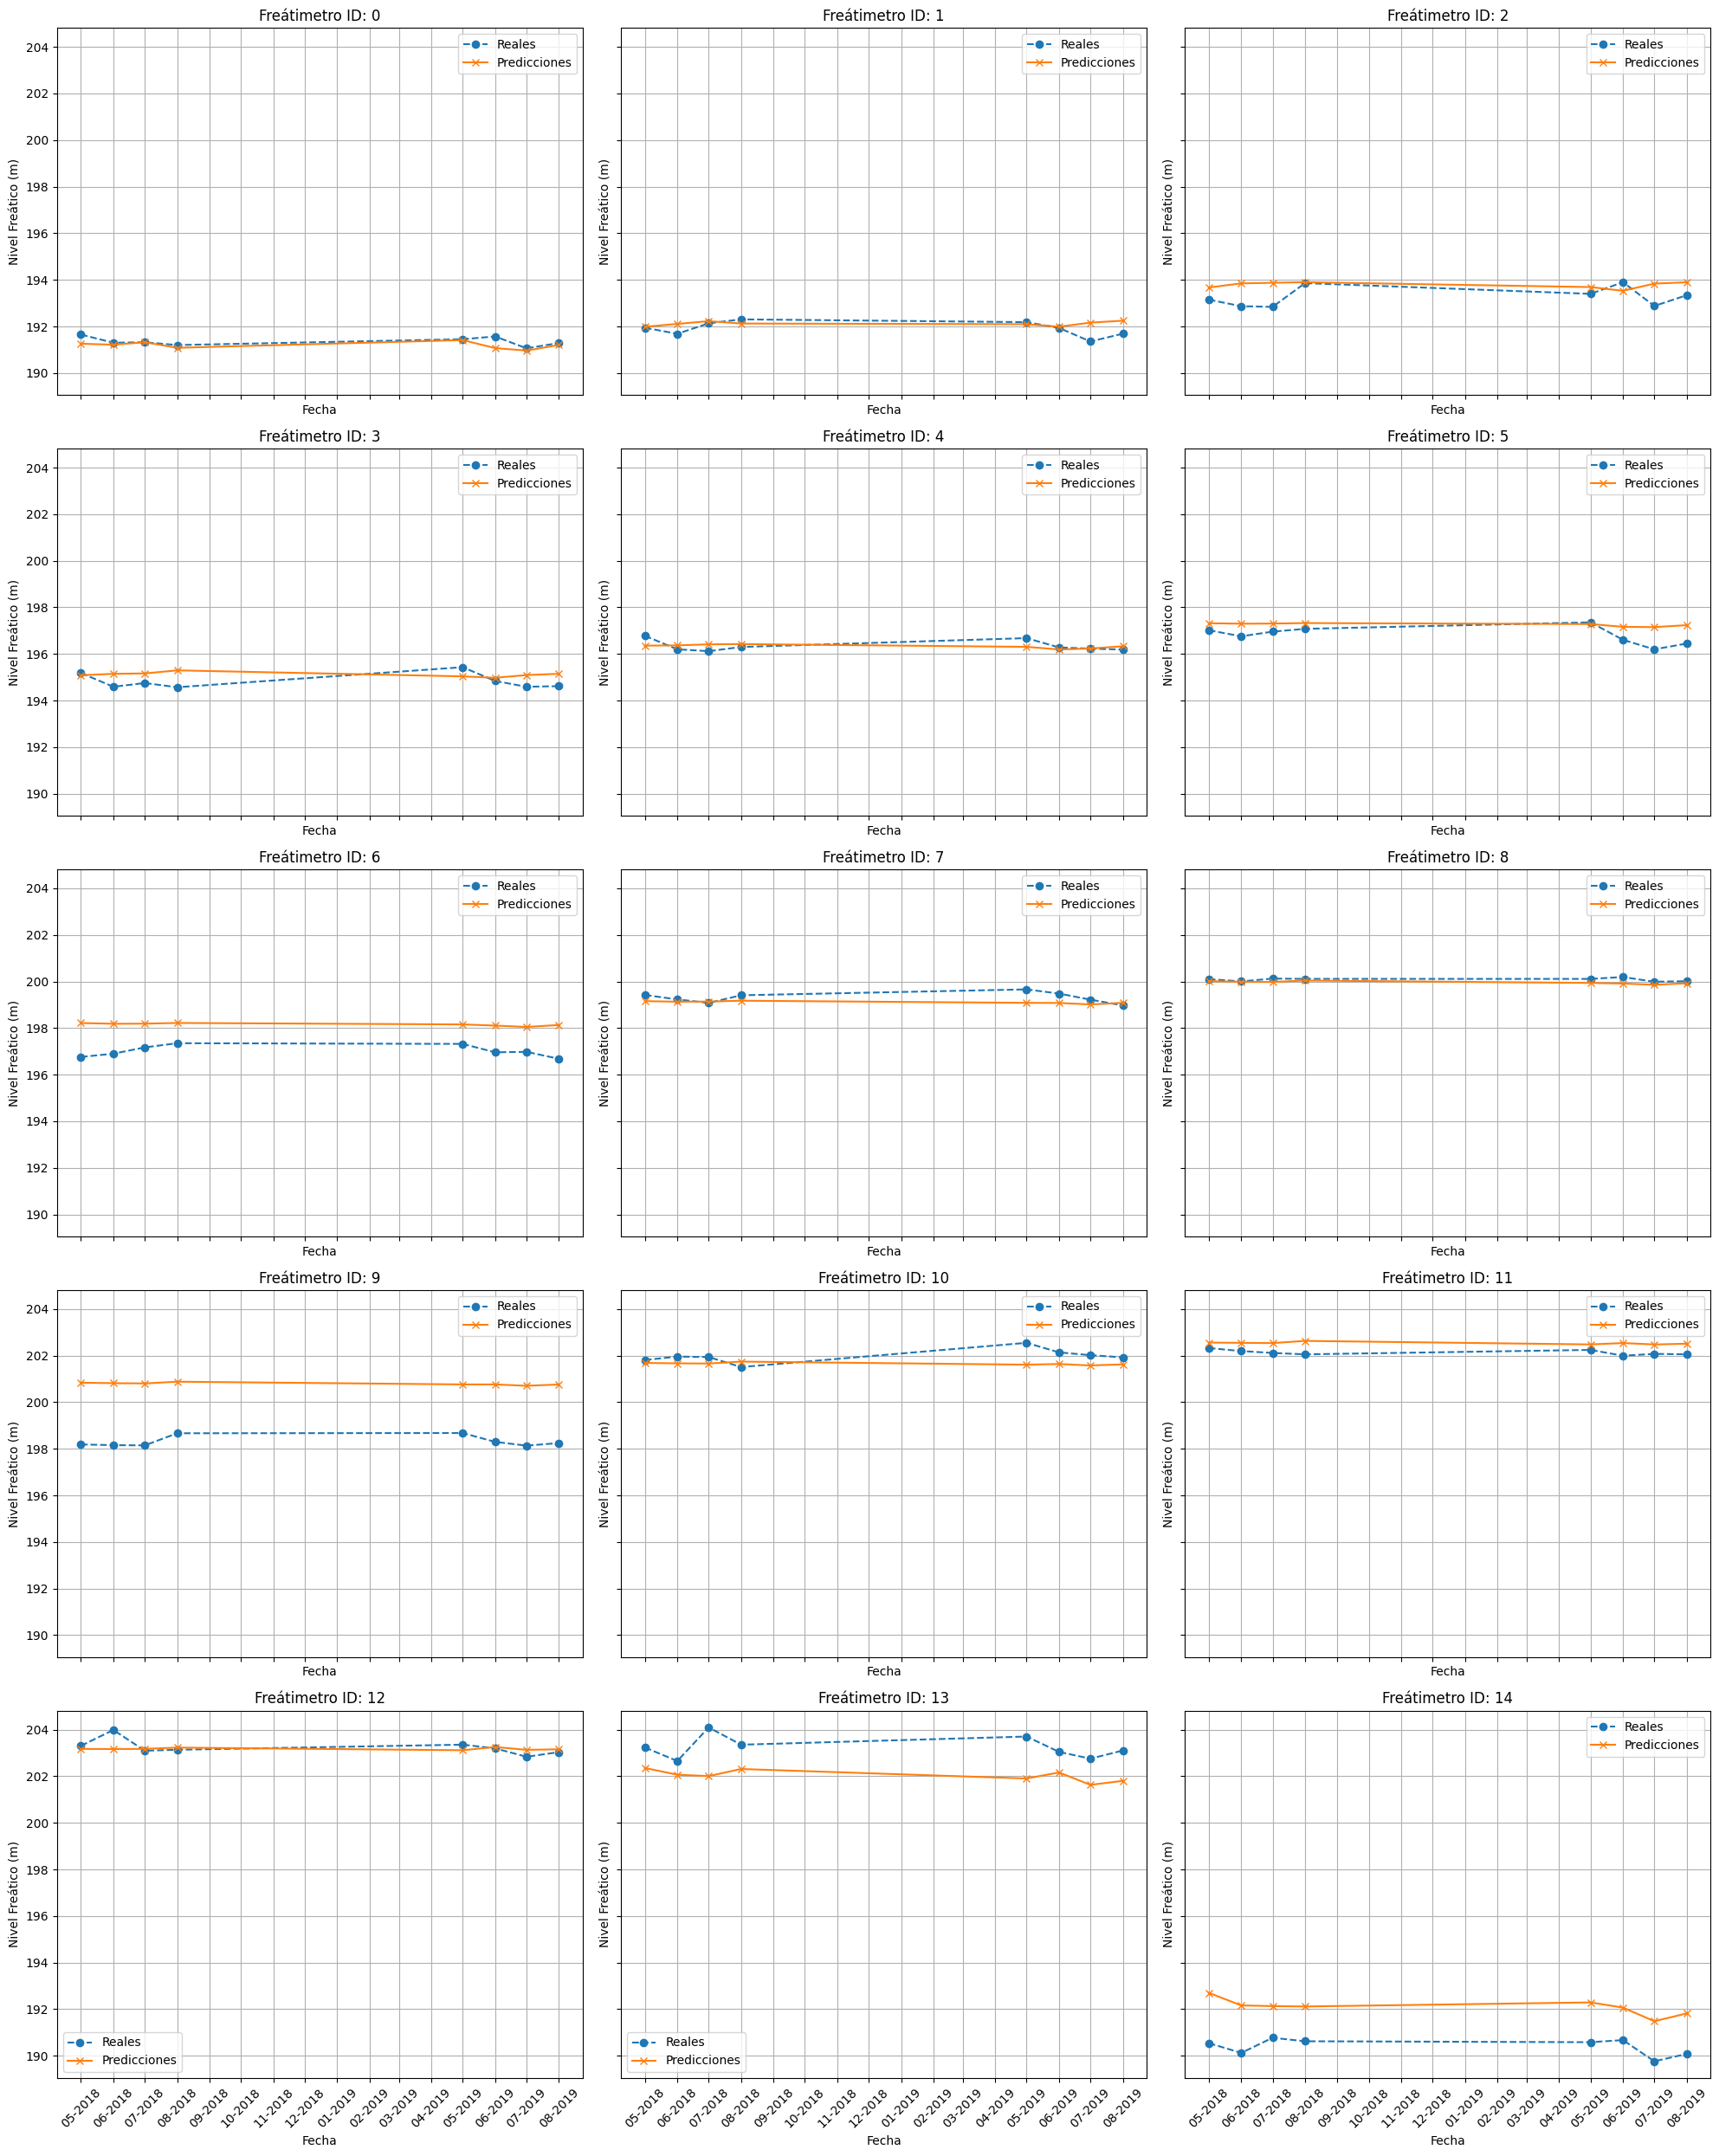

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Obtener los identificadores únicos de los freátimetros del conjunto de prueba
unique_freatimetros = np.unique(X_test[:, 0, -1])  # Asegúrate de que esta es la columna con los IDs de los freátimetros
# Definir el número de filas y columnas para el mosaico
num_freatimetros = len(unique_freatimetros)
rows = int(np.ceil(num_freatimetros / 3))  # Ajustar para que sean 3 columnas
cols = 3

# Crear los subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), sharex=True, sharey=True)

# Aplanar los ejes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre los freátimetros y graficar cada uno en un subplot
for idx, id_freatimetro in enumerate(unique_freatimetros):
    # Filtrar datos del conjunto de prueba para este freátimetro
    mask = (X_test[:, 0, -1] == id_freatimetro)  # Verificar la columna de freátimetro_id
    y_test_filtrado = y_test_desescalado[mask]
    y_pred_filtrado = y_pred_desescalado[mask]
    fechas_test = long_data['fecha'][-len(y_test_desescalado):][mask]  # Filtrar fechas para este freátimetro

    # Graficar en el subplot correspondiente
    ax = axes[idx]
    ax.plot(fechas_test, y_test_filtrado, label="Reales", marker='o', linestyle='--')
    ax.plot(fechas_test, y_pred_filtrado, label="Predicciones", marker='x')
    ax.set_title(f"Freátimetro ID: {int(id_freatimetro)}", fontsize=12)  # Mostrar el ID en el título
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nivel Freático (m)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Mostrar etiquetas mensuales
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.legend()

# Ajustar diseño para evitar superposiciones
plt.tight_layout()

# Eliminar subplots vacíos si el número de freátimetros no llena la cuadrícula
for ax in axes[num_freatimetros:]:
    fig.delaxes(ax)

plt.show()


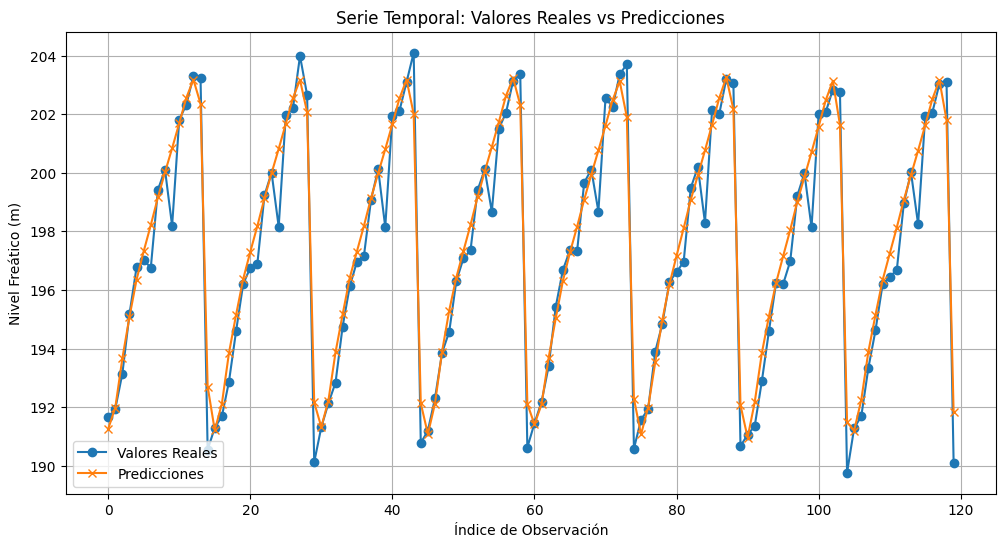

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Datos simulados basados en el modelo previamente entrenado (sustituir con tus datos reales)
y_test_real = y_test_descaled.flatten()  # Valores reales del conjunto de prueba
y_pred_model = y_pred.flatten()  # Predicciones del modelo



# 4. Serie temporal (Valores reales vs Predicciones)
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='Valores Reales', marker='o')
plt.plot(y_pred_model, label='Predicciones', marker='x')
plt.title('Serie Temporal: Valores Reales vs Predicciones')
plt.xlabel('Índice de Observación')
plt.ylabel('Nivel Freático (m)')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Seleccionar la característica principal (solo nivelRio)
features_single = ['nivelRio']
X_single = long_data[features_single].values
y_single = long_data['nivel_freatico'].values

# Escalar la característica y el objetivo
scaler_X_single = StandardScaler()
X_single_scaled = scaler_X_single.fit_transform(X_single)

scaler_y_single = StandardScaler()
y_single_scaled = scaler_y_single.fit_transform(y_single.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_single_scaled, y_single_scaled, test_size=0.2, shuffle=False
)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train_single = X_train_single.reshape(X_train_single.shape[0], 1, X_train_single.shape[1])
X_test_single = X_test_single.reshape(X_test_single.shape[0], 1, X_test_single.shape[1])
print("-------------------------------------------------tamaño de ventana", X_train_single.shape[1])
# Crear un modelo LSTM con solo nivelRio como entrada
model_single = Sequential()
model_single.add(LSTM(64, input_shape=(X_train_single.shape[1], X_train_single.shape[2]), activation='relu', return_sequences=False))
model_single.add(Dense(32, activation='relu'))
model_single.add(Dense(1, activation='linear'))

# Compilar el modelo
model_single.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history_single = model_single.fit(X_train_single, y_train_single, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss_single, mae_single = model_single.evaluate(X_test_single, y_test_single, verbose=1)

# Hacer predicciones
y_pred_single_scaled = model_single.predict(X_test_single)
y_pred_single = scaler_y_single.inverse_transform(y_pred_single_scaled)
y_test_single_descaled = scaler_y_single.inverse_transform(y_test_single)

# Mostrar las métricas y las primeras predicciones
print(f"Loss (MSE) del modelo con nivelRio: {loss_single}, MAE: {mae_single}")
print("Primeras predicciones vs valores reales (modelo con nivelRio):")
for pred, real in zip(y_pred_single[:5], y_test_single_descaled[:5]):
    print(f"Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")


NameError: name 'long_data' is not defined

# LTSM con ventanas 4 meses

In [ ]:
# Importar librerías necesarias
import pandas as pd
# Cargar el archivo (asegúrate de haberlo subido a Colab)
file_path = '/content/drive/MyDrive/Datos Tesis/df_merged_freatimetros_nivelRioNegro.xlsx'
data = pd.read_excel(file_path)

In [ ]:
data["fecha"] = pd.to_datetime(data["fecha"]).dt.date  # Convertir a YYYY-MM-DD


In [ ]:
data = data.sort_values("fecha")


In [ ]:
# Convertir solo los nombres de columnas numéricos a string
data.rename(columns={col: str(col) for col in data.columns if isinstance(col, (int, float))}, inplace=True)
data = data.drop(columns=['index'])

In [ ]:
print(data.dtypes)
print(data.head())

Unnamed: 0.1      int64
Unnamed: 0        int64
60040           float64
60075           float64
60160           float64
60300           float64
60440           float64
60460           float64
60610           float64
60771           float64
60933           float64
60947           float64
60955           float64
61250           float64
61271           float64
61383           float64
62053           float64
fecha            object
año               int64
nivelRio        float64
dtype: object
   Unnamed: 0.1  Unnamed: 0    60040    60075       60160    60300   60440  \
0             0           0  191.432  192.015  194.180000  195.252  197.18   
1             1           1  191.522  191.985  194.070000  195.132  196.62   
2             2           2  191.712  192.555  193.889057  195.252  196.58   
3             3           3  191.592  192.535  193.450000  195.752  196.83   
4             4           8  191.562  191.815  193.499619  194.282  196.34   

     60460   60610       60771       

In [ ]:
!pip install ace_tools

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Cargar datos


# Excluir la columna 'fecha' antes de aplicar MinMaxScaler
scaler = MinMaxScaler()
df_numerico = data.drop(columns=['fecha'])  # Solo columnas numéricas
# Aplicar MinMaxScaler
df_scaled = pd.DataFrame(scaler.fit_transform(df_numerico), columns=df_numerico.columns)

# Restaurar la columna 'fecha' como índice
df_scaled.index = data['fecha']
display(df_scaled.head())


,Unnamed: 0.1,Unnamed: 0,60040,60075,60160,60300,60440,60460,60610,60771,60933,60947,60955,61250,61271,61383,62053,año,nivelRio
fecha,,,,,,,,,,,,,,,,,,,
2010-01-01,0.000000,0.000000,0.440945,0.439490,0.867816,0.659864,0.988372,0.647059,0.946237,0.570884,0.050725,0.654662,0.578035,0.659649,0.370861,0.597222,0.717105,0.0,0.507773
2010-02-01,0.009709,0.006452,0.511811,0.420382,0.804598,0.578231,0.662791,0.631016,0.569892,0.463636,0.326087,0.555643,0.502890,0.631579,0.403974,0.467593,0.671053,0.0,0.514058
2010-03-01,0.019417,0.012903,0.661417,0.783439,0.700607,0.659864,0.639535,0.609626,0.408602,0.781818,0.079710,0.457990,0.456647,0.403509,0.139073,0.444444,0.690789,0.0,0.534616
2010-04-01,0.029126,0.019355,0.566929,0.770701,0.448276,1.000000,0.784884,0.588235,0.586022,0.481818,0.390678,0.658838,0.710070,0.509832,0.440084,0.596547,0.828947,0.0,0.737096
2010-09-01,0.038835,0.051613,0.543307,0.312102,0.476793,0.000000,0.500000,0.058824,0.489247,0.700000,0.485507,0.509510,0.554913,0.392243,0.350396,0.621120,0.802632,0.0,0.305596


In [ ]:
import numpy as np

def create_sequences(data, input_cols, target_col, window_size=4):
    """
    Crea secuencias de datos para entrenar un modelo LSTM, considerando solo los meses de no riego.

    data: DataFrame con los datos filtrados (solo mayo-agosto).
    input_cols: Lista de columnas de entrada (nivel del río + otros freatímetros).
    target_col: Nombre de la columna de salida (freatímetro a predecir).
    window_size: Tamaño de la ventana de tiempo (4 meses).
    """
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[input_cols].iloc[i:i+window_size].values)  # Entrada (todas las variables)
        y.append(data[target_col].iloc[i+window_size])  # Salida (solo un freatímetro)

    return np.array(X), np.array(y)

# Definir columnas de entrada y salida
input_cols = ["nivelRio"] + ["60933", "60947", "60955", "61250", "61271",
                             "61383", "62053", "60075", "60160", "60300",
                             "60440", "60460", "60610", "60771", "60933"]  # Todas las entradas

target_col = "60933"  # Freatímetro que queremos predecir

window_size = 4  # Ahora usamos solo 4 meses de historial en cada muestra

# Crear los conjuntos de datos con los meses filtrados
X, y = create_sequences(df_scaled, input_cols, target_col, window_size)

# Revisar la forma de los datos
print(f"Forma de X: {X.shape}")  # (n_muestras, 4, 16)
print(f"Forma de y: {y.shape}")  # (n_muestras,)


Forma de X: (100, 4, 16)
Forma de y: (100,)


In [ ]:
# Redimensionar X para que sea compatible con LSTM
X = X.reshape((X.shape[0], X.shape[1], len(input_cols)))  # (n_muestras, 4, 16)

# Dividir en entrenamiento (80%) y prueba (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Forma de X_train: {X_train.shape}")  # (n_muestras_entrenamiento, 4, 16)
print(f"Forma de y_train: {y_train.shape}")  # (n_muestras_entrenamiento,)


Forma de X_train: (80, 4, 16)
Forma de y_train: (80,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definir el modelo LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, len(input_cols))),  # Capa LSTM inicial
    Dropout(0.2),  # Dropout para evitar sobreajuste
    LSTM(50, return_sequences=False),  # Segunda capa LSTM
    Dropout(0.2),
    Dense(25, activation="relu"),  # Capa densa intermedia
    Dense(1)  # Capa de salida con un solo valor (nivel de napa del freatímetro objetivo)
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

# Mostrar la estructura del modelo
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 4, 50)               │          13,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,901 (136.33 KB)

 Trainable params: 34,901 (136.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0014 - val_loss: 0.0892
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0016 - val_loss: 0.0708
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0016 - val_loss: 0.0673
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0015 - val_loss: 0.0834
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0018 - val_loss: 0.0745
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0012 - val_loss: 0.0718
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0022 - val_loss: 0.0933
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0036 - val_loss: 0.0643
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0021 - val_loss: 0.0703
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0017 - val_loss: 0.0945
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0020 - val_loss: 0.0796
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0015 - val_lo

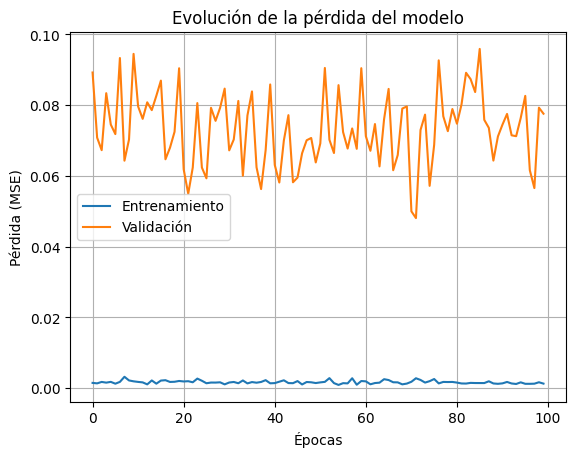

In [ ]:
# Entrenar el modelo LSTM
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Graficar la evolución de la pérdida
import matplotlib.pyplot as plt



plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MSE)")
plt.legend()
plt.title("Evolución de la pérdida del modelo")
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Crear un nuevo scaler solo para la variable objetivo (freatímetro a predecir)
scaler_target = MinMaxScaler()

# Ajustar el scaler solo con la columna del freatímetro objetivo
df_scaled[[target_col]] = scaler_target.fit_transform(df_scaled[[target_col]])

# Hacer predicciones
y_pred = model.predict(X_test)

# Asegurar que y_test y y_pred sean 2D antes de aplicar inverse_transform()
y_test_reshaped = y_test.reshape(-1, 1)
y_pred_reshaped = y_pred.reshape(-1, 1)

# Invertir la normalización usando el scaler específico de la variable objetivo
y_test_real = scaler_target.inverse_transform(y_test_reshaped)
y_pred_real = scaler_target.inverse_transform(y_pred_reshaped)

# Calcular métricas de error
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
MAE: 0.25
RMSE: 0.28


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


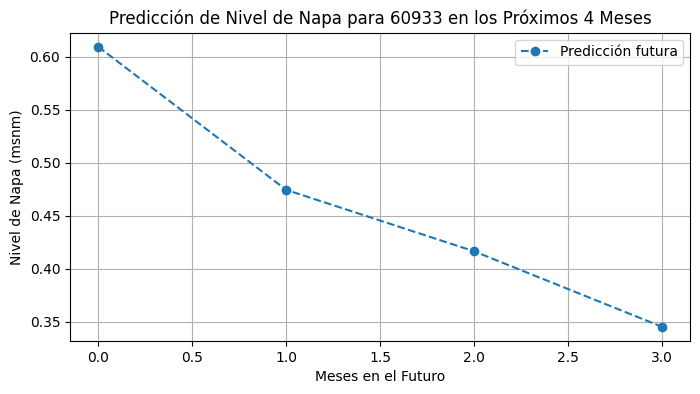

In [ ]:
# Tomar los últimos 4 meses como entrada para predecir el futuro
last_sequence = X_test[-1]  # Últimos 4 meses de datos como punto de partida
future_predictions = []

for _ in range(4):  # Predecir los próximos 4 meses de no riego
    input_seq = np.array([last_sequence])  # Agregar dimensión para ser compatible con el modelo
    pred = model.predict(input_seq)[0][0]  # Obtener el valor escalar de la predicción

    # Desnormalizar la predicción
    pred_real = scaler_target.inverse_transform(np.array([[pred]]))[0][0]

    future_predictions.append(pred_real)

    # Crear una nueva fila con la misma estructura de entrada
    new_row = last_sequence[-1].copy()  # Copiamos la última fila de la secuencia actual
    new_row[input_cols.index(target_col)] = pred  # Reemplazamos solo el valor del freatímetro predicho

    # Agregar la nueva fila a la secuencia eliminando la más antigua
    last_sequence = np.vstack((last_sequence[1:], new_row))  # Desplazar la ventana con la nueva predicción

# Graficar predicción desescalada
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(range(4), future_predictions, marker="o", linestyle="dashed", label="Predicción futura")
plt.xlabel("Meses en el Futuro")
plt.ylabel("Nivel de Napa (msnm)")
plt.legend()
plt.title(f"Predicción de Nivel de Napa para {target_col} en los Próximos 4 Meses")
plt.grid()
plt.show()



# revisando datos promedio clima


In [ ]:
import pandas as pd
# Cargar el archivo (asegúrate de haberlo subido a Colab)
file_path = '/content/drive/MyDrive/Datos Tesis/clima20102019.xlsx'
climaImputado = pd.read_excel(file_path)

In [ ]:
climaImputado.drop(columns=['Time'], inplace=True)

In [ ]:
import pandas as pd
import numpy as np

# Cargar el DataFrame
df = climaImputado

# Asegurar que 'Date' sea de tipo datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


# 🔹 **Identificar valores atípicos en 'Temp Out'**
q1 = df['Temp Out'].quantile(0.25)
q3 = df['Temp Out'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Temp Out'] < lower_bound) | (df['Temp Out'] > upper_bound)]
print("\nValores atípicos en 'Temp Out':\n", outliers.head(100))




Valores atípicos en 'Temp Out':
         Unnamed: 0       Date  Temp Out  Hi Temp  Low Temp  Out Hum  Dew Pt.  \
49871        49871 2011-01-23      39.0     39.2      38.8     23.0     14.1   
49874        49874 2011-01-23      38.9     39.0      38.8     21.0     12.7   
49875        49875 2011-01-23      39.1     39.2      38.9     20.0     12.0   
49876        49876 2011-01-23      39.1     39.3      38.8     22.0     13.5   
49877        49877 2011-01-23      38.9     39.2      38.8     22.0     13.3   
...            ...        ...       ...      ...       ...      ...      ...   
269628      269628 2015-04-16     -67.8    -67.8     -67.8     85.4    -12.3   
269629      269629 2015-04-16     -67.8    -67.8     -67.8     86.8    -12.2   
269630      269630 2015-04-16     -67.8    -67.8     -67.8     86.8    -12.2   
269631      269631 2015-04-16     -67.8    -67.8     -67.8     86.8    -12.2   
269632      269632 2015-04-16     -67.8    -67.8     -67.8     86.0    -12.3   

     

In [ ]:
import pandas as pd

# Cargar el DataFrame
df = climaImputado

# Asegurar que 'Date' sea de tipo datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Filtrar el período de análisis
start_date = "2010-01-28"
end_date = "2019-09-17"
df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Eliminar filas con valores nulos en la fecha o en 'Temp Out'
df = df.dropna(subset=['Date', 'Temp Out'])

# 🔹 **Calcular el promedio diario solo de 'Temp Out'**
df_daily_temp = df.groupby('Date')['Temp Out'].mean()

# 🔹 **Rellenar días faltantes con NaN**
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')
df_daily_temp = df_daily_temp.reindex(all_dates)

# 🔹 **Guardar los resultados en un archivo**
df_daily_temp.to_csv("promedio_diario_TempOut.csv")

# Mostrar los primeros valores corregidos
print(df_daily_temp.head(30))


2010-01-28    28.858621
2010-01-29    26.559028
2010-01-30    16.711111
2010-01-31    19.273611
2010-02-01          NaN
2010-02-02    21.470139
2010-02-03    22.363194
2010-02-04    14.777083
2010-02-05    18.531250
2010-02-06     2.303472
2010-02-07     6.106250
2010-02-08    -1.602083
2010-02-09     6.220139
2010-02-10    12.372222
2010-02-11    21.565972
2010-02-12    17.375694
2010-02-13    23.127778
2010-02-14    18.331944
2010-02-15    10.744444
2010-02-16          NaN
2010-02-17          NaN
2010-02-18          NaN
2010-02-19          NaN
2010-02-20          NaN
2010-02-21          NaN
2010-02-22          NaN
2010-02-23          NaN
2010-02-24          NaN
2010-02-25          NaN
2010-02-26          NaN
Freq: D, Name: Temp Out, dtype: float64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%y")
print(df[['Date']].head())  # Mostrar primeras fechas
print(df.info())  # Verificar tipo de datos de cada columna


        Date
0 2010-01-28
1 2010-01-28
2 2010-01-28
3 2010-01-28
4 2010-01-28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485976 entries, 0 to 485975
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Unnamed: 0      485976 non-null  int64         
 1   Date            485976 non-null  datetime64[ns]
 2   Temp Out        485976 non-null  float64       
 3   Hi Temp         485976 non-null  float64       
 4   Low Temp        485976 non-null  float64       
 5   Out Hum         485976 non-null  float64       
 6   Dew Pt.         485976 non-null  float64       
 7   Wind Speed      485976 non-null  float64       
 8   Wind Run        485976 non-null  float64       
 9   Hi Speed        485976 non-null  float64       
 10  Wind Chill      485976 non-null  float64       
 11  Heat Index      485976 non-null  float64       
 12  THW Index       485976 non-null  float64       
 13  Bar        

In [ ]:
df = climaImputado

# 🔹 **Convertir la columna de fecha al formato datetime**
df['Date'] = pd.to_datetime(df['Date'])  # Asegurar que la fecha sea tipo datetime

# 🔹 **Calcular el promedio diario de cada variable numérica**
df_daily_avg = df.groupby(df['Date'].dt.date).mean()

# 🔹 **Mostrar los primeros resultados**
print(df_daily_avg)


            Unnamed: 0       Date   Temp Out    Hi Temp   Low Temp    Out Hum  \
Date                                                                            
2010-01-02       561.5 2010-01-02  22.731250  23.011806  22.457639  40.125000   
2010-01-03      2631.0 2010-01-03  26.989510  27.139161  26.832867  48.167832   
2010-01-04      7087.5 2010-01-04  18.192361  18.320833  18.050694  45.881944   
2010-01-05     11407.5 2010-01-05  16.639583  16.825694  16.449306  65.958333   
2010-01-06     15871.5 2010-01-06   0.929167   1.030556   0.817361  92.500000   
...                ...        ...        ...        ...        ...        ...   
2019-12-05    467566.5 2019-12-05  14.114583  14.293750  13.938194  69.159722   
2019-12-06    472030.5 2019-12-06   6.897222   7.043056   6.746528  73.395833   
2019-12-07    476350.5 2019-12-07   4.858333   5.027083   4.689583  76.548611   
2019-12-08    480814.5 2019-12-08   4.014583   4.082639   3.938194  86.777778   
2019-12-09    485278.5 2019-

# correlacion con clima con nuevo data set


In [ ]:
import pandas as pd
ruta = "/content/drive/My Drive/Datos Tesis/datosClima/datos_promedios_mensuales_clima.csv"

# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClimaCaso1= pd.read_csv(ruta)
ruta_nivel_rio = '/content/drive/MyDrive/Datos Tesis/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
freatimetro_mesual_caso1= pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_caso1 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)



datosClimaCaso1['Date'] = pd.to_datetime(datosClimaCaso1['Year-Month'])

# Filtrar datos en el periodo 2010-2019 y los meses sin riego para comparar con los datos obtenidos del clima
filtro_datosClima =    (datosClimaCaso1['Date'].dt.year >= 2010) &  (datosClimaCaso1['Date'].dt.year <= 2019) & (datosClimaCaso1['Date'].dt.month.isin([5, 6, 7, 8]))
datosClimaCaso1 = datosClimaCaso1[filtro_datosClima]

filtro_F20102029 = (freatimetro_mesual_caso1['Date'].dt.year >= 2010) & (freatimetro_mesual_caso1['Date'].dt.year <= 2019) &  (freatimetro_mesual_caso1['Date'].dt.month.isin([5, 6, 7, 8]))
freatimetro_mesual_caso1 = freatimetro_mesual_caso1[filtro_F20102029]

filtro_N20102029 = (nivelRioNegro_mensual_caso1['Date'].dt.year >= 2010) & (nivelRioNegro_mensual_caso1['Date'].dt.year <= 2019) &  (nivelRioNegro_mensual_caso1['Date'].dt.month.isin([5, 6, 7, 8]))
nivelRioNegro_mensual_caso1 = nivelRioNegro_mensual_caso1[filtro_N20102029]



KeyError: 'fecha'

In [ ]:
import pandas as pd
ruta = "/content/drive/My Drive/Datos Tesis/datos_unificados_caso1.csv"

# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosUnificados= pd.read_csv(ruta)



In [ ]:
print(datosUnificados.head(50))

          Date   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0   2010-05-01   9.195004   9.353562   9.036850  66.153226  2.170811   
1   2010-06-01   7.458171   7.589769   7.323125  69.237269  1.521782   
2   2010-07-01   5.355690   5.516039   5.193571  57.206317 -3.256362   
3   2010-08-01   7.348992   7.525694   7.174350  50.050403 -3.476165   
4   2011-05-01   9.692182   9.858490   9.525090  60.316756  1.348701   
5   2011-06-01   6.681296   6.829352   6.533032  61.486806 -1.005116   
6   2011-07-01   5.201882   5.379211   5.025045  61.801075 -2.353965   
7   2011-08-01   7.951546   8.095363   7.809095  55.052195 -1.628651   
8   2012-05-01  10.543459  10.691622  10.394668  62.706317  2.819624   
9   2012-06-01   6.734468   6.884306   6.585602  60.207639 -1.234097   
10  2012-07-01   6.141219   6.309789   5.973768  49.546595 -4.592787   
11  2012-08-01   8.647794   8.784983   8.513824  62.744639  0.252484   
12  2013-05-01   9.523454   9.682527   9.364695  65.321461  2.45

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = ["60040", "60075", "60160", "60300", "60440", "60460", "60610", "60771", "60933", "60947", "60955", "61250", "61271", "61383", "62053"]

variables_interes = ['nivelRio', 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.',
       'Wind Speed', 'Wind Run', 'Hi Speed', 'Heat Index',
       'THW Index', 'Bar', 'Rain', 'Rain Rate', 'Solar Rad.', 'Solar Energy',
       'Hi Solar Rad.', 'Heat D-D', 'In Temp', 'In Hum',
       'In Dew', 'In Heat', 'ET'
       ]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

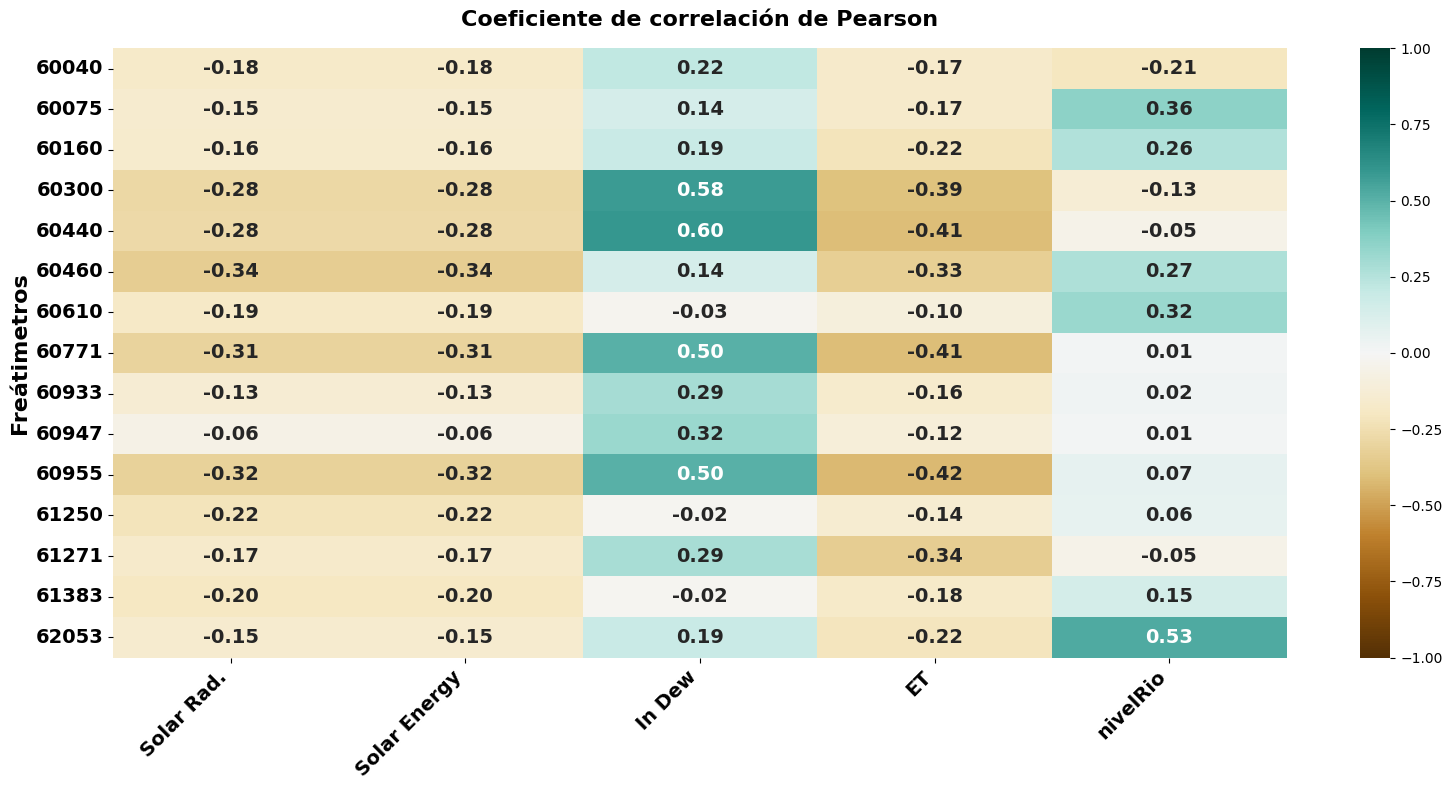

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = datosUnificados[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.20).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 6].index  # Variables que cumplen la condición

# Agregar explícitamente la columna del Nivel del Río si no está incluida
if 'nivelRio' not in variables_to_keep:
    variables_to_keep = variables_to_keep.append(pd.Index(['nivelRio']))

# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Pearson',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


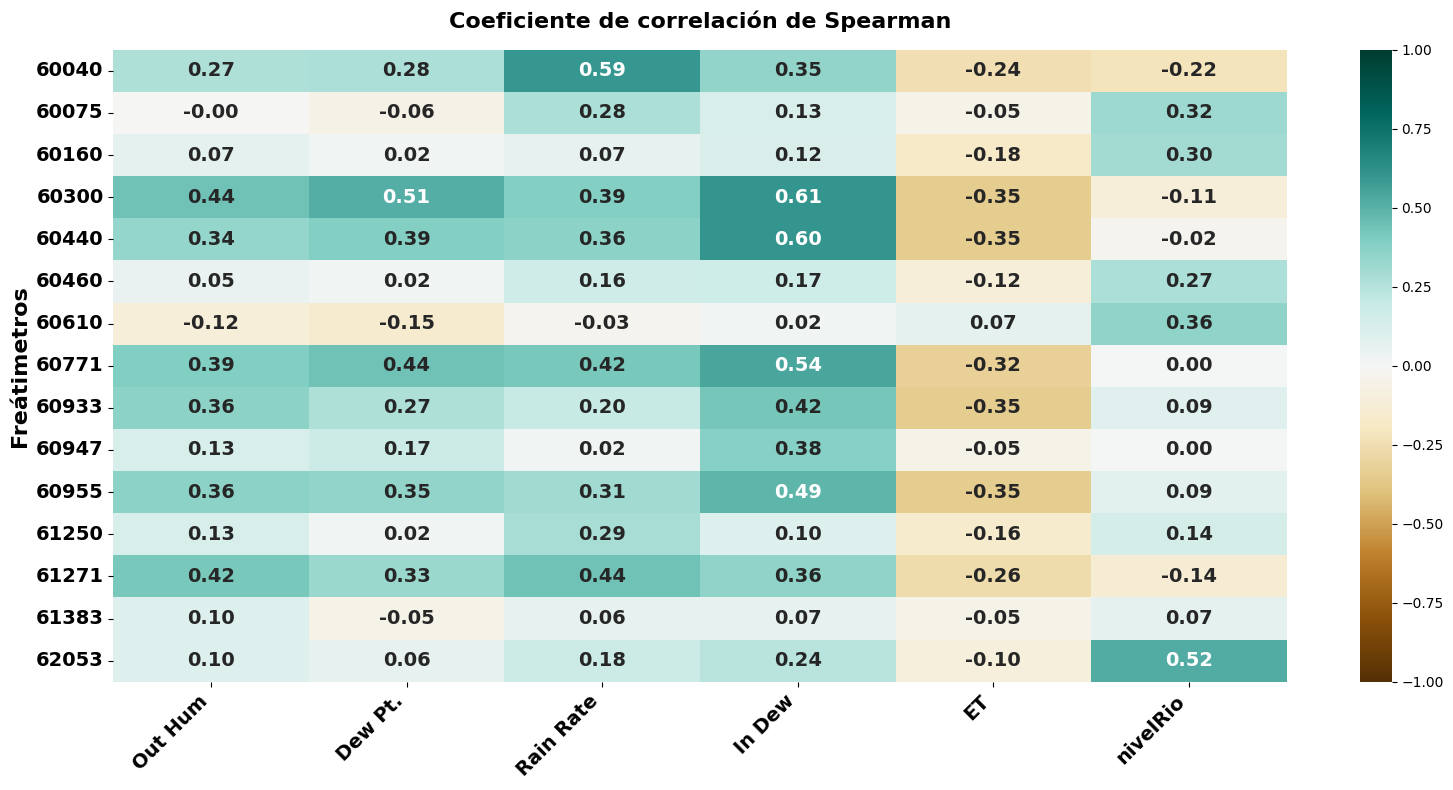

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = datosUnificados[columnas_interes].corr(method='spearman')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.20).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 6].index  # Variables que cumplen la condición

# Agregar explícitamente la columna del Nivel del Río si no está incluida
if 'nivelRio' not in variables_to_keep:
    variables_to_keep = variables_to_keep.append(pd.Index(['nivelRio']))

# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Spearman',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


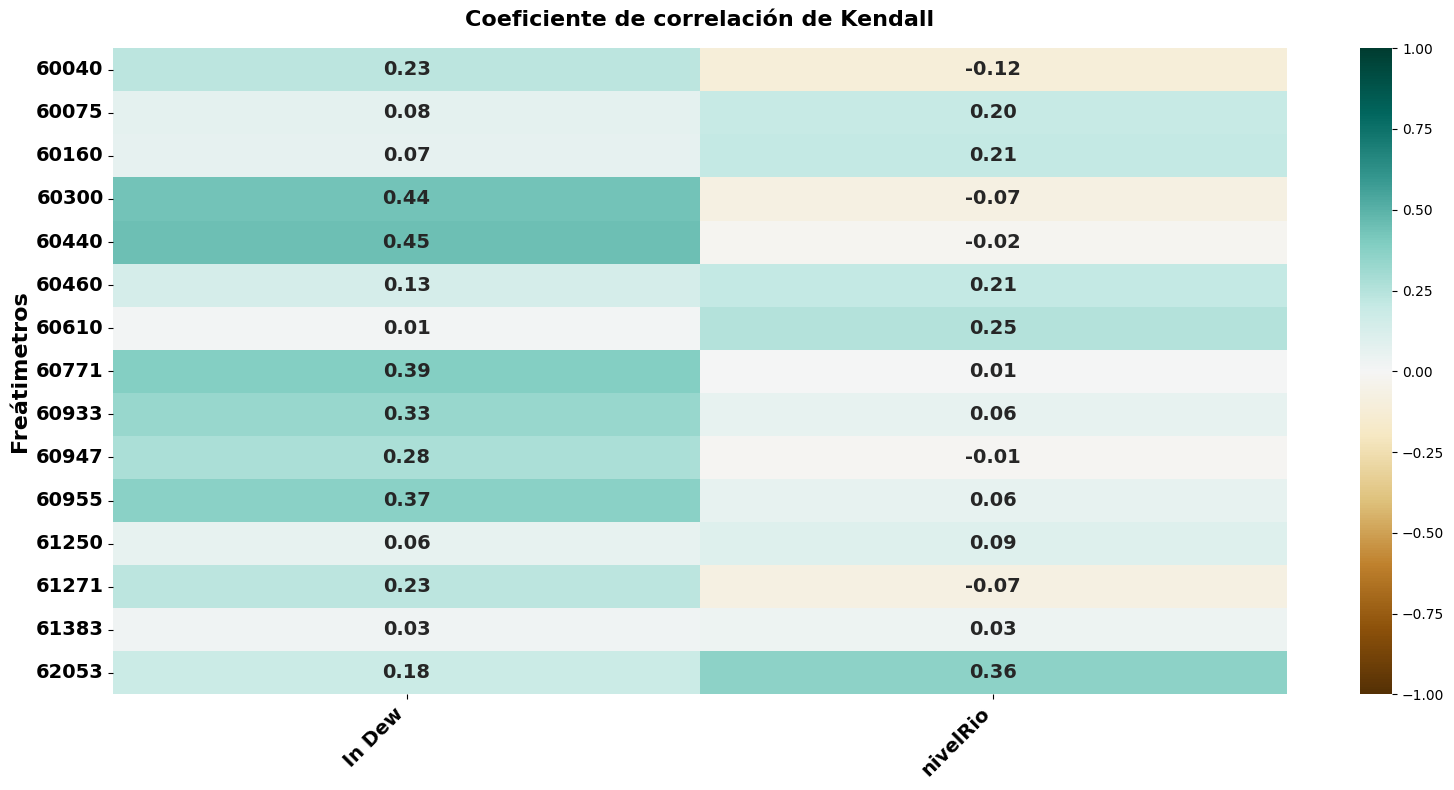

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = datosUnificados[columnas_interes].corr(method='kendall')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.20).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 6].index  # Variables que cumplen la condición

# Agregar explícitamente la columna del Nivel del Río si no está incluida
if 'nivelRio' not in variables_to_keep:
    variables_to_keep = variables_to_keep.append(pd.Index(['nivelRio']))

# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Datos de ejemplo
data = {
    'Temp Out': [5.739338433, 9.385439],
    'Out Hum': [58.3749329, 57.919803]
}

df = pd.DataFrame(data)

# Función mejorada para Davis
def calcular_dew_point_davis(temp, hum):
    a = 17.625
    b = 243.04
    gamma = (a * temp) / (b + temp) + np.log(hum / 100.0)
    dew_point = (b * gamma) / (a - gamma)
    return dew_point

df['Dew Pt Calculado'] = df.apply(lambda row: calcular_dew_point_davis(row['Temp Out'], row['Out Hum']), axis=1)

print(df)


   Temp Out    Out Hum  Dew Pt Calculado
0  5.739338  58.374933         -1.802267
1  9.385439  57.919803          1.515270


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# Ingresar tus datos
data = {
    'Temp Out': [5.739338433, 9.385439068, 10.48928241, 14.77168459, 16.42729066, 20.13458757, 15.5192538, 17.1612645,
                 19.29258735, 13.97162037, 9.19500448, 7.458171296, 5.355689964, 7.348991935, 11.69768519, 15.57381272,
                 18.38403583, 21.25100806, 22.13707437, 21.6750496, 17.96018415, 13.54175926, 9.6921819, 6.681296296,
                 5.20188172, 7.951545699, 13.54168981, 15.53859767, 20.32059078, 22.74908154, 23.88942652, 19.74870205,
                 18.05539875, 12.31464602, 10.54345878, 6.734467593, 6.141218638, 8.647793789, 12.708125, 14.97004928,
                 18.96516002, 20.19554211, 23.5437276, 21.47708333, 15.87275986, 15.06135797, 9.523454301, 8.006689815,
                 6.270743728, 8.4890681, 10.50965426, 16.36181864, 19.20765499, 24.10979069, 23.10432379, 20.31992556,
                 17.17947621, 12.64652334, 9.220945341, 5.967916667, 6.264986559, 10.13274539, 12.46785896, 15.15748522,
                 17.64798977, 21.05705905, 23.07433259, 21.31839901, 19.45145075, 15.60256944, 10.51046147, 8.085509259,
                 6.991845878, 10.40105287, 9.723894465, 13.15857975, 15.19028676, 22.14811718, 23.28821685, 22.3924569,
                 19.09446685, 12.14460648, 9.219900265, 5.229907407, 6.190232975, 10.7437724, 11.7055787, 14.865681,
                 19.81687299, 23.23736559, 23.79419803, 23.06631944, 18.49540771, 13.54590278, 9.77999552, 7.502037037,
                 7.140681004, 12.23709259, 14.09395455, 15.72305108, 18.54045793, 22.52423835, 24.05609319, 23.59761905,
                 17.65766129, 14.81872685, 11.00475772, 5.877615741, 6.18140681, 8.731698029, 12.96905496, 14.11267545,
                 18.64005535, 21.5296595, 22.66160394, 21.83732639, 16.65367244, 14.56993837, 10.14516129, 7.991226852,
                 6.680824373, 8.580510753, 8.530376317],

    'Out Hum': [58.3749329, 57.91980287, 52.20324074, 41.81025986, 41.45683374, 45.89134165, 54.64732641, 50.44596413,
                60.93407764, 58.84652778, 66.15322581, 69.23726852, 57.2063172, 50.05040323, 50.99814815, 51.3015233,
                46.93228663, 41.69735663, 50.5687724, 50.19667659, 56.15283501, 57.27939815, 60.31675627, 61.48680556,
                61.80107527, 55.05219534, 39.00902778, 49.24574373, 42.32688205, 44.30241935, 51.94668459, 57.27310372,
                65.18817204, 63.98882806, 62.7063172, 60.20763889, 49.54659498, 62.74463907, 48.51111111, 53.42293907,
                48.08193438, 43.546819, 55.3608871, 53.85714286, 61.17741935, 69.84378717, 65.32146057, 55.87615741,
                61.93346774, 47.03673835, 51.26303191, 50.48881713, 45.34249195, 41.76232079, 41.10101637, 51.44399177,
                55.43840859, 66.73671515, 76.19108423, 68.47361111, 68.72670251, 56.51171316, 56.91722041, 59.48385589,
                48.77626706, 45.92794048, 48.43444896, 56.75622956, 59.57615613, 65.1037037, 66.60259857, 49.51805556,
                42.08534946, 41.75896057, 48.31477595, 56.49417563, 55.87325395, 45.08312968, 58.13172043, 57.65086207,
                64.96751792, 73.11087963, 87.02183653, 81.19189815, 79.81294803, 62.04771505, 56.6962963, 67.42450717,
                49.23071659, 43.04099462, 44.50828853, 57.87103175, 65.40232975, 74.68472222, 74.16285842, 71.64953704,
                69.0062724, 60.61786842, 57.42488737, 45.09363799, 52.14362923, 44.8046595, 46.97132616, 55.69072421,
                57.98700717, 63.29884259, 72.7872882, 71.55949074, 75.65277778, 58.11536738, 55.62916929, 60.13558037,
                55.88460145, 49.15636201, 44.6780914, 51.22222222, 56.95106954, 64.8208129, 75.30421147, 73.84560185,
                68.39829749, 60.85954301, 60.24077131],

    'Dew Pt Real': [-2.714951244, 0.4699148746, -0.142037037, 0.5911738351, 2.135473027, 6.87538135, 4.970002664, 5.297872462,
                    10.54720376, 5.077569444, 2.170810932, 1.521782407, -3.256362007, -3.476164875, 0.512037037, 4.366509857,
                    5.766036634, 6.447603047, 10.00248656, 9.588789683, 7.830939814, 3.954097222, 1.348700717, -1.005115741,
                    -2.353965054, -1.628651434, -1.215555556, 3.416980287, 5.86571558, 8.685192652, 12.09764785, 9.813182352,
                    10.30710125, 4.539820053, 2.819623656, -1.234097222, -4.592786738, 0.2524841016, 0.8461342593, 4.29312276,
                    6.31428744, 6.347065412, 12.89948477, 10.67624008, 7.359251792, 8.696001622, 2.459520609, -1.159606481,
                    -1.266689068, -3.391061828, -0.3957215327, 4.555001071, 5.619104267, 9.185788192, 7.988420339, 8.801168796,
                    6.948004393, 5.764358804, 4.808848566, -0.002384259259, 0.4041218638, 0.9194452551, 3.024592603, 6.227053241,
                    5.58701006, 7.828382145, 10.41336773, 11.42343492, 10.33563975, 8.332800926, 3.860147849, -2.386759259,
                    -7.763463262, -3.274484767, -2.870454515, 3.297782258, 4.985497783, 8.053428986, 13.3265681, 12.09578544,
                    11.22576165, 6.684953704, 7.00926835, 1.82412037, 2.59500448, 2.743548387, 2.025023148, 7.877934588,
                    7.622740539, 8.732459677, 9.537746416, 13.20205853, 10.66635305, 8.56212963, 4.733154122, 1.996550926,
                    0.9596102151, 3.541186962, 4.513822242, 2.539516129, 6.855643116, 8.577374552, 10.64950717, 12.84794147,
                    7.874350358, 6.674074074, 5.463817123, 0.4315046296, 1.675067204, -0.179390681, 2.898946048, 5.218546194,
                    8.207386272, 8.928561828, 8.392316308, 10.04650298, 6.774549205, 6.932551126, 5.392226703, 3.043865741,
                    0.4864023297, 0.3967741935, 0.1711934774]
}

df = pd.DataFrame(data)

# NUEVA fórmula con coeficientes ajustados (prueba con diferentes valores)
def calcular_dew_point(temp, hum, a=17.62, b=243.12):
    alpha = ((a * temp) / (b + temp)) + np.log(hum / 100.0)
    dew_point = (b * alpha) / (a - alpha)
    return dew_point

# Aplicar
df['Dew Pt Ajustado'] = df.apply(lambda row: calcular_dew_point(row['Temp Out'], row['Out Hum']), axis=1)

# Evaluar
mae = mean_absolute_error(df['Dew Pt Real'], df['Dew Pt Ajustado'])
print(df[['Temp Out', 'Out Hum', 'Dew Pt Ajustado', 'Dew Pt Real']])
print(f"\nError absoluto medio (MAE): {mae:.4f}")


      Temp Out    Out Hum  Dew Pt Ajustado  Dew Pt Real
0     5.739338  58.374933        -1.806713    -2.714951
1     9.385439  57.919803         1.510705     0.469915
2    10.489282  52.203241         1.091297    -0.142037
3    14.771685  41.810260         1.908233     0.591174
4    16.427291  41.456834         3.281945     2.135473
..         ...        ...              ...          ...
118  10.145161  75.304211         5.968200     5.392227
119   7.991227  73.845602         3.606172     3.043866
120   6.680824  68.398297         1.267956     0.486402
121   8.580511  60.859543         1.444444     0.396774
122   8.530376  60.240771         1.254565     0.171193

[123 rows x 4 columns]

Error absoluto medio (MAE): 1.1166


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Variables independientes y dependientes
X = df[['Dew Pt Ajustado']].values  # Predicciones anteriores
y = df['Dew Pt Real'].values        # Valores reales

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X, y)

# Aplicar la corrección
df['Dew Pt Corregido'] = model.predict(X)

# Evaluar
mae_corr = mean_absolute_error(y, df['Dew Pt Corregido'])

# Mostrar resultados
print(df[['Dew Pt Ajustado', 'Dew Pt Real', 'Dew Pt Corregido']])
print(f"\nNuevo MAE corregido: {mae_corr:.4f}")
print(f"\nEcuación de ajuste: Dew Pt Corregido = {model.coef_[0]:.4f} * Dew Pt Ajustado + {model.intercept_:.4f}")


     Dew Pt Ajustado  Dew Pt Real  Dew Pt Corregido
0          -1.806713    -2.714951         -2.816409
1           1.510705     0.469915          0.454252
2           1.091297    -0.142037          0.040756
3           1.908233     0.591174          0.846178
4           3.281945     2.135473          2.200528
..               ...          ...               ...
118         5.968200     5.392227          4.848922
119         3.606172     3.043866          2.520186
120         1.267956     0.486402          0.214925
121         1.444444     0.396774          0.388926
122         1.254565     0.171193          0.201723

[123 rows x 3 columns]

Nuevo MAE corregido: 0.2384

Ecuación de ajuste: Dew Pt Corregido = 0.9859 * Dew Pt Ajustado + -1.0352


# Datos clima ampliado 2020 a 2022

In [ ]:
import pandas as pd
ruta = "/content/drive/My Drive/Datos Tesis/datosClima/clima_completo_2009_2022_imputado.xlsx"
nombre_pestaña_clima = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClimaCaso1= pd.read_excel(ruta, sheet_name=nombre_pestaña_clima)
ruta_nivel_rio = '/content/drive/MyDrive/Datos Tesis/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
freatimetro_mesual_caso1= pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_caso1 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)



datosClimaCaso1['Date'] = pd.to_datetime(datosClimaCaso1['Year-Month'])

# Filtrar datos en el periodo 2010-2022 y los meses sin riego para comparar con los datos obtenidos del clima
filtro_datosClima =    (datosClimaCaso1['Date'].dt.year >= 2010) &  (datosClimaCaso1['Date'].dt.year <= 2022) & (datosClimaCaso1['Date'].dt.month.isin([5, 6, 7, 8]))
datosClimaCaso1 = datosClimaCaso1[filtro_datosClima]

filtro_F20102029 = (freatimetro_mesual_caso1['Date'].dt.year >= 2010) & (freatimetro_mesual_caso1['Date'].dt.year <= 2022) &  (freatimetro_mesual_caso1['Date'].dt.month.isin([5, 6, 7, 8]))
freatimetro_mesual_caso1 = freatimetro_mesual_caso1[filtro_F20102029]

filtro_N20102029 = (nivelRioNegro_mensual_caso1['Date'].dt.year >= 2010) & (nivelRioNegro_mensual_caso1['Date'].dt.year <= 2022) &  (nivelRioNegro_mensual_caso1['Date'].dt.month.isin([5, 6, 7, 8]))
nivelRioNegro_mensual_caso1 = nivelRioNegro_mensual_caso1[filtro_N20102029]



In [ ]:
import pandas as pd

# Cargar los tres archivos filtrados
df_clima = datosClimaCaso1
df_freatimetros = freatimetro_mesual_caso1
df_rio = nivelRioNegro_mensual_caso1

# Asegurarse que las columnas Date estén en datetime
df_clima['Date'] = pd.to_datetime(df_clima['Date'])
df_freatimetros['Date'] = pd.to_datetime(df_freatimetros['Date'])
df_rio['Date'] = pd.to_datetime(df_rio['Date'])

# Unir los tres DataFrames por la columna Date
# Usamos INNER JOIN para quedarnos solo con fechas comunes
df_unificado = df_clima.merge(df_freatimetros, on='Date', how='inner')
df_unificado = df_unificado.merge(df_rio[['Date', 'promedio']], on='Date', how='inner')

# Ordenar por fecha
df_unificado.sort_values('Date', inplace=True)


print(df_unificado)


    Rain Rate    Out Hum        ET   Dew Pt.       Date Year-Month  \
0   11.815681  66.153226  0.010356  2.170811 2010-05-01    2010-05   
1    0.012222  69.237269  0.009551  1.521782 2010-06-01    2010-06   
2    0.000000  57.206317  0.011452 -3.256362 2010-07-01    2010-07   
3    0.000582  50.050403  0.015784 -3.476165 2010-08-01    2010-08   
4    0.184543  60.316756  0.012083  1.348701 2011-05-01    2011-05   
5    0.005926  61.486806  0.009405 -1.005116 2011-06-01    2011-06   
6    0.013620  61.801075  0.008889 -2.353965 2011-07-01    2011-07   
7    0.003226  55.052195  0.014931 -1.628651 2011-08-01    2011-08   
8    0.000000  62.706317  0.011331  2.819624 2012-05-01    2012-05   
9    0.004120  60.207639  0.010039 -1.234097 2012-06-01    2012-06   
10   0.000582  49.546595  0.013858 -4.592787 2012-07-01    2012-07   
11   0.235454  62.744639  0.012249  0.252484 2012-08-01    2012-08   
12   0.003271  65.321461  0.011922  2.459521 2013-05-01    2013-05   
13   0.008750  55.87

In [ ]:
import pandas as pd
ruta = '/content/drive/My Drive/Datos Tesis/datosClima/clima_unificado_2010_2022_caso1.xlsx'
nombre_pestaña_clima = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datos_unificados_Caso1= pd.read_excel(ruta, sheet_name=nombre_pestaña_clima)

In [ ]:
print(datos_unificados_Caso1)

    Rain Rate    Out Hum        ET   Dew Pt.       Date Year-Month  \
0   11.815681  66.153226  0.010356  2.170811 2010-05-01    2010-05   
1    0.012222  69.237269  0.009551  1.521782 2010-06-01    2010-06   
2    0.000000  57.206317  0.011452 -3.256362 2010-07-01    2010-07   
3    0.000582  50.050403  0.015784 -3.476165 2010-08-01    2010-08   
4    0.184543  60.316756  0.012083  1.348701 2011-05-01    2011-05   
5    0.005926  61.486806  0.009405 -1.005116 2011-06-01    2011-06   
6    0.013620  61.801075  0.008889 -2.353965 2011-07-01    2011-07   
7    0.003226  55.052195  0.014931 -1.628651 2011-08-01    2011-08   
8    0.000000  62.706317  0.011331  2.819624 2012-05-01    2012-05   
9    0.004120  60.207639  0.010039 -1.234097 2012-06-01    2012-06   
10   0.000582  49.546595  0.013858 -4.592787 2012-07-01    2012-07   
11   0.235454  62.744639  0.012249  0.252484 2012-08-01    2012-08   
12   0.003271  65.321461  0.011922  2.459521 2013-05-01    2013-05   
13   0.008750  55.87

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

variables_interes = ['Out Hum', 'Dew Pt.',
       'Rain Rate'
       ]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

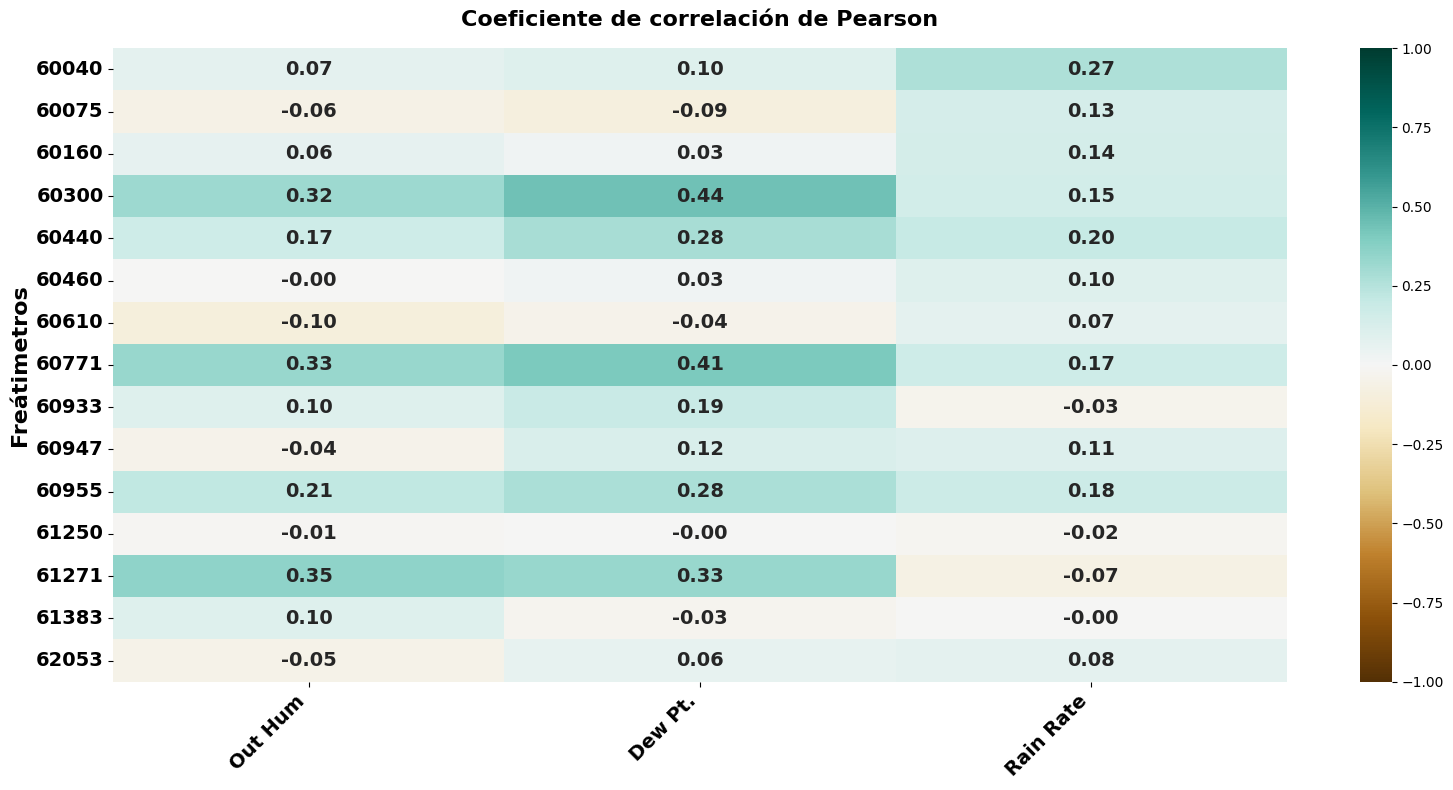

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = datos_unificados_Caso1[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.00).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 1].index  # Variables que cumplen la condición



# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Pearson',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


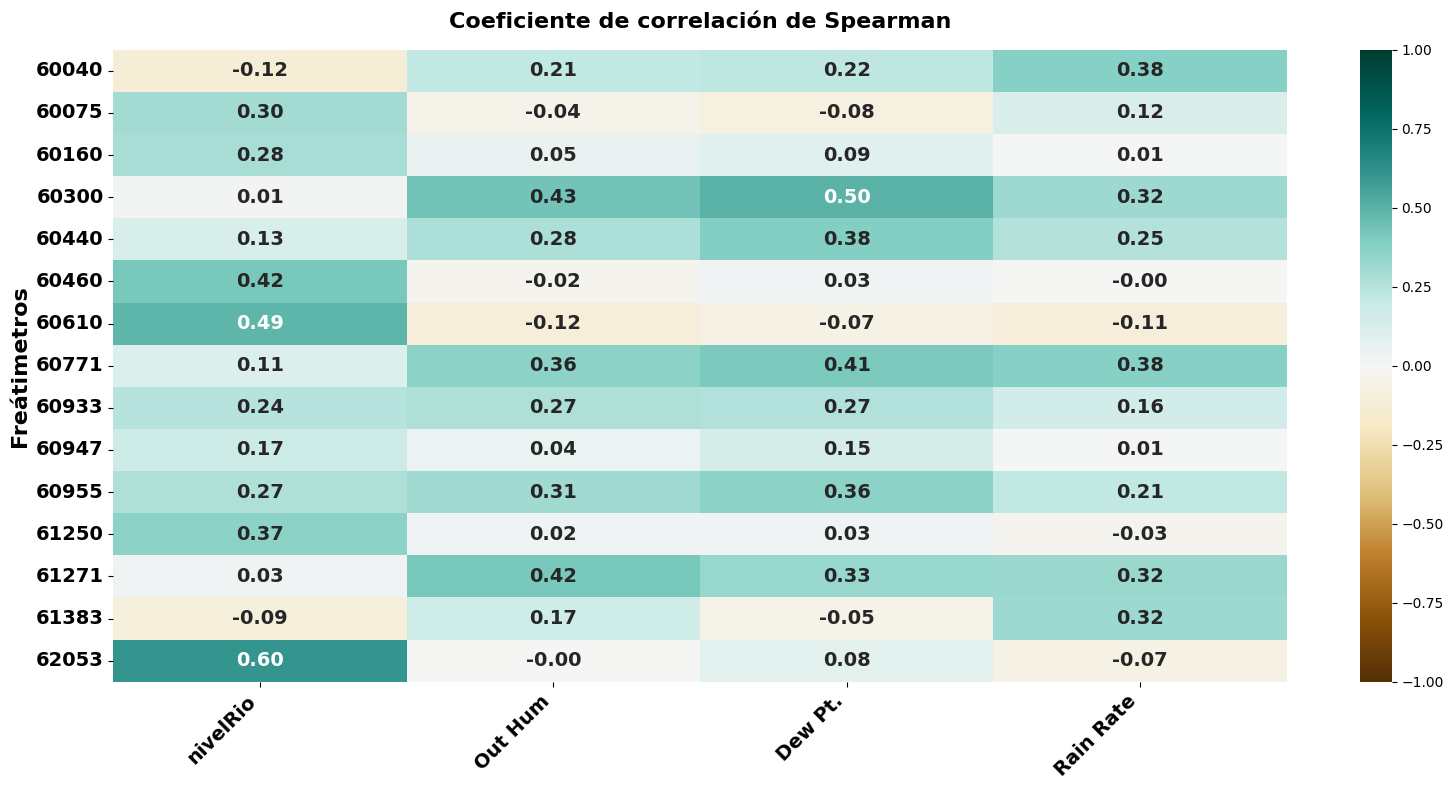

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = datos_unificados_Caso1[columnas_interes].corr(method='spearman')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.00).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 1].index  # Variables que cumplen la condición

# Agregar explícitamente la columna del Nivel del Río si no está incluida
if 'nivelRio' not in variables_to_keep:
    variables_to_keep = variables_to_keep.append(pd.Index(['nivelRio']))

# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Spearman',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


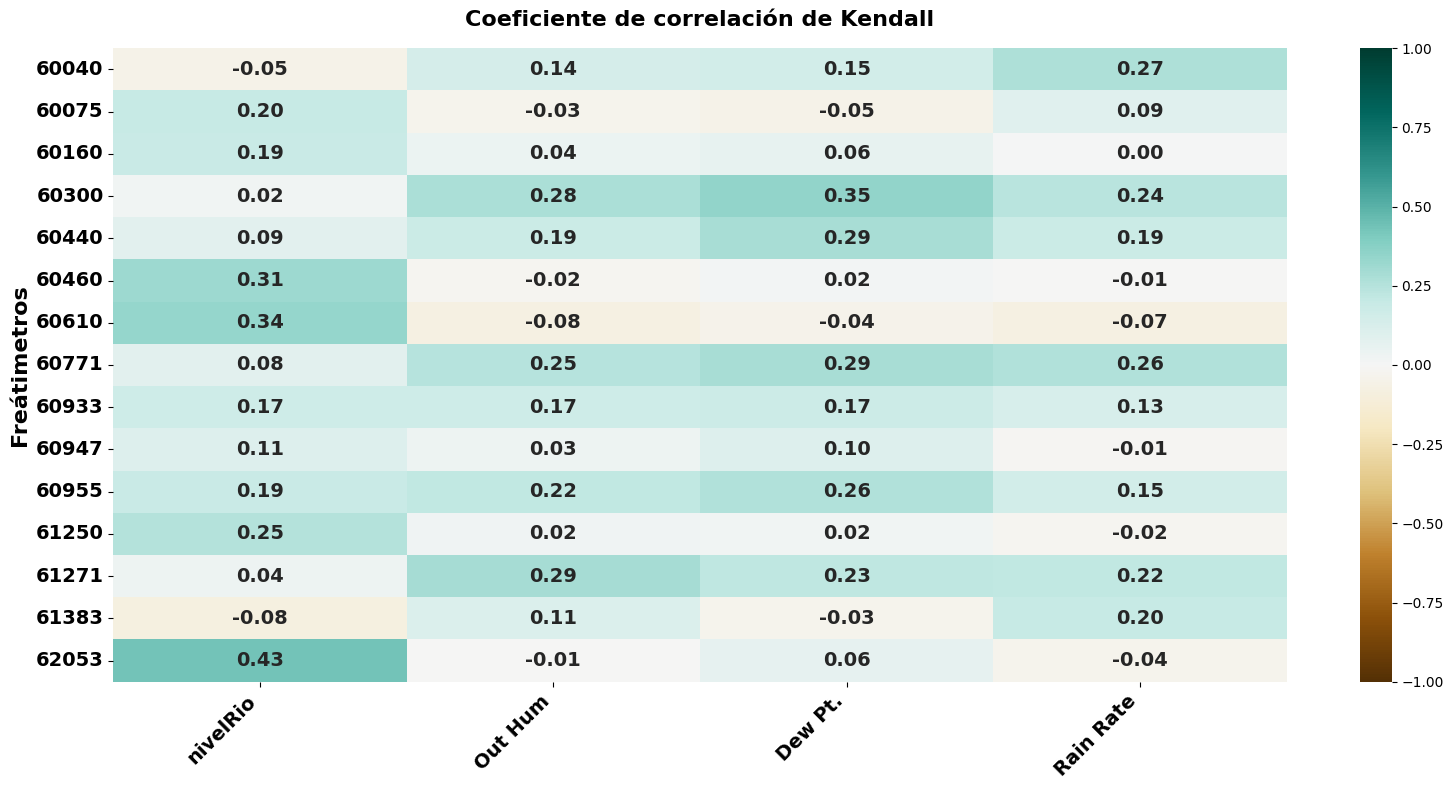

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = datos_unificados_Caso1[columnas_interes].corr(method='kendall')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.00).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 1].index  # Variables que cumplen la condición

# Agregar explícitamente la columna del Nivel del Río si no está incluida
if 'nivelRio' not in variables_to_keep:
    variables_to_keep = variables_to_keep.append(pd.Index(['nivelRio']))

# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


In [ ]:
datasetMerge=datos_unificados_Caso1

In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]
#'In  Dew','Hi Speed'

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    datasetMerge,
    id_vars=['Date','Dew Pt.','Out Hum','Rain Rate'],  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['Date', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['Date'].dtype)
print(long_data['Date'].head())
long_data = long_data[
    (long_data['Date'].dt.month.isin([5, 6, 7, 8])) &
    (long_data['Date'].dt.year.between(2010, 2021))
]

# Revisar el resultado de la transformación
print(long_data.head())


datetime64[ns]
0     2010-05-01
52    2010-05-01
104   2010-05-01
156   2010-05-01
208   2010-05-01
Name: Date, dtype: datetime64[ns]
          Date   Dew Pt.    Out Hum  Rain Rate freátimetro_id  nivel_freatico
0   2010-05-01  2.170811  66.153226  11.815681          60040         191.942
52  2010-05-01  2.170811  66.153226  11.815681          60075         192.265
104 2010-05-01  2.170811  66.153226  11.815681          60160         194.090
156 2010-05-01  2.170811  66.153226  11.815681          60300         195.082
208 2010-05-01  2.170811  66.153226  11.815681          60440         196.570


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Asumo que ya tenés tu DataFrame df con las variables climáticas y el freatimetro_id

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización - Variables Climáticas**
# ========================================================================
df = long_data.copy()
# 🔹 **Orden personalizado para freatímetros**
unique_ids = np.sort(df['freátimetro_id'].unique())
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}
df['freátimetro_id_encoded'] = df['freátimetro_id'].map(id_to_encoded)

# 🔹 **Escalar las variables climáticas seleccionadas**
scaler_X = StandardScaler()
df[['rain_rate_scaled', 'out_hum_scaled', 'dew_pt_scaled']] = scaler_X.fit_transform(df[['Rain Rate', 'Out Hum', 'Dew Pt.']])

# 🔹 **Escalar la variable de salida (nivel freático)**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])

# ========================================================================
# 2️⃣ **Generación de Secuencias (Ventana de 4 Meses)**
# ========================================================================

def create_sequences_per_freatimetro(df, window_size=4):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('Date')

        X = df_freatimetro[['rain_rate_scaled', 'out_hum_scaled', 'dew_pt_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['Date'].values

        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]

            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# ========================================================================
# 3️⃣ **División en Entrenamiento y Prueba POR FREATÍMETRO**
# ========================================================================

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=4)

for freatimetro_id in np.unique(freatimetros_seq):
    indices_freatimetro = np.where(freatimetros_seq == freatimetro_id)[0]
    train_size = int(len(indices_freatimetro) * 0.8)

    X_train_list.append(X_seq[indices_freatimetro[:train_size]])
    X_test_list.append(X_seq[indices_freatimetro[train_size:]])
    y_train_list.append(y_seq[indices_freatimetro[:train_size]])
    y_test_list.append(y_seq[indices_freatimetro[train_size:]])
    fechas_train_list.append(fechas_seq[indices_freatimetro[:train_size]])
    fechas_test_list.append(fechas_seq[indices_freatimetro[train_size:]])
    freatimetros_train_list.append(freatimetros_seq[indices_freatimetro[:train_size]])
    freatimetros_test_list.append(freatimetros_seq[indices_freatimetro[train_size:]])

X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)

# ========================================================================
# ✅ **Verificación**
# ========================================================================
print(f"🔹 X_train shape: {X_train.shape}  (n_muestras, 4, 4)")  # 4 variables ahora
print(f"🔹 y_train shape: {y_train.shape}")
print(f"🔹 Variables usadas: rain_rate, out_hum, dew_pt + ID freatímetro")


🔹 X_train shape: (525, 4, 4)  (n_muestras, 4, 4)
🔹 y_train shape: (525,)
🔹 Variables usadas: rain_rate, out_hum, dew_pt + ID freatímetro


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

# 🔹 **Compilar el Modelo**
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.7862 - mae: 0.7167 - val_loss: 0.1776 - val_mae: 0.4111
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2669 - mae: 0.3963 - val_loss: 0.2114 - val_mae: 0.4486
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1162 - mae: 0.2789 - val_loss: 0.3797 - val_mae: 0.6088
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0915 - mae: 0.2425 - val_loss: 0.2530 - val_mae: 0.4954
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0829 - mae: 0.2243 - val_loss: 0.1146 - val_mae: 0.3274
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0847 - mae: 0.2270 - val_loss: 0.0562 - val_mae: 0.2223
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0903 - mae: 0.2319 - val_loss: 0.0645 - val_mae: 0.2399
Epoch 8/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0726 - mae: 0.2132 - val_loss: 0.0858 - val_mae: 0.2814
Epoch 9/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0650 

In [ ]:
import pandas as pd

# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================

# Evaluar el modelo en el conjunto de prueba
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# 🔹 Generar predicciones escaladas
y_pred_scaled = model.predict(X_test)

# 🔹 Desescalar predicciones y valores reales para interpretarlos en unidades originales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 Decodificar IDs de los freatímetros
encoded_to_id = {v: k for k, v in id_to_encoded.items()}
freatimetros_test_original = [encoded_to_id[id_] for id_ in freatimetros_test]

# 🔹 Crear DataFrame con resultados
df_resultados = pd.DataFrame({
    "Fecha": fechas_test,
    "Freátimetro ID": freatimetros_test_original,
    "Predicción": y_pred.flatten(),
    "Real": y_test_descaled.flatten()
})

# 🔹 Ordenar y obtener última predicción por freatímetro
df_resultados = df_resultados.sort_values(by=["Freátimetro ID", "Fecha"])
df_ultimas_predicciones = df_resultados.groupby("Freátimetro ID").last().reset_index()

# 🔹 Mostrar resultados
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
print(df_ultimas_predicciones)

# 🔹 Guardar en Excel si querés hacer un análisis posterior
df_ultimas_predicciones.to_excel("predicciones_clima_ventana4.xlsx", index=False)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0324 - mae: 0.1250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step

Loss (MSE): 0.0380, MAE: 0.1343
📌 Última predicción de cada freatímetro:
    Freátimetro ID      Fecha  Predicción        Real
0            60040 2021-08-01  191.376801  191.429695
1            60075 2021-08-01  192.464737  191.816591
2            60160 2021-08-01  193.726471  193.431526
3            60300 2021-08-01  195.176010  194.701084
4            60440 2021-08-01  196.402145  196.325908
5            60460 2021-08-01  197.243713  196.840106
6            60610 2021-08-01  198.220810  197.021264
7            60771 2021-08-01  199.083725  199.371072
8            60933 2021-08-01  199.972427  200.203119
9            60947 2021-08-01  200.815918  198.845000
10           60955 2021-08-01  201.584381  201.807000
11           61250 2021-08-01  202.263596  201.393000
12           61271 2021-08-01  202.851379  202.627000
13           61383 2021-08-01  203.353058  203.895000
14        

In [ ]:
ruta_modelo = '/content/drive/My Drive/Datos Tesis/datosClima/modelo_lstm_climaticas.h5'
modelo=

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


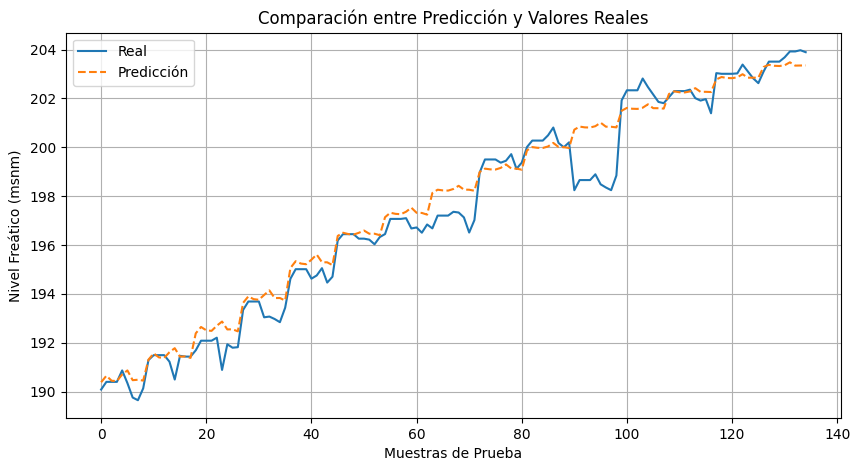

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Real", linestyle="-")
plt.plot(y_pred, label="Predicción", linestyle="dashed")
plt.xlabel("Muestras de Prueba")
plt.ylabel("Nivel Freático (msnm)")
plt.title("Comparación entre Predicción y Valores Reales")
plt.legend()
plt.grid()
plt.show()

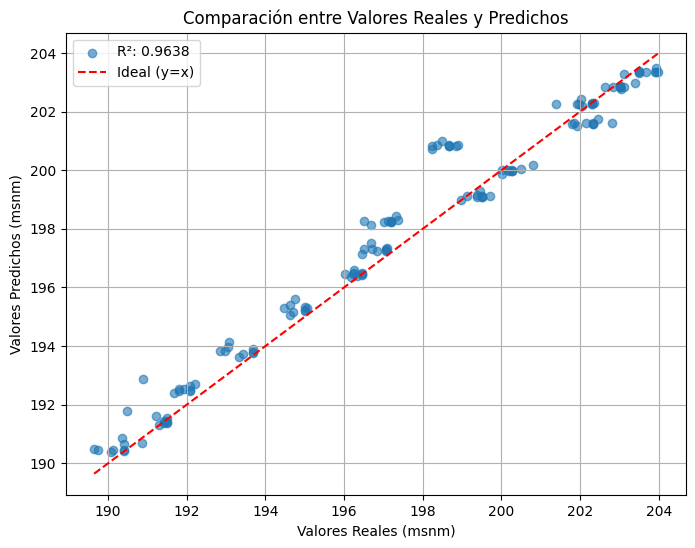

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Calcular R²
r2 = r2_score(y_test_descaled, y_pred)
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test_descaled, y_pred))

print(f"📉 RMSE: {rmse:.4f}")

📉 RMSE: 0.8149


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from dateutil.relativedelta import relativedelta

def predecir_nivel_freatico_2022(model, df, scaler_X, scaler_y, id_to_encoded):
    """
    Predice el nivel freático para todos los freatímetros para mayo-agosto de 2022.

    Parámetros:
    - model: Modelo LSTM entrenado.
    - df: DataFrame con los datos históricos.
    - scaler_X: Escalador para las variables climáticas.
    - scaler_y: Escalador para los valores de salida (nivel freático).
    - id_to_encoded: Diccionario con el mapeo manual de freatímetros.

    Retorna:
    - DataFrame con las predicciones.
    """

    resultados = []

    for freatimetro_id in df['freátimetro_id'].unique():
        # Filtrar datos del freatímetro
        df_freatimetro = df[df["freátimetro_id"] == freatimetro_id].copy()

        # Seleccionar solo los meses de mayo-agosto
        df_freatimetro["mes"] = df_freatimetro["Date"].dt.month
        df_freatimetro = df_freatimetro[df_freatimetro["mes"].isin([5, 6, 7, 8])]

        # Verificar si hay suficientes datos (4 meses previos)
        df_freatimetro_2021 = df_freatimetro[df_freatimetro['Date'].dt.year == 2021].sort_values('Date')
        if len(df_freatimetro_2021) < 4:
            continue

        # Tomar los últimos 4 registros
        ultimo_periodo = df_freatimetro_2021[['Rain Rate', 'Out Hum', 'Dew Pt.']].values[-4:]
        fechas = df_freatimetro_2021['Date'].values[-1]  # Última fecha

        # Escalar las variables climáticas
        ultimo_periodo_scaled = scaler_X.transform(ultimo_periodo)

        # Codificar el ID del freatímetro
        freatimetro_encoded = id_to_encoded[freatimetro_id]
        freatimetro_encoded_array = np.full((4, 1), freatimetro_encoded)

        # Preparar datos para predicción
        input_data = np.hstack((ultimo_periodo_scaled, freatimetro_encoded_array))
        X_pred = np.array([input_data])

        # Predicción
        y_pred_scaled = model.predict(X_pred)
        y_pred_real = scaler_y.inverse_transform(y_pred_scaled)[0][0]

        # Fecha de predicción (mayo 2022)
        fecha_ultima = pd.to_datetime(fechas)
        fecha_prediccion = fecha_ultima + relativedelta(years=1, months=-3)

        resultados.append({
            'freátimetro_id': freatimetro_id,
            'fecha_prediccion': fecha_prediccion.strftime('%Y-%m'),
            'nivel_freatico_predicho': y_pred_real
        })

    df_resultados = pd.DataFrame(resultados)
    return df_resultados

# 🔹 **Ejecutar la predicción para todos los freatímetros**
df_predicciones_2022 = predecir_nivel_freatico_2022(
    model=model,
    df=long_data,  # Asegúrate que esta es la versión larga con las variables climáticas
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    id_to_encoded=id_to_encoded
)

# Mostrar resultado
print(df_predicciones_2022)

# (Opcional: guardar)
df_predicciones_2022.to_excel("/content/drive/MyDrive/Datos Tesis/predicciones_2022_variables_climaticas.xlsx", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
    freátimetro_id fecha_prediccion  nivel_freatico_predicho
0            60040          2022-05               191.950363
1            60075          2022-05               192.973511
2            60160          2022-05               194.169357
3            60300          2022-05               195.537354
4            60440          2022-05               196.549179
5            60460          2022-05               197.461990
6            60610          2022-05               198.321533
7            60771          2022-05               199.225723
8            60933          2022-05               200.091156
9            60947          2022-05               200.886292
10           60955          2022-05               201.589050
11           61250          2022-05               202.193787
12           61271          2022-05               202.703720
13           61383          2022-05               203.130981
14           62053          2022-05            

In [ ]:
from tensorflow.keras.models import load_model

ruta_modelo = '/content/drive/My Drive/Datos Tesis/datosClima/modelo_lstm_climaticas.h5'
model = load_model(ruta_modelo, compile=False)

# Luego recompilas el modelo:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

print("✅ Modelo cargado y recompilado correctamente.")


✅ Modelo cargado y recompilado correctamente.


In [ ]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler



# ================================
# 🔹 2️⃣ Cargar Datos y Preparar Escaladores
# ================================
df = long_data.copy()

# Codificar IDs
unique_ids = np.sort(df['freátimetro_id'].unique())
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}

# Reajustar escaladores (deberías cargarlos si los guardaste, si no reentrenalos acá)
scaler_X = StandardScaler()
df[['rain_rate_scaled', 'out_hum_scaled', 'dew_pt_scaled']] = scaler_X.fit_transform(df[['Rain Rate', 'Out Hum', 'Dew Pt.']])

scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])

# ================================
# 🔹 3️⃣ Crear el Formulario Interactivo
# ================================
freatimetro_id_widget = widgets.Dropdown(
    options=unique_ids,
    description='Freatímetro ID:',
)

rain_rate_widget = widgets.FloatText(description='Rain Rate:')
out_hum_widget = widgets.FloatText(description='Out Hum:')
dew_pt_widget = widgets.FloatText(description='Dew Pt:')
pred_button = widgets.Button(description='Predecir Nivel Freático')
output = widgets.Output()

def on_pred_button_clicked(b):
    output.clear_output()
    freatimetro_id = freatimetro_id_widget.value
    rain_rate = rain_rate_widget.value
    out_hum = out_hum_widget.value
    dew_pt = dew_pt_widget.value

    # 🔸 Obtener últimos 3 meses históricos (ordenados por fecha)
    df_freat = df[df['freátimetro_id'] == freatimetro_id].sort_values('Date')
    ultimos_3 = df_freat[['Rain Rate', 'Out Hum', 'Dew Pt.']].iloc[-3:].copy()

    # 🔸 Codificar ID del freatímetro
    encoded_id = id_to_encoded[freatimetro_id]

    # 🔸 Escalar los últimos 3 datos históricos
    ultimos_3_scaled = scaler_X.transform(ultimos_3)
    ultimos_3_scaled_full = np.hstack((ultimos_3_scaled, np.full((3, 1), encoded_id)))

    # 🔸 Escalar el dato ingresado manualmente
    nuevo_dato = scaler_X.transform(np.array([[rain_rate, out_hum, dew_pt]]))
    nuevo_dato_full = np.hstack((nuevo_dato, np.array([[encoded_id]])))

    # 🔸 Armar secuencia de 4 meses
    secuencia = np.vstack((ultimos_3_scaled_full, nuevo_dato_full)).astype(np.float32).reshape(1, 4, 4)

    # 🔸 Predicción
    pred_scaled = model.predict(secuencia)
    pred_real = scaler_y.inverse_transform(pred_scaled)[0][0]

    with output:
        print(f"📌 Predicción del nivel freático para el freatímetro {freatimetro_id}: {pred_real:.2f} msnm")

pred_button.on_click(on_pred_button_clicked)

# Mostrar
display(freatimetro_id_widget, rain_rate_widget, out_hum_widget, dew_pt_widget, pred_button, output)


Dropdown(description='Freatímetro ID:', options=(60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933…

FloatText(value=0.0, description='Rain Rate:')

FloatText(value=0.0, description='Out Hum:')

FloatText(value=0.0, description='Dew Pt:')

Button(description='Predecir Nivel Freático', style=ButtonStyle())

...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
model = load_model('/content/drive/My Drive/Datos Tesis/datosClima/modelo_lstm_climaticas.h5', compile=False)


In [ ]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

# ================================
# 🔹 1️⃣ Preparar Datos y Escaladores
# ================================
df = long_data.copy()

# Codificar IDs
unique_ids = np.sort(df['freátimetro_id'].unique())
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}

# Escaladores
scaler_X = StandardScaler()
df[['rain_rate_scaled', 'out_hum_scaled', 'dew_pt_scaled']] = scaler_X.fit_transform(df[['Rain Rate', 'Out Hum', 'Dew Pt.']])

scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])

# ================================
# 🔹 2️⃣ Widgets Interactivos
# ================================

# Generar lista de meses disponibles (formato YYYY-MM)
df['Mes'] = pd.to_datetime(df['Date']).dt.to_period('M').astype(str)
meses_disponibles = sorted(df['Mes'].unique())


rain_rate_widget = widgets.FloatText(description='Rain Rate:')
out_hum_widget = widgets.FloatText(description='Out Hum:')
dew_pt_widget = widgets.FloatText(description='Dew Pt:')
pred_button = widgets.Button(description='Predecir Nivel Freático')
output = widgets.Output()

freatimetro_id_widget = widgets.Dropdown(
    options=unique_ids,
    description='Freatímetro ID:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

mes_widget = widgets.Dropdown(
    options=meses_disponibles,
    description='Mes observado (clima):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

rain_rate_widget = widgets.FloatText(
    description='Tasa de precipitación:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

out_hum_widget = widgets.FloatText(
    description='Humedad:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

dew_pt_widget = widgets.FloatText(
    description='Punto de Rocío:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

pred_button = widgets.Button(
    description='Predecir Nivel Freático',
    layout=widgets.Layout(width='300px')
)



# ================================
# 🔹 3️⃣ Función de Predicción
# ================================
def on_pred_button_clicked(b):
    output.clear_output()

    freatimetro_id = freatimetro_id_widget.value
    mes_seleccionado = mes_widget.value
    rain_rate = rain_rate_widget.value
    out_hum = out_hum_widget.value
    dew_pt = dew_pt_widget.value

    # Filtrar histórico del freatímetro y mes
    df_freat = df[df['freátimetro_id'] == freatimetro_id].sort_values('Date')
    df_freat['Mes'] = pd.to_datetime(df_freat['Date']).dt.to_period('M').astype(str)

    # Buscar la posición del mes seleccionado (último mes con datos conocidos)
    idx_mes = df_freat[df_freat['Mes'] == mes_seleccionado].index.min()
    if pd.isna(idx_mes) or idx_mes < 2:
        with output:
            print("⚠️ No hay suficientes datos históricos previos para el mes seleccionado.")
        return

    ultimos_3 = df_freat.loc[idx_mes - 2:idx_mes, ['Rain Rate', 'Out Hum', 'Dew Pt.']]
    if len(ultimos_3) != 3:
        with output:
            print("⚠️ No se pudieron obtener los 3 meses previos.")
        return

    # Escalar histórico y dato manual (4º mes)
    encoded_id = id_to_encoded[freatimetro_id]
    ultimos_3_scaled = scaler_X.transform(ultimos_3)
    ultimos_3_scaled_full = np.hstack((ultimos_3_scaled, np.full((3, 1), encoded_id)))

    nuevo_dato = scaler_X.transform(np.array([[rain_rate, out_hum, dew_pt]]))
    nuevo_dato_full = np.hstack((nuevo_dato, np.array([[encoded_id]])))

    secuencia = np.vstack((ultimos_3_scaled_full, nuevo_dato_full)).astype(np.float32).reshape(1, 4, 4)

    # Cargar modelo y predecir
    pred_scaled = model.predict(secuencia)
    pred_real = scaler_y.inverse_transform(pred_scaled)[0][0]

    # Calcular mes de predicción (+1 mes)
    # Convertir a Period para trabajar fácilmente con año y mes
    mes_actual = pd.Period(mes_seleccionado, freq='M')
    año = mes_actual.year
    mes = mes_actual.month

    # Avanzar al siguiente mes válido del periodo sin riego
    if mes == 8:
    # Si es agosto, salta a mayo del año siguiente
       mes_prediccion = f"{año + 1}-05"
    else:
    # Si es 5, 6 o 7, simplemente avanza uno
      mes_prediccion = f"{año}-{mes + 1:02d}"


    with output:
        print(f"📌 Predicción para {freatimetro_id} en {mes_prediccion}: {pred_real:.2f} msnm")


# Vincular evento
pred_button.on_click(on_pred_button_clicked)

# ================================
# 🔹 4️⃣ Mostrar Widgets
# ================================
display(freatimetro_id_widget, mes_widget, rain_rate_widget, out_hum_widget, dew_pt_widget, pred_button, output)


Dropdown(description='Freatímetro ID:', layout=Layout(width='300px'), options=(60040, 60075, 60160, 60300, 604…

Dropdown(description='Mes observado (clima):', layout=Layout(width='300px'), options=('2010-05', '2010-06', '2…

FloatText(value=0.0, description='Tasa de precipitación:', layout=Layout(width='300px'), style=DescriptionStyl…

FloatText(value=0.0, description='Humedad:', layout=Layout(width='300px'), style=DescriptionStyle(description_…

FloatText(value=0.0, description='Punto de Rocío:', layout=Layout(width='300px'), style=DescriptionStyle(descr…

Button(description='Predecir Nivel Freático', layout=Layout(width='300px'), style=ButtonStyle())

Output()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


# validacion imputer


In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
ruta = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'  # Ajustá la ruta a la correcta
df = pd.read_excel(ruta)
df['Date'] = pd.to_datetime(df['Date'])
columnas_numericas = df.columns.drop('Date')




MAE promedio: 1.6440
R² promedio: 0.9137


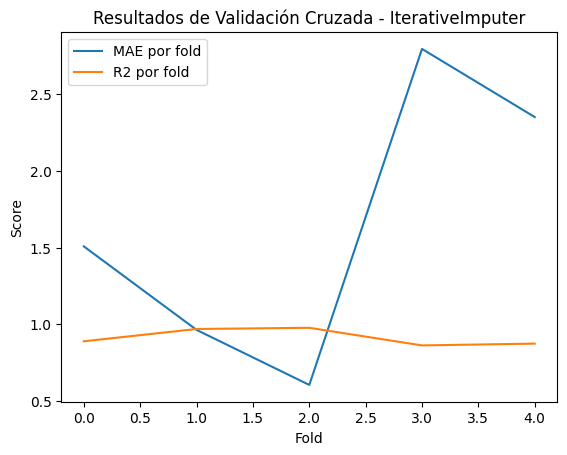

In [ ]:
columnas_numericas = df.columns.drop('Date')


# 4️⃣ Convertir a numpy array solo los valores numéricos
X_full = df[columnas_numericas].values

# 5️⃣ Inicializar k-fold
kf = KFold(n_splits=5, shuffle=True, random_state=0)

mae_scores = []
r2_scores = []

# 6️⃣ Validación cruzada
for train_index, test_index in kf.split(X_full):
    X_train, X_test = X_full[train_index], X_full[test_index]

    # Introducir nulos solo en test
    X_test_missing = X_test.copy()
    mask = np.random.rand(*X_test.shape) < 0.1  # 10% de nulos
    X_test_missing[mask] = np.nan

    # 7️⃣ Aplicar imputador
    imputer = IterativeImputer(random_state=0)
    imputer.fit(X_train)
    X_test_imputed = imputer.transform(X_test_missing)

    # 8️⃣ Calcular métricas SOLO en posiciones donde introdujimos nulos
    true_values = X_test[mask]
    imputed_values = X_test_imputed[mask]

    mae = mean_absolute_error(true_values, imputed_values)
    r2 = r2_score(true_values, imputed_values)

    mae_scores.append(mae)
    r2_scores.append(r2)

print(f"MAE promedio: {np.mean(mae_scores):.4f}")
print(f"R² promedio: {np.mean(r2_scores):.4f}")

# 9️⃣ Gráfico para visualizar desempeño
plt.plot(mae_scores, label='MAE por fold')
plt.plot(r2_scores, label='R2 por fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.title('Resultados de Validación Cruzada - IterativeImputer')
plt.show()

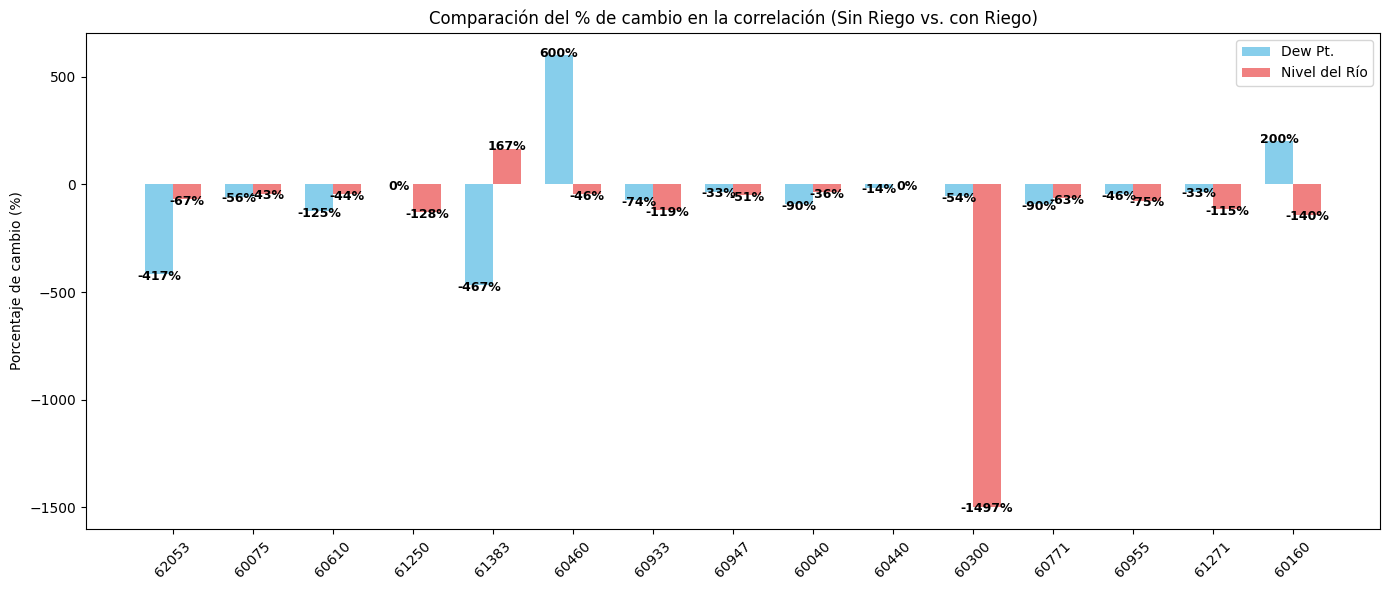

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Datos corregidos para el gráfico
freatimetros = ['62053', '60075', '60610', '61250', '61383', '60460', '60933', '60947',
                '60040', '60440', '60300', '60771', '60955', '61271', '60160']
cambio_dewpt = [-417, -56, -125, 0, -467, 600, -74, -33, -90,-14,-54 ,-90,-46, -33, 200]
cambio_rio = [-67, -43, -44, -128, 167, -46, -119, -51, -36, 0, -1497, -63, -75, -115, -140]

# Posiciones para las barras
x = np.arange(len(freatimetros))
width = 0.35

# Crear gráfico
fig, ax = plt.subplots(figsize=(14, 6))

# Barras
bar1 = ax.bar(x - width/2, cambio_dewpt, width, label='Dew Pt.', color='skyblue')
bar2 = ax.bar(x + width/2, cambio_rio, width, label='Nivel del Río', color='lightcoral')

# Etiquetas
ax.set_ylabel('Porcentaje de cambio (%)')
ax.set_title('Comparación del % de cambio en la correlación (Sin Riego vs. con Riego)')
ax.set_xticks(x)
ax.set_xticklabels(freatimetros, rotation=45)
ax.legend()

# Agregar etiquetas dentro de las barras
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            va = 'bottom' if height < 0 else 'top'
            offset = -10 if height > 0 else 10
            ax.text(bar.get_x() + bar.get_width()/2, height - offset,
                    f'{int(height)}%', ha='center', va='center', fontsize=9, fontweight='bold', color='black')

label_bars(bar1)
label_bars(bar2)

plt.tight_layout()
plt.show()
#output_path = "/mnt/data/comparacion_cambios_correlacion_corregido.png"
#plt.savefig(output_path, dpi=300)



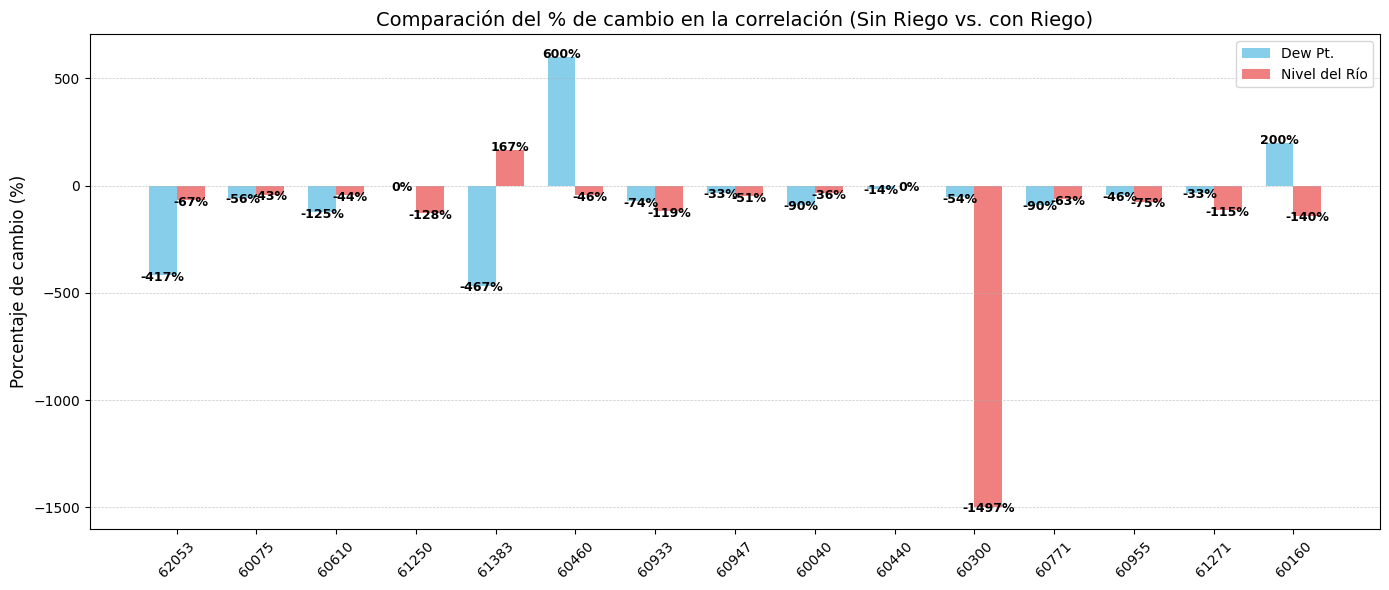

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Datos corregidos para el gráfico
freatimetros = ['62053', '60075', '60610', '61250', '61383', '60460', '60933', '60947',
                '60040', '60440', '60300', '60771', '60955', '61271', '60160']
cambio_dewpt = [-417, -56, -125, 0, -467, 600, -74, -33, -90, -14, -54, -90, -46, -33, 200]
cambio_rio = [-67, -43, -44, -128, 167, -46, -119, -51, -36, 0, -1497, -63, -75, -115, -140]

# Posiciones para las barras
x = np.arange(len(freatimetros))
width = 0.35

# Crear gráfico
fig, ax = plt.subplots(figsize=(14, 6))

# Barras
bar1 = ax.bar(x - width/2, cambio_dewpt, width, label='Dew Pt.', color='skyblue')
bar2 = ax.bar(x + width/2, cambio_rio, width, label='Nivel del Río', color='lightcoral')

# Etiquetas
ax.set_ylabel('Porcentaje de cambio (%)', fontsize=12)
ax.set_title('Comparación del % de cambio en la correlación (Sin Riego vs. con Riego)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(freatimetros, rotation=45, fontsize=10)
ax.legend()

# Cuadrícula
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Agregar etiquetas dentro de las barras
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            va = 'bottom' if height < 0 else 'top'
            offset = -10 if height > 0 else 10
            ax.text(bar.get_x() + bar.get_width()/2, height - offset,
                    f'{int(height)}%', ha='center', va='center', fontsize=9, fontweight='bold', color='black')

label_bars(bar1)
label_bars(bar2)

plt.tight_layout()

plt.show()


